# Seminar 01. Optimization as the Foundation of Machine Learning

Checks for every number used in the seminar page, the handout and the cheat sheet. The notebook also writes the data file for the web page, the figures, `values.tex` and the LaTeX sources of the handout and the cheat sheet.

## 1. Setup

`check(name, computed, expected, tol)` records one comparison and `put(key, value)` stores a value for the data file. Exact values come from sympy and `Fraction`, and the TeX strings of the data are parsed back into sympy with `tex_to_sympy`.

In [1]:
import inspect
import io
import itertools
import json
import math
import re
import sys
import zlib
from fractions import Fraction as Fr
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sympy as sp
from sympy.parsing.sympy_parser import (convert_xor, implicit_multiplication_application, parse_expr,
                                        standard_transformations)

SEED = 42
TOPIC = "01. Optimization as the Foundation of Machine Learning"
SEMINAR = "01"
NOTEBOOK = f"{TOPIC}.ipynb"


def find_author_root(start):
    """The folder Seminars/Evgeny Baulin, searched from start upwards."""
    for base in (start, *start.parents):
        for cand in (base, base / "Seminars" / "Evgeny Baulin"):
            if (cand / "checks" / NOTEBOOK).is_file():
                return cand
    raise FileNotFoundError(f"Seminars/Evgeny Baulin/checks/{NOTEBOOK} not found above {start}")


AUTHOR = find_author_root(Path.cwd())
REPO = AUTHOR.parent.parent
NB_PATH = AUTHOR / "checks" / NOTEBOOK
WEB_ROOT = AUTHOR / "web"
WEB = WEB_ROOT / SEMINAR
SHARED = WEB_ROOT / "shared"
VENDOR = SHARED / "vendor"
THEORY = AUTHOR / "theory" / TOPIC
FIG_SVG = WEB / "figures"
FIG_PDF = THEORY / "figures"

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 500)
np.set_printoptions(precision=6, suppress=True)

CHECKS = []
DATA = {}
# TeX key -> how its value was checked: parse, chain, span, build or approx
TEXCHECK = {}


def _short(value):
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, (list, tuple)):
        value = [str(v) if isinstance(v, Fr) else v for v in value]
    text = str(value)
    return text if len(text) <= 72 else text[:69] + "..."


def check(name, computed, expected, tol=1e-9):
    """Numbers and arrays must agree within tol; strings, booleans and lists of strings must be equal."""
    exact = isinstance(expected, (str, bool, np.bool_)) or (
        isinstance(expected, (list, tuple)) and len(expected) > 0 and all(isinstance(e, str) for e in expected))
    if exact:
        if isinstance(expected, (list, tuple)):
            passed = list(computed) == list(expected)
        else:
            passed = bool(computed == expected)
    else:
        try:
            if isinstance(computed, sp.MatrixBase) and 1 in computed.shape:
                computed = list(computed)
            c = np.asarray(computed, dtype=float)
            e = np.asarray(expected, dtype=float)
            passed = c.shape == e.shape and bool(np.all(np.isfinite(c))) and bool(np.all(np.abs(c - e) <= tol))
        except (TypeError, ValueError):
            passed = False
    CHECKS.append({"check": name, "computed": _short(computed), "expected": _short(expected),
                   "tol": None if exact else tol, "passed": bool(passed)})
    return bool(passed)


def section(*prefixes, start=0):
    """Table of the checks recorded from position start on whose names begin with one of the prefixes."""
    rows = [c for c in CHECKS[start:] if not prefixes or c["check"].startswith(prefixes)]
    return pd.DataFrame(rows, columns=["check", "computed", "expected", "passed"])


def clean(value):
    """JSON-ready copy of a value: exact numbers become int or float, floats are rounded to 10 decimals."""
    if isinstance(value, dict):
        return {str(k): clean(v) for k, v in value.items()}
    if isinstance(value, sp.MatrixBase):
        value = list(value) if value.shape[1] == 1 else value.tolist()
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, (list, tuple)):
        return [clean(v) for v in value]
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    if isinstance(value, sp.Basic):
        value = Fr(int(value.p), int(value.q)) if value.is_Rational else float(value)
    if isinstance(value, Fr):
        value = int(value) if value.denominator == 1 else float(value)
    if isinstance(value, (int, np.integer)):
        return int(value)
    if isinstance(value, (float, np.floating)):
        v = round(float(value), 10)
        if not math.isfinite(v):
            raise ValueError("non-finite value in the export")
        return int(v) if v == int(v) and abs(v) < 2**53 else v
    return value


def put(key, value):
    """Store a value for the data file under a dotted key such as 'A1.steps.H'."""
    assert re.fullmatch(r"[A-Za-z][A-Za-z0-9]*(\.[A-Za-z0-9]+)*", key), key
    node = DATA
    parts = key.split(".")
    for part in parts[:-1]:
        node = node.setdefault(part, {})
        assert isinstance(node, dict), key
    node[parts[-1]] = clean(value)


def get(key):
    """Stored value of a dotted key; list entries are numbered from 1."""
    node = DATA
    for part in key.split("."):
        node = node[int(part) - 1] if isinstance(node, list) else node[part]
    return node


def write_if_changed(path, data):
    """Write text (UTF-8) or bytes to path unless the file already holds exactly these bytes."""
    path = Path(path)
    new = data.encode("utf-8") if isinstance(data, str) else data
    if path.is_file() and path.read_bytes() == new:
        return False
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(new)
    return True


print(f"python {sys.version.split()[0]}")
print(f"numpy {np.__version__} | sympy {sp.__version__} | scipy {scipy.__version__} | "
      f"matplotlib {matplotlib.__version__} | pandas {pd.__version__}")
print(f"seed {SEED} | notebook {NB_PATH.relative_to(REPO)}")

python 3.14.6
numpy 2.5.2 | sympy 1.14.0 | scipy 1.18.1 | matplotlib 3.11.1 | pandas 3.0.5
seed 42 | notebook Seminars/Evgeny Baulin/checks/01. Optimization as the Foundation of Machine Learning.ipynb


In [2]:
x1, x2, x3, t, a, alpha, r, phi, lam, theta, x, w1, w2 = sp.symbols(
    "x1 x2 x3 t a alpha r phi lambda theta x w1 w2", real=True)
XY = (x1, x2)
XYZ = (x1, x2, x3)


def grad(e, v=XY):
    return sp.Matrix([sp.diff(e, s) for s in v])


def hess(e, v=XY):
    return sp.hessian(e, v)


def at(M, v, p):
    return M.subs(dict(zip(v, p)))


def eig_sorted(M):
    """Eigenvalues with multiplicity, sorted by their numerical value."""
    vals = []
    for val, mult in sp.Matrix(M).eigenvals().items():
        vals += [val] * mult
    return sorted(vals, key=lambda z: float(sp.re(sp.N(z, 30))))


def leading_minors_exact(M):
    M = sp.Matrix(M)
    return [M[:k, :k].det() for k in range(1, M.rows + 1)]


def principal_minors_exact(M):
    M = sp.Matrix(M)
    n = M.rows
    return [M.extract(list(idx), list(idx)).det()
            for k in range(1, n + 1) for idx in itertools.combinations(range(n), k)]


def cls_name(M):
    """Exact definiteness: pd, psd, nd, nsd, indefinite or zero."""
    S = sp.Matrix(M)
    if S.is_zero_matrix:
        return "zero"
    if S.is_positive_definite:
        return "pd"
    if S.is_positive_semidefinite:
        return "psd"
    if S.is_negative_definite:
        return "nd"
    if S.is_negative_semidefinite:
        return "nsd"
    return "indefinite"


def fd_hess(f, x, h=1e-4):
    """Hessian by second differences on four points."""
    x = np.asarray(x, float)
    n = x.size
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei = np.zeros(n)
            ej = np.zeros(n)
            ei[i] = h
            ej[j] = h
            H[i, j] = (f(x + ei + ej) - f(x + ei - ej) - f(x - ei + ej) + f(x - ei - ej)) / (4 * h * h)
    return H


def numf(e, v=XY):
    fn = sp.lambdify(v, e, "numpy")
    return lambda z: float(fn(*z))


TRANSF = standard_transformations + (implicit_multiplication_application, convert_xor)
NAMES = {"x1": x1, "x2": x2, "x3": x3, "t": t, "a": a, "alpha": alpha, "lam": lam, "r": r, "phi": phi,
         "theta": theta, "x": x, "w1": w1, "w2": w2}


def tex_to_sympy(tex):
    """Sympy expression of a TeX formula in the notation of the data file."""
    s = tex
    s = s.replace(r"\left(", "(").replace(r"\right)", ")").replace(r"\big(", "(").replace(r"\big)", ")")
    s = s.replace(r"\,", " ").replace(r"\ ", " ").replace(r"^\top", "")
    s = re.sub(r"\\[td]?frac\{([^{}]+)\}\{([^{}]+)\}", r"((\1)/(\2))", s)
    s = re.sub(r"\\[td]?frac(\d)(\d)", r"((\1)/(\2))", s)
    ang = {"varphi": "phi", "theta": "theta"}
    s = re.sub(r"\\(cos|sin)\^(\d)\\(varphi|theta)",
               lambda m: f" ({m.group(1)}({ang[m.group(3)]})**{m.group(2)}) ", s)
    s = re.sub(r"\\(cos|sin)\s*(\d*)\\(varphi|theta)",
               lambda m: f" {m.group(1)}({m.group(2) or '1'}*{ang[m.group(3)]}) ", s)
    s = re.sub(r"([xw])_(\d)", r" \1\2 ", s)
    s = s.replace(r"\alpha", " alpha ").replace(r"\lambda", " lam ").replace(r"\varphi", " phi ")
    s = s.replace(r"\theta", " theta ")
    s = s.replace(r"\cdot", "*").replace(r"\sqrt", " sqrt").replace(r"\pi", " pi ")
    s = s.replace("{", "(").replace("}", ")")
    s = re.sub(r"(\d+\.\d+)", lambda m: f"Rational('{m.group(1)}')", s)
    return parse_expr(s, local_dict={**NAMES, "Rational": sp.Rational}, transformations=TRANSF)


def tex_matrix(tex):
    body = re.search(r"\\begin\{pmatrix\}(.*)\\end\{pmatrix\}", tex, re.S).group(1)
    return sp.Matrix([[tex_to_sympy(c) for c in row.split("&")] for row in body.split(r"\\")])


def tex_tuple(tex):
    body = tex.replace(r"\left(", "(").replace(r"\right)", ")").replace(r"^\top", "").strip()
    assert body.startswith("(") and body.endswith(")"), tex
    return [tex_to_sympy(c) for c in body[1:-1].split(r",\ ")]


def plain(e):
    e = sp.nsimplify(e)
    return e.subs({s_: sp.Symbol(s_.name) for s_ in getattr(e, "free_symbols", set())})


def same(a_, b_):
    return sp.simplify(plain(a_) - plain(b_)) == 0


def owner(key):
    """Check-name prefix for a data key."""
    p = key.split(".")
    if p[0] == "ex":
        return "examples:"
    if p[0] == "hook":
        return "hook:"
    if p[0] == "A":
        return "A lecture:"
    if p[0] == "B":
        return "B lines:" if p[1] == "lines" else "B widgets:"
    if p[0] in ("C", "D"):
        return p[0] + " widgets:"
    if p[0] in ("exit", "home"):
        return f"{p[0]} {p[1]}:"
    return p[0] + ":"


def tex_parse(key, expected):
    s = get(key)
    if isinstance(expected,
                  sp.MatrixBase) or (isinstance(expected, list) and expected and isinstance(expected[0], list)):
        got = tex_matrix(s)
        ok = got.shape == sp.Matrix(expected).shape and all(same(g_, e_) for g_, e_ in zip(got, sp.Matrix(expected)))
    elif isinstance(expected, (list, tuple)):
        got = tex_tuple(s)
        ok = len(got) == len(expected) and all(same(g_, e_) for g_, e_ in zip(got, expected))
    else:
        got = tex_to_sympy(s)
        ok = same(got, expected)
    TEXCHECK[key] = "parse"
    check(f"{owner(key)} tex {key} parses back to the computed value", bool(ok), True)


def tex_chain(key, expected):
    parts = [p.strip() for p in re.split(r"\s=\s", get(key))]
    ok = len(parts) >= 2 and all(same(tex_to_sympy(p), expected) for p in parts)
    TEXCHECK[key] = "chain"
    check(f"{owner(key)} tex {key} every side of the chain equals the computed value", bool(ok), True)


def tex_build(key, built):
    TEXCHECK[key] = "build"
    check(f"{owner(key)} tex {key} equals the string built from the data", get(key), built)


def tex_span(key, equations_zero, variables):
    """Every equality of the chain is a linear combination of the expressions, which vanish at the solution."""
    s = get(key)
    rels = []
    for piece in re.split(r",\\quad\s*", s):
        sides = [p.strip() for p in piece.split("=")]
        rels += [tex_to_sympy(sides[i]) - tex_to_sympy(sides[i + 1]) for i in range(len(sides) - 1)]
    basis = sp.Matrix([[sp.diff(e, v) for v in variables] for e in equations_zero])
    ok = all(sp.Matrix.vstack(basis, sp.Matrix([[sp.diff(rel, v) for v in variables]])).rank() == basis.rank()
             for rel in rels)
    TEXCHECK[key] = "span"
    check(f"{owner(key)} tex {key} every equality follows from the gradient equations", bool(ok), True)


def tex_angles(values):
    return r",\ ".join(f"{v}^\\circ" for v in values)

## 2. Five stationary points

$x_1^2+x_1x_2+x_2^2$ and $x_1^2-x_2^2$ at the origin, and $g(t)=\tfrac14t^4+\tfrac16t^3-\tfrac34t^2+1$ at its stationary points $-\tfrac32$, $0$, $1$. Which of the five points are minima, and which minimum of $g$ is global?

In [3]:
bowl = x1**2 + x1 * x2 + x2**2
saddle = x1**2 - x2**2
g_slice = t**4 / 4 + t**3 / 6 - sp.Rational(3, 4) * t**2 + 1
crit = sorted(sp.solve(sp.diff(g_slice, t), t), key=float)
check("hook: slice stationary points exact", [float(c) for c in crit], [-1.5, 0, 1])

# g(t) = (12 - 9t^2 + 2t^3 + 3t^4) / 12
num = [12, 0, -9, 2, 3]
g_num = lambda s: sum(c * s**k for k, c in enumerate(num)) / 12
ts = (-2.2, -1.5, 0, 1, 1.8)
check("hook: integer coefficients reproduce g", [g_num(s) for s in ts],
      [float(g_slice.subs(t, s)) for s in ts], 1e-12)
vals = [g_slice.subs(t, c) for c in crit]
d2 = [sp.diff(g_slice, t, 2).subs(t, c) for c in crit]
check("hook: slice values exact", vals, [sp.Rational(1, 64), 1, sp.Rational(2, 3)])
dense = np.linspace(-6, 6, 120001)
check("hook: global minimum of g by a dense grid", dense[np.argmin(g_num(dense))], -1.5, 1e-3)
check("hook: g grows without bound, so a global minimum exists",
      [sp.limit(g_slice, t, sp.oo) == sp.oo, sp.limit(g_slice, t, -sp.oo) == sp.oo], [True, True])
check("hook: second derivatives by finite differences",
      [(g_num(c + 1e-4) - 2 * g_num(c) + g_num(c - 1e-4)) / 1e-8 for c in (-1.5, 0, 1)], [float(v) for v in d2], 1e-5)

Hb = hess(bowl)
Hs = hess(saddle)
check("hook: bowl eigenvalues exact vs numpy", [float(v) for v in eig_sorted(Hb)],
      np.linalg.eigvalsh(fd_hess(numf(bowl), [0.3, -0.2])), 1e-6)
check("hook: saddle eigenvalues exact vs numpy", [float(v) for v in eig_sorted(Hs)],
      np.linalg.eigvalsh(fd_hess(numf(saddle), [0.3, -0.2])), 1e-6)
KIND = {"pd": "min", "nd": "max", "indefinite": "saddle"}
kinds_exact = [KIND[cls_name(Hb)], KIND[cls_name(Hs)]] + ["min" if v > 0 else "max" for v in d2]
# the stationary points of g are p3, p4, p5, and argmin counts from 0
global_index = 3 + int(np.argmin([float(v) for v in vals]))
check("hook: global index 3 + argmin (0-based) over the slice values", global_index, 3)
probe = [Fr(3, 5), Fr(-2, 5)]
at_probe = {x1: sp.Rational(3, 5), x2: sp.Rational(-2, 5)}
check("hook: f at the probe point, exact vs float", [bowl.subs(at_probe), saddle.subs(at_probe)],
      [0.6**2 + 0.6 * -0.4 + 0.4**2, 0.6**2 - 0.4**2], 1e-12)

put("hook.bowl.tex.f", "x_1^2 + x_1x_2 + x_2^2")
put("hook.bowl.levels", [Fr(1, 4), 1, Fr(9, 4)])
put("hook.bowl.point", [0, 0])
put("hook.bowl.grad", at(grad(bowl), XY, (0, 0)))
put("hook.bowl.H", Hb)
put("hook.bowl.eig", eig_sorted(Hb))
put("hook.bowl.fProbe", bowl.subs(at_probe))
put("hook.saddle.tex.f", "x_1^2 - x_2^2")
put("hook.saddle.levels", [-1, Fr(-1, 4), Fr(1, 4), 1])
put("hook.saddle.point", [0, 0])
put("hook.saddle.grad", at(grad(saddle), XY, (0, 0)))
put("hook.saddle.H", Hs)
put("hook.saddle.eig", eig_sorted(Hs))
put("hook.saddle.fProbe", saddle.subs(at_probe))
put("hook.probe", probe)
put("hook.slice.num", num)
put("hook.slice.den", 12)
put("hook.slice.points", crit)
put("hook.slice.values", vals)
put("hook.slice.d2", d2)
put("hook.slice.domain", [Fr(-11, 5), Fr(9, 5)])
put("hook.slice.range", [Fr(-1, 4), Fr(9, 4)])
put("hook.slice.tex.g", r"\tfrac14 t^4 + \tfrac16 t^3 - \tfrac34 t^2 + 1")
put("hook.slice.tex.gMin", r"\tfrac{1}{64}")
put("hook.slice.tex.gLocal", r"\tfrac{2}{3}")
put("hook.kinds", kinds_exact)
put("hook.globalIndex", global_index)
tex_parse("hook.bowl.tex.f", bowl)
tex_parse("hook.saddle.tex.f", saddle)
tex_parse("hook.slice.tex.g", g_slice)
tex_parse("hook.slice.tex.gMin", vals[0])
tex_parse("hook.slice.tex.gLocal", vals[2])

plotted = [g_num(s) for s in np.linspace(-2.2, 1.8, 801)]
check("hook: the slice points plot inside the domain and the range",
      bool(all(-2.2 <= float(c) <= 1.8 for c in crit) and max(plotted) <= 2.25 and min(plotted) >= -0.25), True)
section("hook")

,check,computed,expected,passed
0,hook: slice stationary points exact,"[-1.5, 0.0, 1.0]","[-1.5, 0, 1]",True
1,hook: integer coefficients reproduce g,"[1.451733333333334, 0.015625, 1.0, 0.6666666666666666, 2.1664]","[1.4517333333333338, 0.015625, 1.0, 0.6666666666666666, 2.1664]",True
2,hook: slice values exact,"[1/64, 1, 2/3]","[1/64, 1, 2/3]",True
3,hook: global minimum of g by a dense grid,-1.5,-1.5,True
4,"hook: g grows without bound, so a global minimum exists","[True, True]","[True, True]",True
5,hook: second derivatives by finite differences,"[3.749999962290862, -1.4999999908837935, 2.499999995908553]","[3.75, -1.5, 2.5]",True
6,hook: bowl eigenvalues exact vs numpy,"[1.0, 3.0]","[0.9999999999940612, 2.999999999635239]",True
7,hook: saddle eigenvalues exact vs numpy,"[-2.0, 2.0]","[-1.99999999981465, 1.9999999999881224]",True
8,hook: global index 3 + argmin (0-based) over the slice values,3,3,True
9,"hook: f at the probe point, exact vs float","[7/25, 1/5]","[0.28, 0.19999999999999996]",True


## 3. Gradients and Hessians

Gradients are compared with central differences $\partial f/\partial x_j\approx\big(f(x+he_j)-f(x-he_j)\big)/(2h)$, $h=10^{-5}$, and Hessians with second differences on four points.

In [4]:
def central_diff(f, x, h=1e-5):
    """Gradient by central differences: an independent check of an analytic formula."""
    x = np.asarray(x, dtype=float)
    g = np.empty_like(x)
    for j in range(x.size):
        e = np.zeros_like(x)
        e[j] = h
        g[j] = (f(x + e) - f(x - e)) / (2 * h)
    return g

### The lecture function

$f(x)=3x_1^3+2x_1x_2^2+4x_2^2$ at $(1,1)$, $(2,-1)$ and $(0,0)$. Its only stationary point is the origin, where $H=\operatorname{diag}(0,8)$.

In [5]:
lec = 3 * x1**3 + 2 * x1 * x2**2 + 4 * x2**2
g_lec = grad(lec)
H_lec = hess(lec)
f_lec = numf(lec)
for name, p in (("lecture point", (1, 1)), ("A2 point", (2, -1)), ("origin", (0, 0))):
    check(f"A lecture: gradient at the {name}, sympy vs central differences",
          at(g_lec, XY, p), central_diff(f_lec, p), 1e-6)
    check(f"A lecture: Hessian at the {name}, sympy vs finite differences", at(H_lec, XY, p), fd_hess(f_lec, p), 1e-5)
stat = sp.solve(list(g_lec), XY, dict=True)
check("A lecture: the only stationary point is the origin", [(s[x1], s[x2]) for s in stat],
      [(0, 0)] if len(stat) == 1 else [])
HL1 = at(H_lec, XY, (1, 1))
check("A lecture: det H(1,1) exact vs numpy", HL1.det(), np.linalg.det(np.array(HL1, float)), 1e-9)
check("A lecture: eigenvalues of H(1,1) exact vs numpy", [float(v) for v in eig_sorted(HL1)],
      np.linalg.eigvalsh(np.array(HL1, float)), 1e-9)
check("A lecture: along x2 = 0 f changes sign at the origin",
      bool(f_lec((0.01, 0)) > 0 and f_lec((-0.01, 0)) < 0), True)

put("A.lecture.tex.f", "3x_1^3 + 2x_1x_2^2 + 4x_2^2")
put("A.lecture.tex.H", r"\begin{pmatrix} 18x_1 & 4x_2 \\ 4x_2 & 4x_1 + 8 \end{pmatrix}")
put("A.lecture.tex.restr", "3x_1^3")
put("A.lecture.x", [1, 1])
put("A.lecture.f", lec.subs({x1: 1, x2: 1}))
put("A.lecture.grad", at(g_lec, XY, (1, 1)))
put("A.lecture.H", HL1)
put("A.lecture.det", HL1.det())
put("A.lecture.eig", eig_sorted(HL1))
put("A.lecture.stationary", [0, 0])
put("A.lecture.H0", at(H_lec, XY, (0, 0)))
put("A.lecture.eig0", eig_sorted(at(H_lec, XY, (0, 0))))
put("A.probe.domain", [Fr(-5, 2), Fr(5, 2), -2, 2])
put("A.probe.levels", [-8, -2, Fr(1, 2), 2, 8, 20])
put("A.probe.snap", Fr(1, 10))
tex_parse("A.lecture.tex.f", lec)
tex_parse("A.lecture.tex.H", H_lec)
tex_parse("A.lecture.tex.restr", lec.subs(x2, 0))
section("A lecture")

,check,computed,expected,passed
0,"A lecture: gradient at the lecture point, sympy vs central differences","[11, 12]","[11.000000000294106, 11.999999999989795]",True
1,"A lecture: Hessian at the lecture point, sympy vs finite differences","Matrix([[18, 4], [4, 12]])","[[18.000000023832285, 4.000000020099037], [4.000000020099037, 12.0000...",True
2,"A lecture: gradient at the A2 point, sympy vs central differences","[38, -16]","[38.000000000693035, -16.00000000010482]",True
3,"A lecture: Hessian at the A2 point, sympy vs finite differences","Matrix([[36, -4], [-4, 16]])","[[36.00000040293594, -4.0000001533258], [-4.0000001533258, 15.9999999...",True
4,"A lecture: gradient at the origin, sympy vs central differences","[0, 0]","[3.0000000000000005e-10, 0.0]",True
5,"A lecture: Hessian at the origin, sympy vs finite differences","Matrix([[0, 0], [0, 8]])","[[0.0, 0.0], [0.0, 8.0]]",True
6,A lecture: the only stationary point is the origin,"[(0, 0)]","[(0, 0)]",True
7,"A lecture: det H(1,1) exact vs numpy",200,199.99999999999991,True
8,"A lecture: eigenvalues of H(1,1) exact vs numpy","[10.0, 20.0]","[10.0, 20.0]",True
9,A lecture: along x2 = 0 f changes sign at the origin,True,True,True


### A1. Gradient and Hessian of a quadratic

$f(x)=x_1^2+x_2^2-x_1x_2$. Find $\nabla f$ and $H$ at an arbitrary point and at $(1,1)$. Is $(1,1)$ a candidate for a minimum?

In $f=x^\top Ax$ the off-diagonal entry of $A$ is $-\tfrac12$, while $H_{12}=-1$.

In [6]:
fA1 = x1**2 + x2**2 - x1 * x2
gA1 = grad(fA1)
HA1 = hess(fA1)
check("A1: gradient formula", [sp.expand(gA1[0] - (2 * x1 - x2)), sp.expand(gA1[1] - (2 * x2 - x1))], [0, 0])
check("A1: gradient at (1,1), sympy vs central differences",
      at(gA1, XY, (1, 1)), central_diff(numf(fA1), (1, 1)), 1e-6)
check("A1: Hessian constant, sympy vs finite differences at two points", [np.array(HA1, float), np.array(HA1, float)],
      [fd_hess(numf(fA1), (1, 1)), fd_hess(numf(fA1), (-0.7, 2.3))], 1e-5)
check("A1: Hessian has no variables", HA1.free_symbols == set(), True)
check("A1: eigenvalues exact vs numpy", [float(v) for v in eig_sorted(HA1)],
      np.linalg.eigvalsh(np.array(HA1, float)), 1e-12)
check("A1: characteristic polynomial coefficients", HA1.charpoly().all_coeffs(), [1, -4, 3])
A_form = sp.Matrix([[1, sp.Rational(-1, 2)], [sp.Rational(-1, 2), 1]])
xv = sp.Matrix(XY)
check("A1: x^T A x reproduces f and H = A + A^T",
      [sp.expand((xv.T * A_form * xv)[0] - fA1), (HA1 - A_form - A_form.T).norm()],
      [0, 0])
check("A1: the doubling mistake gives -2 and the x^T A x entry is -1/2", [2 * HA1[0, 1], A_form[0, 1]], [-2, -0.5])
check("A1: minimizer solves grad f = 0", [sp.solve(list(gA1), XY)[x1], sp.solve(list(gA1), XY)[x2]], [0, 0])

put("A1.tex.f", "x_1^2 + x_2^2 - x_1x_2")
put("A1.tex.g1", "2x_1 - x_2")
put("A1.tex.g2", "2x_2 - x_1")
put("A1.tex.charPoly", r"\lambda^2 - 4\lambda + 3")
put("A1.tex.A", r"\begin{pmatrix} 1 & -\tfrac12 \\ -\tfrac12 & 1 \end{pmatrix}")
put("A1.tex.offA", r"-\tfrac12")
put("A1.params.x", [1, 1])
put("A1.steps.grad", at(gA1, XY, (1, 1)))
put("A1.steps.H", HA1)
put("A1.steps.eig", eig_sorted(HA1))
put("A1.steps.xStar", [0, 0])
put("A1.answer.g1", {"type": "formula", "value": "2*x1 - x2", "vars": ["x1", "x2"], "tol": 1e-9})
put("A1.answer.H", {"type": "matrix", "value": HA1, "tol": 1e-9})
put("A1.answer.stationary", {"type": "single", "value": "no"})
tex_parse("A1.tex.f", fA1)
tex_parse("A1.tex.g1", gA1[0])
tex_parse("A1.tex.g2", gA1[1])
tex_parse("A1.tex.charPoly", HA1.charpoly(lam).as_expr())
tex_parse("A1.tex.A", A_form)
tex_parse("A1.tex.offA", A_form[0, 1])
check("A1: the formula answer evaluates like the gradient component",
      [float((2 * x1 - x2 - gA1[0]).subs({x1: u, x2: v})) for u, v in ((-3.7, 0.4), (2.9, -1.2))], [0, 0])
section("A1")

,check,computed,expected,passed
0,A1: gradient formula,"[0, 0]","[0, 0]",True
1,"A1: gradient at (1,1), sympy vs central differences","[1, 1]","[1.000000000001, 1.000000000001]",True
2,"A1: Hessian constant, sympy vs finite differences at two points","[array([[ 2., -1.],\n [-1., 2.]]), array([[ 2., -1.],\n [-...","[array([[ 2., -1.],\n [-1., 2.]]), array([[ 2., -1.],\n [-...",True
3,A1: Hessian has no variables,True,True,True
4,A1: eigenvalues exact vs numpy,"[1.0, 3.0]","[1.0, 3.0]",True
5,A1: characteristic polynomial coefficients,"[1, -4, 3]","[1, -4, 3]",True
6,A1: x^T A x reproduces f and H = A + A^T,"[0, 0]","[0, 0]",True
7,A1: the doubling mistake gives -2 and the x^T A x entry is -1/2,"[-2, -1/2]","[-2, -0.5]",True
8,A1: minimizer solves grad f = 0,"[0, 0]","[0, 0]",True
9,A1: tex A1.tex.f parses back to the computed value,True,True,True


### A2. The Hessian moves with the point

For the lecture function compute $\nabla f$, $H$ and $\det H$ at $(2,-1)$ and compare with $\det H(1,1)=200$. Is $(2,-1)$ a stationary point?

In [7]:
pA2 = (2, -1)
gA2 = at(g_lec, XY, pA2)
HA2 = at(H_lec, XY, pA2)
check("A2: substitutions shown in the steps",
      [9 * 2**2 + 2 * (-1) ** 2, 4 * 2 * (-1) + 8 * (-1), 36 * 16 - (-4) ** 2],
      [gA2[0], gA2[1], HA2.det()])
check("A2: det H exact vs numpy", HA2.det(), np.linalg.det(np.array(HA2, float)), 1e-9)
eA2 = eig_sorted(HA2)
check("A2: eigenvalues 26 ∓ 2 sqrt 29, exact vs numpy",
      [float(v) for v in eA2], np.linalg.eigvalsh(np.array(HA2, float)), 1e-9)
check("A2: eigenvalues closed form",
      [sp.simplify(eA2[0] - (26 - 2 * sp.sqrt(29))), sp.simplify(eA2[1] - (26 + 2 * sp.sqrt(29)))], [0, 0])
check("A2: gradient is not zero", bool(max(abs(v) for v in gA2) > 0), True)

put("A2.tex.f", "3x_1^3 + 2x_1x_2^2 + 4x_2^2")
put("A2.tex.g1", "9x_1^2 + 2x_2^2")
put("A2.tex.g2", "4x_1x_2 + 8x_2")
put("A2.tex.H", r"\begin{pmatrix} 18x_1 & 4x_2 \\ 4x_2 & 4x_1 + 8 \end{pmatrix}")
put("A2.tex.sub1", r"9\cdot 2^2 + 2\cdot(-1)^2")
put("A2.tex.sub2", r"4\cdot 2\cdot(-1) + 8\cdot(-1)")
put("A2.tex.detSub", r"36\cdot 16 - (-4)^2")
put("A2.params.x", list(pA2))
put("A2.steps.grad", gA2)
put("A2.steps.H", HA2)
put("A2.steps.det", HA2.det())
put("A2.steps.eig", [float(v) for v in eA2])
put("A2.steps.f", lec.subs({x1: 2, x2: -1}))
put("A2.answer.grad", {"type": "vector", "value": gA2, "tol": 1e-9})
put("A2.answer.H", {"type": "matrix", "value": HA2, "tol": 1e-9})
put("A2.answer.det", {"type": "number", "value": HA2.det(), "tol": 1e-9})
put("A2.answer.stationary", {"type": "single", "value": "no"})
tex_parse("A2.tex.f", lec)
tex_parse("A2.tex.g1", g_lec[0])
tex_parse("A2.tex.g2", g_lec[1])
tex_parse("A2.tex.H", H_lec)
tex_parse("A2.tex.sub1", gA2[0])
tex_parse("A2.tex.sub2", gA2[1])
tex_parse("A2.tex.detSub", HA2.det())
section("A2")

,check,computed,expected,passed
0,A2: substitutions shown in the steps,"[38, -16, 560]","[38, -16, 560]",True
1,A2: det H exact vs numpy,560,559.9999999999999,True
2,"A2: eigenvalues 26 ∓ 2 sqrt 29, exact vs numpy","[15.229670385730993, 36.77032961426901]","[15.229670385730993, 36.77032961426901]",True
3,A2: eigenvalues closed form,"[0, 0]","[0, 0]",True
4,A2: gradient is not zero,True,True,True
5,A2: tex A2.tex.f parses back to the computed value,True,True,True
6,A2: tex A2.tex.g1 parses back to the computed value,True,True,True
7,A2: tex A2.tex.g2 parses back to the computed value,True,True,True
8,A2: tex A2.tex.H parses back to the computed value,True,True,True
9,A2: tex A2.tex.sub1 parses back to the computed value,True,True,True


### A3. Three variables and Sylvester's criterion

$f(x)=x_1^2+2x_2^2+3x_3^2+2x_1x_2-x_2x_3$ on $\mathbb R^3$. Find $\nabla f$ and $H$, decide whether $H\succ 0$ by Sylvester's criterion, and find the minimizer.

The eigenvalues of $H$ are the roots of $\lambda^3-12\lambda^2+39\lambda-22$.

In [8]:
fA3 = x1**2 + 2 * x2**2 + 3 * x3**2 + 2 * x1 * x2 - x2 * x3
gA3 = grad(fA3, XYZ)
HA3 = hess(fA3, XYZ)
check("A3: Hessian, sympy vs finite differences", HA3, fd_hess(numf(fA3, XYZ), (0.3, -0.4, 0.8)), 1e-5)
check("A3: gradient at a probe, sympy vs central differences", at(gA3, XYZ, (0.3, -0.4, 0.8)),
      central_diff(numf(fA3, XYZ), (0.3, -0.4, 0.8)), 1e-6)
mA3 = leading_minors_exact(HA3)
check("A3: first-row expansion 2(24 - 1) - 2(12 - 0) = 46 - 24", [2 * (4 * 6 - 1) - 2 * (2 * 6 - 0) + 0, 46 - 24],
      [mA3[2], mA3[2]])
pmA3 = principal_minors_exact(HA3)
eA3 = np.linalg.eigvalsh(np.array(HA3, float))
check("A3: eigenvalues are the roots of the characteristic cubic",
      sorted(np.roots([1, -12, 39, -22]).real), eA3, 1e-9)
check("A3: characteristic polynomial coefficients", HA3.charpoly().all_coeffs(), [1, -12, 39, -22])
sol = sp.solve(list(gA3), XYZ, dict=True)
check("A3: unique stationary point exact vs numpy solve", [[sol[0][v] for v in XYZ]],
      [np.linalg.solve(np.array(HA3, float), -np.array(at(gA3, XYZ, (0, 0, 0)), float).ravel())], 1e-12)

put("A3.tex.f", "x_1^2 + 2x_2^2 + 3x_3^2 + 2x_1x_2 - x_2x_3")
put("A3.tex.grad", r"\begin{pmatrix} 2x_1 + 2x_2 \\ 2x_1 + 4x_2 - x_3 \\ 6x_3 - x_2 \end{pmatrix}")
put("A3.tex.delta2", r"2\cdot 4 - 2\cdot 2")
put("A3.tex.delta3", r"2(4\cdot 6 - 1) - 2(2\cdot 6 - 0) + 0 = 46 - 24")
put("A3.tex.system", r"x_1 = -x_2,\quad x_2 = 6x_3,\quad x_3 = 2x_2")
put("A3.tex.loop", r"x_2 = 6x_3 = 12x_2")
put("A3.tex.cubic", r"\lambda^3 - 12\lambda^2 + 39\lambda - 22")
put("A3.steps.diag", [HA3[i, i] for i in range(3)])
put("A3.steps.H", HA3)
put("A3.steps.minors", mA3)
put("A3.steps.principal", pmA3)
put("A3.steps.eig", eA3)
put("A3.steps.xStar", [0, 0, 0])
put("A3.answer.H", {"type": "matrix", "value": HA3, "tol": 1e-9})
put("A3.answer.minors", {"type": "vector", "value": mA3, "tol": 1e-9})
put("A3.answer.x", {"type": "vector", "value": [0, 0, 0], "tol": 1e-9})
tex_parse("A3.tex.f", fA3)
# a column vector: compared entrywise with the exact gradient
check("A3: tex A3.tex.grad parses back to the computed value",
      bool(sp.simplify(tex_matrix(get("A3.tex.grad")) - gA3) == sp.zeros(3, 1)), True)
TEXCHECK["A3.tex.grad"] = "parse"
tex_parse("A3.tex.delta2", mA3[1])
tex_chain("A3.tex.delta3", mA3[2])
tex_span("A3.tex.system", list(gA3), XYZ)
tex_span("A3.tex.loop", list(gA3), XYZ)
tex_parse("A3.tex.cubic", HA3.charpoly(lam).as_expr())
section("A3")

,check,computed,expected,passed
0,"A3: Hessian, sympy vs finite differences","Matrix([[2, 2, 0], [2, 4, -1], [0, -1, 6]])","[[1.9999999989472883, 1.9999999989472883, 1.1102230246251565e-08], [1...",True
1,"A3: gradient at a probe, sympy vs central differences","[-0.200000000000000, -1.80000000000000, 5.20000000000000]","[-0.2000000000057511, -1.800000000007351, 5.199999999994098]",True
2,A3: first-row expansion 2(24 - 1) - 2(12 - 0) = 46 - 24,"[22, 22]","[22, 22]",True
3,A3: eigenvalues are the roots of the characteristic cubic,"[np.float64(0.7100549170625208), np.float64(4.705719639720968), np.fl...","[0.7100549170625209, 4.705719639720957, 6.584225443216521]",True
4,A3: characteristic polynomial coefficients,"[1, -12, 39, -22]","[1, -12, 39, -22]",True
5,A3: unique stationary point exact vs numpy solve,"[[0, 0, 0]]","[array([-0., 0., 0.])]",True
6,A3: tex A3.tex.f parses back to the computed value,True,True,True
7,A3: tex A3.tex.grad parses back to the computed value,True,True,True
8,A3: tex A3.tex.delta2 parses back to the computed value,True,True,True
9,A3: tex A3.tex.delta3 every side of the chain equals the computed value,True,True,True


## 4. Classifying stationary points

`classify` reads the signs of the eigenvalues with a tolerance relative to the largest $|\lambda_i|$, so it applies only at a stationary point and to an exactly computed Hessian. Once it is defined, the matrices of section 2, A2 and A3 are classified again.

In [9]:
def classify(H, rel_tol=1e-9):
    """Second-order test for a symmetric matrix: "min", "max", "saddle" or "inconclusive".

    It reads the matrix only, so call it at a stationary point. The tolerance is relative to the largest |eigenvalue|.
    """
    H = np.asarray(H, dtype=float)
    w = np.linalg.eigvalsh(0.5 * (H + H.T))
    tol = rel_tol * np.abs(w).max(initial=0.0)
    if np.all(w > tol):
        return "min"
    if np.all(w < -tol):
        return "max"
    if w.min() < -tol and w.max() > tol:
        return "saddle"
    return "inconclusive"


def leading_minors(A):
    """Leading principal minors: determinants of the top-left k-by-k blocks. They decide A > 0 and A < 0 only."""
    A = np.asarray(A, dtype=float)
    return [float(np.linalg.det(A[:k, :k])) for k in range(1, A.shape[0] + 1)]


def principal_minors(A):
    """All principal minors (same rows and columns), by size. All >= 0 is the test for A >= 0."""
    A = np.asarray(A, dtype=float)
    n = A.shape[0]
    return {k: [float(np.linalg.det(A[np.ix_(idx, idx)])) for idx in itertools.combinations(range(n), k)] for k in range(1, n + 1)}


start = len(CHECKS)
check("hook: kinds by classify on exact matrices vs exact signs",
      [classify(np.array(Hb, float)), classify(np.array(Hs, float))] + [classify([[float(v)]]) for v in d2],
      kinds_exact)
check("A2: classify says min although the point is not stationary", classify(np.array(HA2, float)), "min")
check("A3: leading minors exact vs numpy", mA3, leading_minors(np.array(HA3, float)), 1e-9)
check("A3: seven principal minors exact vs numpy", pmA3,
      [v for k in (1, 2, 3) for v in principal_minors(np.array(HA3, float))[k]], 1e-9)
check("A3: classify", classify(np.array(HA3, float)), "min")
section(start=start)

,check,computed,expected,passed
0,hook: kinds by classify on exact matrices vs exact signs,"['min', 'saddle', 'min', 'max', 'min']","['min', 'saddle', 'min', 'max', 'min']",True
1,A2: classify says min although the point is not stationary,min,min,True
2,A3: leading minors exact vs numpy,"[2, 4, 22]","[2.0, 4.0, 22.000000000000004]",True
3,A3: seven principal minors exact vs numpy,"[2, 4, 6, 4, 12, 23, 22]","[2.0, 4.0, 6.0, 4.0, 12.0, 23.0, 22.000000000000004]",True
4,A3: classify,min,min,True


### Leading minors and semidefiniteness

Minors and eigenvalues of $\operatorname{diag}(0,-1)$, $\operatorname{diag}(0,1)$, $\operatorname{diag}(2,2)$, $\operatorname{diag}(2,-2)$ and $\begin{pmatrix}2&-4\\-4&2\end{pmatrix}$.

The first two matrices have the same leading minors $0,\ 0$, yet one is negative and the other positive semidefinite. The chained test `w.min() < -tol < w.max()` calls $\operatorname{diag}(0,-1)$ a saddle.

In [10]:
presets = {"trapNeg": [[0, 0], [0, -1]], "trapPos": [[0, 0], [0, 1]],
           "bowl": [[2, 0], [0, 2]], "saddle": [[2, 0], [0, -2]],
           "family": [[2, -4], [-4, 2]]}


def sylvester_exact(minors):
    """What Sylvester's criterion concludes from the leading minors: pd, nd or silent."""
    if all(m > 0 for m in minors):
        return "pd"
    if all((-1) ** (k + 1) * m > 0 for k, m in enumerate(minors)):
        return "nd"
    return "silent"


for pid, M in presets.items():
    S = sp.Matrix(M)
    lm = leading_minors_exact(S)
    pm = principal_minors_exact(S)
    ev = eig_sorted(S)
    check(f"B widgets: {pid} leading minors exact vs numpy", lm, leading_minors(M), 1e-12)
    check(f"B widgets: {pid} principal minors exact vs numpy", pm,
          [v for k in (1, 2) for v in principal_minors(M)[k]], 1e-12)
    check(f"B widgets: {pid} eigenvalues exact vs numpy",
          [float(v) for v in ev], np.linalg.eigvalsh(np.array(M, float)), 1e-12)
    put(f"B.definiteness.presets.{pid}", M)
    put(f"B.definiteness.expect.{pid}.leading", lm)
    put(f"B.definiteness.expect.{pid}.principal", pm)
    put(f"B.definiteness.expect.{pid}.eig", ev)
    put(f"B.definiteness.expect.{pid}.cls", cls_name(M))
    put(f"B.definiteness.expect.{pid}.sylvester", sylvester_exact(lm))

same_leading = get("B.definiteness.expect.trapNeg.leading") == get("B.definiteness.expect.trapPos.leading")
check("B trap: same leading minors, opposite semidefiniteness",
      [same_leading, cls_name(presets["trapNeg"]), cls_name(presets["trapPos"])] == [True, "nsd", "psd"], True)
check("B trap: principal minors separate them",
      [min(principal_minors(presets["trapNeg"])[1]) < 0,
       min(v for k in (1, 2) for v in principal_minors(presets["trapPos"])[k]) >= 0], [True, True])
check("B trap: fixed classify on diag(0,-1) and diag(0,1)",
      [classify(presets["trapNeg"]), classify(presets["trapPos"])], ["inconclusive", "inconclusive"])


def classify_slides(H, tol=1e-8):
    """The chained comparison of the old slides, kept to show its mistake."""
    w = np.linalg.eigvalsh(0.5 * (np.asarray(H, float) + np.asarray(H, float).T))
    if np.all(w > tol):
        return "min"
    if np.all(w < -tol):
        return "max"
    if w.min() < -tol < w.max():
        return "saddle"
    return "inconclusive"


check("B trap: the slide version of classify mislabels diag(0,-1) as a saddle",
      classify_slides(presets["trapNeg"]), "saddle")
check("B trap: a singular Hessian with both signs is decided: diag(1,-1,0) is a saddle",
      classify(np.diag([1.0, -1.0, 0.0])), "saddle")
put("B.definiteness.slider", [-5, 5, Fr(1, 2)])
section("B widgets", "B trap")

,check,computed,expected,passed
0,B widgets: trapNeg leading minors exact vs numpy,"[0, 0]","[0.0, 0.0]",True
1,B widgets: trapNeg principal minors exact vs numpy,"[0, -1, 0]","[0.0, -1.0, 0.0]",True
2,B widgets: trapNeg eigenvalues exact vs numpy,"[-1.0, 0.0]","[-1.0, 0.0]",True
3,B widgets: trapPos leading minors exact vs numpy,"[0, 0]","[0.0, 0.0]",True
4,B widgets: trapPos principal minors exact vs numpy,"[0, 1, 0]","[0.0, 1.0, 0.0]",True
5,B widgets: trapPos eigenvalues exact vs numpy,"[0.0, 1.0]","[0.0, 1.0]",True
6,B widgets: bowl leading minors exact vs numpy,"[2, 4]","[2.0, 4.0]",True
7,B widgets: bowl principal minors exact vs numpy,"[2, 2, 4]","[2.0, 2.0, 4.0]",True
8,B widgets: bowl eigenvalues exact vs numpy,"[2.0, 2.0]","[2.0, 2.0]",True
9,B widgets: saddle leading minors exact vs numpy,"[2, -4]","[2.0, -4.0]",True


### Restrictions to lines

For a homogeneous $f$ of degree $k$, $f(t\cos\theta,\ t\sin\theta)=t^k f(\cos\theta,\ \sin\theta)$. Here $f$ is $x_1^2+x_2^2$, $x_1^2-x_2^2$, $x_1^3-3x_1x_2^2$ or $x_1^4+x_2^4$, and the lines where $f=0$ are found by a scan over whole degrees.

In [11]:
fB = {"bowl": x1**2 + x2**2, "saddle": x1**2 - x2**2, "monkey": x1**3 - 3 * x1 * x2**2, "quartic": x1**4 + x2**4}
deg = {"bowl": 2, "saddle": 2, "monkey": 3, "quartic": 4}
angles = [0, 30, 45, 90]
for key, e in fB.items():
    restr = sp.expand(e.subs({x1: t * sp.cos(phi), x2: t * sp.sin(phi)}))
    coef = sp.simplify(restr / t ** deg[key])
    check(f"B lines: {key} is homogeneous of degree {deg[key]}",
          sp.simplify(e.subs({x1: 2 * x1, x2: 2 * x2}) - 2 ** deg[key] * e), 0)
    exact = [coef.subs(phi, sp.pi * ang / 180) for ang in angles]
    numeric = [numf(e)((math.cos(math.radians(ang)), math.sin(math.radians(ang)))) for ang in angles]
    check(f"B lines: {key} coefficients f(cos, sin), exact vs numeric", [float(v) for v in exact], numeric, 1e-12)
    put(f"B.lines.coef.{key}", [sp.nsimplify(v) for v in exact])
    put(f"B.lines.degree.{key}", deg[key])
put("B.lines.angles", angles)
put("B.lines.tex.monkey", r"\cos 3\theta")
put("B.lines.t", Fr(3, 2))
put("B.lines.levels.bowl", [Fr(1, 4), 1, Fr(9, 4)])
put("B.lines.levels.saddle", [-1, Fr(-1, 4), Fr(1, 4), 1])
put("B.lines.levels.monkey", [-1, Fr(-1, 4), Fr(1, 4), 1])
put("B.lines.levels.quartic", [Fr(1, 16), Fr(1, 4), 1])
tex_parse("B.lines.tex.monkey", sp.expand_trig(fB["monkey"].subs({x1: sp.cos(theta), x2: sp.sin(theta)})))


def zero_directions(f):
    """Whole degrees in [0, 180) where f vanishes on the unit circle."""
    on_circle = numf(f)
    return [ang for ang in range(0, 180)
            if abs(on_circle((math.cos(math.radians(ang)), math.sin(math.radians(ang))))) < 1e-9]


zero_monkey = zero_directions(fB["monkey"])
zero_saddle = zero_directions(fB["saddle"])
put("B.lines.zeroAngles.monkey", zero_monkey)
put("B.lines.zeroAngles.saddle", zero_saddle)
section("B lines")

,check,computed,expected,passed
0,B lines: bowl is homogeneous of degree 2,0,0,True
1,"B lines: bowl coefficients f(cos, sin), exact vs numeric","[1.0, 1.0, 1.0, 1.0]","[1.0, 1.0, 1.0, 1.0]",True
2,B lines: saddle is homogeneous of degree 2,0,0,True
3,"B lines: saddle coefficients f(cos, sin), exact vs numeric","[1.0, 0.5, 0.0, -1.0]","[1.0, 0.5000000000000002, 2.220446049250313e-16, -1.0]",True
4,B lines: monkey is homogeneous of degree 3,0,0,True
5,"B lines: monkey coefficients f(cos, sin), exact vs numeric","[1.0, 0.0, -0.7071067811865476, 0.0]","[1.0, 2.220446049250313e-16, -0.7071067811865474, -1.8369701987210297...",True
6,B lines: quartic is homogeneous of degree 4,0,0,True
7,"B lines: quartic coefficients f(cos, sin), exact vs numeric","[1.0, 0.625, 0.5, 1.0]","[1.0, 0.6250000000000001, 0.5, 1.0]",True
8,B lines: tex B.lines.tex.monkey parses back to the computed value,True,True,True


### B1. A bowl

$f(x)=x_1^2+x_2^2$. Find the stationary points and the definiteness of $H$. Is the minimum global, and why?

A gradient step $x-\tfrac12\nabla f(x)$ lands at the origin from every $x$.

In [12]:
gB1 = grad(fB["bowl"])
HB1 = hess(fB["bowl"])
check("B1: stationary points exact", str(sp.solve(list(gB1), XY, dict=True)), "[{x1: 0, x2: 0}]")
check("B1: minors and eigenvalues exact vs numpy", [*leading_minors_exact(HB1), *eig_sorted(HB1)],
      [*leading_minors(np.array(HB1, float)), *np.linalg.eigvalsh(np.array(HB1, float))], 1e-12)
rng = np.random.default_rng(SEED)
pts = rng.uniform(-3, 3, size=(50, 2))
check("B1: one gradient step with step 1/2 lands at the origin from 50 random points",
      [p - 0.5 * np.array([2 * p[0], 2 * p[1]]) for p in pts], np.zeros((50, 2)), 1e-12)
check("B1: global bound f >= 0 on 2000 random points",
      bool(np.min([numf(fB["bowl"])(p) for p in rng.uniform(-5, 5, size=(2000, 2))]) >= 0), True)

put("B1.tex.f", "x_1^2 + x_2^2")
put("B1.tex.grad", r"(2x_1,\ 2x_2)^\top")
put("B1.tex.step", r"\tfrac12")
put("B1.steps.xStar", [0, 0])
put("B1.steps.H", HB1)
put("B1.steps.minors", leading_minors_exact(HB1))
put("B1.steps.eig", eig_sorted(HB1))
put("B1.steps.step", Fr(1, 2))
put("B1.answer.x", {"type": "vector", "value": [0, 0], "tol": 1e-9})
put("B1.answer.condition", {"type": "single", "value": "sufficient"})
put("B1.answer.global", {"type": "multiple", "value": ["bound", "convexity"]})
tex_parse("B1.tex.f", fB["bowl"])
tex_parse("B1.tex.grad", list(gB1))
tex_parse("B1.tex.step", Fr(1, 2))
section("B1")

,check,computed,expected,passed
0,B1: stationary points exact,"[{x1: 0, x2: 0}]","[{x1: 0, x2: 0}]",True
1,B1: minors and eigenvalues exact vs numpy,"[2, 4, 2, 2]","[2.0, 4.0, np.float64(2.0), np.float64(2.0)]",True
2,B1: one gradient step with step 1/2 lands at the origin from 50 random points,"[array([0., 0.]), array([0., 0.]), array([0., 0.]), array([0., 0.]), ...","[[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0....",True
3,B1: global bound f >= 0 on 2000 random points,True,True,True
4,B1: tex B1.tex.f parses back to the computed value,True,True,True
5,B1: tex B1.tex.grad parses back to the computed value,True,True,True
6,B1: tex B1.tex.step parses back to the computed value,True,True,True


### B2. A saddle without a picture

$f(x)=x_1^2-x_2^2$. Show that the origin is a stationary point and neither a minimum nor a maximum.

Along the line $x=t(\cos\theta,\ \sin\theta)$ the function is $t^2\cos 2\theta$, which vanishes for $\theta=45^\circ$ and $135^\circ$.

In [13]:
roots_cos2 = sp.solveset(sp.cos(2 * theta), theta, sp.Interval.Ropen(0, sp.pi))
check("B2: lines through the origin with f = 0 (integer-degree scan vs exact roots of cos 2 theta)", zero_saddle,
      [int(sp.deg(z)) for z in sorted(roots_cos2)])
HB2 = hess(fB["saddle"])
check("B2: stationary points exact", str(sp.solve(list(grad(fB["saddle"])), XY, dict=True)), "[{x1: 0, x2: 0}]")
check("B2: minors exact vs numpy", leading_minors_exact(HB2), leading_minors(np.array(HB2, float)), 1e-12)
check("B2: restrictions to the axes",
      [sp.expand(fB["saddle"].subs({x1: t, x2: 0}) - t**2),
       sp.expand(fB["saddle"].subs({x1: 0, x2: t}) + t**2)], [0, 0])
check("B2: restriction t^2 cos 2 theta",
      sp.simplify(fB["saddle"].subs({x1: t * sp.cos(theta), x2: t * sp.sin(theta)}) - t**2 * sp.cos(2 * theta)), 0)
check("B2: classify", classify(np.array(HB2, float)), "saddle")

put("B2.tex.f", "x_1^2 - x_2^2")
put("B2.tex.grad", r"(2x_1,\ -2x_2)^\top")
put("B2.tex.line", r"t^2\cos 2\theta")
put("B2.tex.zeroAngles", tex_angles(zero_saddle))
put("B2.steps.H", HB2)
put("B2.steps.minors", leading_minors_exact(HB2))
put("B2.steps.eig", eig_sorted(HB2))
put("B2.answer.minors", {"type": "vector", "value": leading_minors_exact(HB2), "tol": 1e-9})
put("B2.answer.class", {"type": "single", "value": "saddle"})
put("B2.answer.restrict", {"type": "formula", "value": "-t^2", "vars": ["t"], "tol": 1e-9})
tex_parse("B2.tex.f", fB["saddle"])
tex_parse("B2.tex.grad", list(grad(fB["saddle"])))
tex_parse("B2.tex.line", sp.simplify(fB["saddle"].subs({x1: t * sp.cos(theta), x2: t * sp.sin(theta)})))
tex_build("B2.tex.zeroAngles", r"45^\circ,\ 135^\circ")
check("B widgets: presets bowl and saddle equal the Hessians of B1 and B2",
      [get("B.definiteness.presets.bowl") == get("B1.steps.H"),
       get("B.definiteness.presets.saddle") == get("B2.steps.H")],
      [True, True])
section("B2", "B widgets: presets bowl")

,check,computed,expected,passed
0,B2: lines through the origin with f = 0 (integer-degree scan vs exact roots of cos 2 theta),"[45, 135]","[45, 135]",True
1,B2: stationary points exact,"[{x1: 0, x2: 0}]","[{x1: 0, x2: 0}]",True
2,B2: minors exact vs numpy,"[2, -4]","[2.0, -4.0]",True
3,B2: restrictions to the axes,"[0, 0]","[0, 0]",True
4,B2: restriction t^2 cos 2 theta,0,0,True
5,B2: classify,saddle,saddle,True
6,B2: tex B2.tex.f parses back to the computed value,True,True,True
7,B2: tex B2.tex.grad parses back to the computed value,True,True,True
8,B2: tex B2.tex.line parses back to the computed value,True,True,True
9,B2: tex B2.tex.zeroAngles equals the string built from the data,"45^\circ,\ 135^\circ","45^\circ,\ 135^\circ",True


### B3. The monkey saddle

$f(x)=x_1^3-3x_1x_2^2=r^3\cos 3\varphi$. Find the stationary points and $H(0)$. What do the optimality conditions say at the origin, and which direction settles the question?

In [14]:
monkey = fB["monkey"]
check("B3: polar form r^3 cos 3phi",
      sp.simplify(sp.expand_trig(monkey.subs({x1: r * sp.cos(phi), x2: r * sp.sin(phi)}) - r**3 * sp.cos(3 * phi))),
      0)
signs = [int(np.sign(math.cos(3 * math.radians(c)))) for c in range(0, 360, 60)]
check("B3: sign at sector centres 0, 60, ..., 300 degrees alternates", signs, [1, -1, 1, -1, 1, -1])
roots_cos3 = sp.solveset(sp.cos(3 * theta), theta, sp.Interval.Ropen(0, sp.pi))
check("B3: lines through the origin with f = 0 (integer-degree scan vs exact roots of cos 3 theta)", zero_monkey,
      [int(sp.deg(z)) for z in sorted(roots_cos3)])

gB3 = grad(monkey)
HB3 = hess(monkey)
st3 = sp.solve(list(gB3), XY, dict=True)
check("B3: stationary points exact (case split inside sympy)", str(st3), "[{x1: 0, x2: 0}]")
grid = np.linspace(-2, 2, 401)
near = [(u, v) for u in grid for v in grid if abs(3 * u * u - 3 * v * v) < 1e-9 and abs(6 * u * v) < 1e-9]
check("B3: grid search for grad f = 0 finds only the origin",
      [len(near), bool(near and abs(near[0][0]) < 1e-12 and abs(near[0][1]) < 1e-12)], [1, 1])
check("B3: H(0) = 0 exact vs finite differences", at(HB3, XY, (0, 0)), fd_hess(numf(monkey), (0, 0)), 1e-6)
dirs = [(1, 0), (0, 1), (sp.sqrt(3), 1), (1, 1)]
dvals = [sp.simplify(monkey.subs({x1: d[0], x2: d[1]})) for d in dirs]
check("B3: f along the preset directions, exact", dvals, [1, 0, 0, -2])
f_monkey = numf(monkey)
check("B3: f(t s) = f(s) t^3 changes sign iff f(s) != 0 (numeric, tolerance 1e-12)",
      [bool(f_monkey((0.1 * float(d[0]), 0.1 * float(d[1])))
            * f_monkey((-0.1 * float(d[0]), -0.1 * float(d[1]))) < -1e-12) for d in dirs],
      [True, False, False, True])
circle = [f_monkey((0.01 * math.cos(u), 0.01 * math.sin(u))) for u in np.linspace(0, 2 * math.pi, 721)]
check("B3: circle of radius 0.01 has both signs", bool(min(circle) < 0 < max(circle)), True)
check("B3: classify on the exact H(0)", classify(np.array(at(HB3, XY, (0, 0)), float)), "inconclusive")

put("B3.tex.f", "x_1^3 - 3x_1x_2^2")
put("B3.tex.g1", "3x_1^2 - 3x_2^2")
put("B3.tex.g2", "-6x_1x_2")
put("B3.tex.H", r"\begin{pmatrix} 6x_1 & -6x_2 \\ -6x_2 & -6x_1 \end{pmatrix}")
put("B3.tex.polar", r"r^3\cos 3\varphi")
put("B3.tex.sector", r"60^\circ")
put("B3.tex.zeroAngles", tex_angles(zero_monkey))
put("B3.tex.dir1", r"(1,\ 0)")
put("B3.tex.dir2", r"(0,\ 1)")
put("B3.tex.dir3", r"(\sqrt{3},\ 1)")
put("B3.tex.dir4", r"(1,\ 1)")
put("B3.steps.H0", at(HB3, XY, (0, 0)))
put("B3.steps.dirValues", dvals)
put("B3.answer.stationary", {"type": "points", "value": [[0, 0]], "tol": 1e-9})
put("B3.answer.class", {"type": "single", "value": "neither"})
put("B3.answer.dirs", {"type": "multiple", "value": ["d1", "d4"]})
tex_parse("B3.tex.f", monkey)
tex_parse("B3.tex.g1", gB3[0])
tex_parse("B3.tex.g2", gB3[1])
tex_parse("B3.tex.H", HB3)
tex_parse("B3.tex.polar", r**3 * sp.cos(3 * phi))
tex_build("B3.tex.sector", tex_angles([360 // (2 * deg["monkey"])]))
tex_build("B3.tex.zeroAngles", r"30^\circ,\ 90^\circ,\ 150^\circ")
for i, d in enumerate(dirs, 1):
    tex_parse(f"B3.tex.dir{i}", list(d))
check("B3: the answer dirs are exactly the directions with f(s) != 0",
      ["d" + str(i + 1) for i, v in enumerate(dvals) if v != 0], ["d1", "d4"])
section("B3")

,check,computed,expected,passed
0,B3: polar form r^3 cos 3phi,0,0,True
1,"B3: sign at sector centres 0, 60, ..., 300 degrees alternates","[1, -1, 1, -1, 1, -1]","[1, -1, 1, -1, 1, -1]",True
2,B3: lines through the origin with f = 0 (integer-degree scan vs exact roots of cos 3 theta),"[30, 90, 150]","[30, 90, 150]",True
3,B3: stationary points exact (case split inside sympy),"[{x1: 0, x2: 0}]","[{x1: 0, x2: 0}]",True
4,B3: grid search for grad f = 0 finds only the origin,"[1, True]","[1, 1]",True
5,B3: H(0) = 0 exact vs finite differences,"Matrix([[0, 0], [0, 0]])","[[0.0, 0.0], [0.0, 0.0]]",True
6,"B3: f along the preset directions, exact","[1, 0, 0, -2]","[1, 0, 0, -2]",True
7,"B3: f(t s) = f(s) t^3 changes sign iff f(s) != 0 (numeric, tolerance 1e-12)","[True, False, False, True]","[True, False, False, True]",True
8,B3: circle of radius 0.01 has both signs,True,True,True
9,B3: classify on the exact H(0),inconclusive,inconclusive,True


### B4. Same data, opposite answer

$f(x)=x_1^4+x_2^4$ has the same $\nabla f(0)=0$ and $H(0)=0$ as B3. What does the second-order test say, and what is the origin?

In [15]:
quartic = fB["quartic"]
gB4 = grad(quartic)
HB4 = hess(quartic)
check("B4: stationary points exact", str(sp.solve(list(gB4), XY, dict=True)), "[{x1: 0, x2: 0}]")
check("B4: grad(0) and H(0) equal those of B3",
      [at(gB4, XY, (0, 0)) == at(gB3, XY, (0, 0)), at(HB4, XY, (0, 0)) == at(HB3, XY, (0, 0))], [True, True])
check("B4: f > 0 away from the origin on 5000 random points",
      bool(min(numf(quartic)(p) for p in np.random.default_rng(SEED).uniform(-1, 1, size=(5000, 2))) > 0), True)
check("B4: f - x1^4 = x2^4 and f - x2^4 = x1^4, so f = 0 forces x = 0",
      [sp.expand(quartic - x1**4) == x2**4, sp.expand(quartic - x2**4) == x1**4], [True, True])
check("B4: classify on the exact H(0)", classify(np.array(at(HB4, XY, (0, 0)), float)), "inconclusive")

put("B4.tex.f", "x_1^4 + x_2^4")
put("B4.tex.grad", r"(4x_1^3,\ 4x_2^3)^\top")
put("B4.tex.H", r"\begin{pmatrix} 12x_1^2 & 0 \\ 0 & 12x_2^2 \end{pmatrix}")
put("B4.steps.H0", at(HB4, XY, (0, 0)))
put("B4.answer.test", {"type": "single", "value": "inconclusive"})
put("B4.answer.class", {"type": "single", "value": "strictGlobal"})
put("B4.answer.same", {"type": "multiple", "value": ["grad", "hess"]})
tex_parse("B4.tex.f", quartic)
tex_parse("B4.tex.grad", list(gB4))
tex_parse("B4.tex.H", HB4)
section("B4")

,check,computed,expected,passed
0,B4: stationary points exact,"[{x1: 0, x2: 0}]","[{x1: 0, x2: 0}]",True
1,B4: grad(0) and H(0) equal those of B3,"[True, True]","[True, True]",True
2,B4: f > 0 away from the origin on 5000 random points,True,True,True
3,"B4: f - x1^4 = x2^4 and f - x2^4 = x1^4, so f = 0 forces x = 0","[True, True]","[True, True]",True
4,B4: classify on the exact H(0),inconclusive,inconclusive,True
5,B4: tex B4.tex.f parses back to the computed value,True,True,True
6,B4: tex B4.tex.grad parses back to the computed value,True,True,True
7,B4: tex B4.tex.H parses back to the computed value,True,True,True


## 5. Convexity

A sampled segment that leaves a set, or one pair of points that violates Jensen's inequality, disproves convexity. A sample without violations is evidence only.

In [16]:
def segment_leaves(inside, x, y, n=400):
    """Does the segment from x to y leave the set? inside(z) is the membership test; n + 1 points are sampled."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return any(not inside((1 - s) * x + s * y) for s in np.linspace(0.0, 1.0, n + 1))


def jensen_violations(f, sample, n_pairs=2000, rel_tol=1e-9, seed=42):
    """Random pairs that violate Jensen. One violation disproves convexity; none proves nothing."""
    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(n_pairs):
        x, y, s = sample(rng), sample(rng), rng.random()
        chord = (1 - s) * f(x) + s * f(y)
        value = f((1 - s) * x + s * y)
        if value - chord > rel_tol * max(1.0, abs(chord), abs(value)):
            count += 1
    return count

### Balls, a ring and the quadratic family

The balls of radius $2$ in $\ell_2$, $\ell_1$ and $\ell_\infty$ and the ring $1\le\|x\|\le 2$, each with a pair of points $p$, $q$ and the midpoint $z$, where $\|z\|\le\tfrac12\|p\|+\tfrac12\|q\|$. The family $f_a(x)=x_1^2+x_2^2+a\,x_1x_2$ has the eigenvalues $2\pm a$.

In [17]:
R = 2
norms = {"l2": lambda z: float(np.hypot(z[0], z[1])), "l1": lambda z: float(abs(z[0]) + abs(z[1])),
         "linf": lambda z: float(max(abs(z[0]), abs(z[1])))}
inside = {
    "disk": lambda z: norms["l2"](z) <= R + 1e-12,
    "diamond": lambda z: norms["l1"](z) <= R + 1e-12,
    "square": lambda z: norms["linf"](z) <= R + 1e-12,
    "ring": lambda z: 1 - 1e-12 <= norms["l2"](z) <= R + 1e-12,
}
set_norm = {"disk": "l2", "diamond": "l1", "square": "linf", "ring": "l2"}
defaults = {
    "disk": [[Fr(-6, 5), Fr(-6, 5)], [Fr(8, 5), Fr(4, 5)]],
    "diamond": [[Fr(-9, 5), Fr(1, 10)], [Fr(1, 5), Fr(17, 10)]],
    "square": [[Fr(-19, 10), Fr(-19, 10)], [Fr(19, 10), Fr(3, 2)]],
    "ring": [[Fr(-3, 2), 0], [Fr(3, 2), 0]],
}
for sid, (p, q) in defaults.items():
    P = np.array([float(v) for v in p])
    Q = np.array([float(v) for v in q])
    nrm = norms[set_norm[sid]]
    z = 0.5 * P + 0.5 * Q
    exact_mid = [(Fr(p[0]) + Fr(q[0])) / 2, (Fr(p[1]) + Fr(q[1])) / 2]
    check(f"C widgets: {sid} canonical pair lies in the set", [inside[sid](P), inside[sid](Q)], [True, True])
    put(f"C.sets.defaults.{sid}", [p, q])
    put(f"C.sets.expect.{sid}.leaves", segment_leaves(inside[sid], P, Q))
    put(f"C.sets.expect.{sid}.z", exact_mid)
    put(f"C.sets.expect.{sid}.nz", nrm(z))
    put(f"C.sets.expect.{sid}.rhs", 0.5 * nrm(P) + 0.5 * nrm(Q))
    check(f"C widgets: {sid} triangle chain ||z|| <= lambda||p|| + (1-lambda)||q|| at lambda 1/2",
          bool(nrm(z) <= 0.5 * nrm(P) + 0.5 * nrm(Q) + 1e-12), True)
check("C widgets: disk norms exact (sqrt 2 / 5 and (3 sqrt 2 + 2 sqrt 5) / 5)",
      [get("C.sets.expect.disk.nz"), get("C.sets.expect.disk.rhs")],
      [float(sp.sqrt(2) / 5), float((3 * sp.sqrt(2) + 2 * sp.sqrt(5)) / 5)], 1e-10)
check("C widgets: leaves flags",
      [bool(get(f"C.sets.expect.{s}.leaves")) for s in ("disk", "diamond", "square", "ring")],
      [False, False, False, True])
put("C.sets.r", R)
put("C.sets.ring", [1, 2])
put("C.sets.lambda", Fr(1, 2))

fam = x1**2 + x2**2 + a * x1 * x2
Ha = hess(fam)
samples = [-4, -1, 2, 3]
sample_eigs = [sorted([2 - s, 2 + s]) for s in samples]
check("C widgets: family eigenvalues at the samples, formula vs numpy", sample_eigs,
      [np.linalg.eigvalsh(np.array([[2, s], [s, 2]], float)) for s in samples], 1e-12)
put("C.family.slider", [-5, 5, Fr(1, 4)])
put("C.family.levels", [Fr(1, 4), 1, Fr(9, 4), 4])
put("C.family.negLevels", [-1, Fr(-1, 4)])
put("C.family.samples.a", samples)
put("C.family.samples.eig", sample_eigs)
put("C.family.samples.cls", [cls_name([[2, s], [s, 2]]) for s in samples])
section("C widgets")

,check,computed,expected,passed
0,C widgets: disk canonical pair lies in the set,"[True, True]","[True, True]",True
1,C widgets: disk triangle chain ||z|| <= lambda||p|| + (1-lambda)||q|| at lambda 1/2,True,True,True
2,C widgets: diamond canonical pair lies in the set,"[True, True]","[True, True]",True
3,C widgets: diamond triangle chain ||z|| <= lambda||p|| + (1-lambda)||q|| at lambda 1/2,True,True,True
4,C widgets: square canonical pair lies in the set,"[True, True]","[True, True]",True
5,C widgets: square triangle chain ||z|| <= lambda||p|| + (1-lambda)||q|| at lambda 1/2,True,True,True
6,C widgets: ring canonical pair lies in the set,"[True, True]","[True, True]",True
7,C widgets: ring triangle chain ||z|| <= lambda||p|| + (1-lambda)||q|| at lambda 1/2,True,True,True
8,C widgets: disk norms exact (sqrt 2 / 5 and (3 sqrt 2 + 2 sqrt 5) / 5),"[0.2828427125, 1.7429553284]","[0.282842712474619, 1.7429553284237729]",True
9,C widgets: leaves flags,"[False, False, False, True]","[False, False, False, True]",True


### C1. A disk is convex

$\Omega=\{x\in\mathbb R^2:\ x_1^2+x_2^2\le 4\}$. Prove from the definition that $\Omega$ is convex. Does the argument work for a square and for the ring $1\le\|x\|\le 2$?

In [18]:
rng = np.random.default_rng(SEED)
for sid in ("disk", "diamond", "square"):
    nrm = norms[set_norm[sid]]
    worst = 0.0
    for _ in range(20000):
        u = rng.uniform(-2, 2, 2)
        v = rng.uniform(-2, 2, 2)
        if not (inside[sid](u) and inside[sid](v)):
            continue
        s = rng.random()
        worst = max(worst, nrm(s * u + (1 - s) * v))
    check(f"C1: random convex combinations stay in the {sid}", bool(worst <= R + 1e-12), True)
check("C1: ring midpoint of the opposite points is the origin, outside",
      [inside["ring"](np.array([0.0, 0.0]))], [False])

put("C1.tex.set", r"x_1^2 + x_2^2 \le 4")
put("C1.tex.ring", r"1 \le \|x\| \le 2")
put("C1.params.r", R)
put("C1.params.ringP", [Fr(-3, 2), 0])
put("C1.params.ringQ", [Fr(3, 2), 0])
put("C1.steps.ringMid", [0, 0])
put("C1.answer.props", {"type": "multiple", "value": ["homog", "triangle"]})
put("C1.answer.square", {"type": "single", "value": "yes"})
put("C1.answer.ring", {"type": "single", "value": "no"})
# an inequality: both sides are parsed separately
lhs, rhs = get("C1.tex.set").split(r" \le ")
TEXCHECK["C1.tex.set"] = "parse"
check("C1: tex C1.tex.set parses back to the computed value",
      [same(tex_to_sympy(lhs), x1**2 + x2**2), same(tex_to_sympy(rhs), R**2)], [True, True])
TEXCHECK["C1.tex.ring"] = "build"
ring_lo, ring_hi = get("C.sets.ring")
check("C1: tex C1.tex.ring equals the string built from the data",
      get("C1.tex.ring"), f"{ring_lo} \\le \\|x\\| \\le {ring_hi}")
check("C widgets: the ring pair and radius are those of C1",
      [get("C.sets.defaults.ring") == [get("C1.params.ringP"), get("C1.params.ringQ")],
       get("C.sets.r") == get("C1.params.r")],
      [True, True])
section("C1", "C widgets: the ring")

,check,computed,expected,passed
0,C1: random convex combinations stay in the disk,True,True,True
1,C1: random convex combinations stay in the diamond,True,True,True
2,C1: random convex combinations stay in the square,True,True,True
3,"C1: ring midpoint of the opposite points is the origin, outside",[False],[False],True
4,C1: tex C1.tex.set parses back to the computed value,"[True, True]","[True, True]",True
5,C1: tex C1.tex.ring equals the string built from the data,1 \le \|x\| \le 2,1 \le \|x\| \le 2,True
6,C widgets: the ring pair and radius are those of C1,"[True, True]","[True, True]",True


### C2. The size of the cross term

Is $f(x)=x_1^2+x_2^2-4x_1x_2$ convex on $\mathbb R^2$? For which $a$ is $f_a(x)=x_1^2+x_2^2+a\,x_1x_2$ convex, and for which is it strictly convex?

A1 is the member $a=-1$ of the family. At $a=2$, $f_a=(x_1+x_2)^2$ is minimal on the whole line $x_1+x_2=0$.

In [19]:
check("C2: family eigenvalues 2 - a and 2 + a",
      sorted(str(sp.simplify(e)) for e in Ha.eigenvals()), sorted(["2 - a", "a + 2"]))
scan = [s / 100 for s in range(-500, 501) if min(2 - s / 100, 2 + s / 100) >= -1e-12]
check("C2: convexity interval by an eigenvalue scan on a 0.01 grid", [scan[0], scan[-1]], [-2, 2], 1e-12)
itv = sp.reduce_inequalities([2 - a >= 0, 2 + a >= 0], a)
check("C2: reduce_inequalities gives -2 <= a <= 2", str(itv), "(-2 <= a) & (a <= 2)")
HC2 = Ha.subs(a, -4)
check("C2: delta2 exact vs numpy", HC2.det(), np.linalg.det(np.array(HC2, float)), 1e-9)
check("C2: eigenvalues exact vs numpy", [float(v) for v in eig_sorted(HC2)],
      np.linalg.eigvalsh(np.array(HC2, float)), 1e-12)
check("C2: a Jensen violation for f with a = -4",
      jensen_violations(numf(fam.subs(a, -4)), lambda g: g.uniform(-2, 2, 2)) > 0,
      True)
check("C2: no Jensen violation for a = -1 (A1)",
      jensen_violations(numf(fam.subs(a, -1)), lambda g: g.uniform(-2, 2, 2)), 0)
check("C2: at a = 2 f = (x1 + x2)^2 and the line x1 + x2 = 0 is minimal",
      [sp.expand(fam.subs(a, 2) - (x1 + x2) ** 2), fam.subs({a: 2, x1: 1.7, x2: -1.7})], [0, 0])
check("C2: eigenvalues at the edge", [float(v) for v in eig_sorted(Ha.subs(a, 2))], [0, 4])
check("C2: A1 is the member a = -1 and C2 the member a = -4 of the family",
      [sp.expand(fam.subs(a, -1) - fA1), sp.expand(fam.subs(a, -4) - (x1**2 + x2**2 - 4 * x1 * x2))], [0, 0])

put("C2.tex.f", "x_1^2 + x_2^2 - 4x_1x_2")
put("C2.tex.delta2", r"2\cdot 2 - (-4)^2")
put("C2.tex.Ha", r"\begin{pmatrix} 2 & a \\ a & 2 \end{pmatrix}")
put("C2.tex.eigA", r"2 \pm a")
put("C2.tex.fEdge", r"(x_1 + x_2)^2")
put("C2.params.a", -4)
put("C2.params.aEdge", 2)
put("C2.params.aA1", -1)
put("C2.steps.H", HC2)
put("C2.steps.minors", leading_minors_exact(HC2))
put("C2.steps.eig", eig_sorted(HC2))
put("C2.steps.eigA1", eig_sorted(Ha.subs(a, -1)))
put("C2.steps.eigEdge", eig_sorted(Ha.subs(a, 2)))
put("C2.answer.delta2", {"type": "number", "value": HC2.det(), "tol": 1e-9})
put("C2.answer.convex", {"type": "single", "value": "no"})
put("C2.answer.interval", {"type": "interval", "value": [-2, 2], "tol": 1e-9})
tex_parse("C2.tex.f", fam.subs(a, -4))
tex_parse("C2.tex.delta2", HC2.det())
tex_parse("C2.tex.Ha", Ha)
ev_a = list(Ha.eigenvals())
assert len(ev_a) == 2 and sp.simplify((ev_a[0] - ev_a[1]) / 2) in (a, -a)
tex_build("C2.tex.eigA", f"{sp.simplify(sum(ev_a) / 2)} \\pm a")
tex_parse("C2.tex.fEdge", fam.subs(a, 2))
check("B widgets: the family preset is the Hessian of C2",
      get("B.definiteness.presets.family") == get("C2.steps.H"), True)
section("C2", "B widgets: the family")

,check,computed,expected,passed
0,C2: family eigenvalues 2 - a and 2 + a,"['2 - a', 'a + 2']","['2 - a', 'a + 2']",True
1,C2: convexity interval by an eigenvalue scan on a 0.01 grid,"[-2.0, 2.0]","[-2, 2]",True
2,C2: reduce_inequalities gives -2 <= a <= 2,(-2 <= a) & (a <= 2),(-2 <= a) & (a <= 2),True
3,C2: delta2 exact vs numpy,-12,-12.0,True
4,C2: eigenvalues exact vs numpy,"[-2.0, 6.0]","[-2.0, 6.0]",True
5,C2: a Jensen violation for f with a = -4,True,True,True
6,C2: no Jensen violation for a = -1 (A1),0,0,True
7,C2: at a = 2 f = (x1 + x2)^2 and the line x1 + x2 = 0 is minimal,"[0, 0]","[0, 0]",True
8,C2: eigenvalues at the edge,"[0.0, 4.0]","[0, 4]",True
9,C2: A1 is the member a = -1 and C2 the member a = -4 of the family,"[0, 0]","[0, 0]",True


## 6. Feasible directions

The quadrant $\Omega=\{x:\ x_1\ge 0,\ x_2\ge 0\}$ is $\{x:\ Ax\le b\}$ with $A=-I$ and $b=0$. At a point $x$ only the rows with $a_i^\top x=b_i$ restrict a feasible direction $s$.

In [20]:
def feasible_direction(A, b, x, s, tol=1e-12):
    """Is s a feasible direction at x for the polyhedron {z: A z <= b}? Only the active rows restrict s."""
    A, b, x, s = (np.asarray(v, dtype=float) for v in (A, b, x, s))
    active = np.abs(A @ x - b) <= tol
    return bool(np.any(s != 0) and np.all(A[active] @ s <= tol))


def directional_derivative(f, grad_f, x, s, alphas=(1e-1, 1e-2, 1e-3, 1e-4)):
    """Secant slopes (f(x + a s) - f(x)) / a for decreasing a > 0, next to the formula s^T grad f(x)."""
    x = np.asarray(x, dtype=float)
    s = np.asarray(s, dtype=float)
    slopes = [(f(x + a * s) - f(x)) / a for a in alphas]
    return slopes, float(s @ grad_f(x))

### Worst feasible slopes and secant slopes

For $f(x)=x_1+x_2$ the smallest slope $s^\top\nabla f$ over feasible unit directions at $(0,2)$, $(0,0)$ and $(\tfrac32,1)$, by sampling 3600 angles and from the candidates $-\nabla f/\|\nabla f\|$ and the boundary rays. For $f(x)=x_1^2+2x_2^2$ at $(1,1)$ the secant slope along $d$ is $d^\top\nabla f+\tfrac{\alpha}{2}\,d^\top Qd$ with $Q=\operatorname{diag}(2,4)$.

In [21]:
A_q = [[-1, 0], [0, -1]]
b_q = [0, 0]
g_lin = np.array([1.0, 1.0])
xD1 = [0, 2]
probe_dirs = [[1, 0], [0, 1], [0, -1], [-1, 0], [1, -1]]
feas = [feasible_direction(A_q, b_q, xD1, s) for s in probe_dirs]
slopes = [float(np.dot(s, g_lin)) for s in probe_dirs]


def worst_unit(x, n=3600):
    """Smallest slope of f = x1 + x2 over n sampled feasible unit directions, with the direction."""
    best = None
    for k in range(n):
        u = 2 * math.pi * k / n
        s = [math.cos(u), math.sin(u)]
        if feasible_direction(A_q, b_q, x, [0 if abs(v) < 1e-12 else v for v in s]):
            val = s[0] + s[1]
            if best is None or val < best[0] - 1e-12:
                best = (val, s)
    return best


def worst_candidates(x):
    """Closed form in 2-D: -g/|g| if feasible, else the boundary rays of the active constraints."""
    cands = [(-g_lin / np.linalg.norm(g_lin)).tolist()]
    for i, row in enumerate(A_q):
        if abs(np.dot(row, x) - b_q[i]) <= 1e-12:
            nrm = np.array(row, float) / np.linalg.norm(row)
            cands += [[-nrm[1], nrm[0]], [nrm[1], -nrm[0]]]
    feas_c = [c for c in cands if feasible_direction(A_q, b_q, x, [0 if abs(v) < 1e-12 else v for v in c])]
    return min(float(np.dot(c, g_lin)) for c in feas_c)


for name, xx in (("edge", [0, 2]), ("corner", [0, 0]), ("interior", [Fr(3, 2), 1])):
    xf = [float(v) for v in xx]
    check(f"D widgets: worst unit feasible slope at the {name}, sampling vs candidates", worst_unit(xf)[0],
          worst_candidates(xf), 1e-5)
    put(f"D.feasible.presets.{name}", xx)
    put(f"D.feasible.worst.{name}", worst_candidates(xf))
check("D widgets: worst slope at the interior is -sqrt 2 exactly",
      get("D.feasible.worst.interior"), float(-sp.sqrt(2)), 1e-10)
put("D.feasible.A", A_q)
put("D.feasible.b", b_q)
put("D.feasible.grad", [1, 1])
put("D.feasible.domain", [-1, Fr(16, 5), -1, Fr(16, 5)])
put("D.feasible.snap", Fr(1, 10))
put("D.feasible.s0", [1, Fr(1, 2)])
put("D.feasible.probe.dirs", probe_dirs)
put("D.feasible.probe.feasible", feas)
put("D.feasible.probe.slopes", slopes)

fD2 = x1**2 + 2 * x2**2
gD2 = grad(fD2)
xD2 = (1, 1)
sD2 = (1, -1)
Q = np.diag([2.0, 4.0])
sec_dirs = {"s": np.array([1.0, -1.0]), "unit": np.array([1.0, -1.0]) / math.sqrt(2),
            "steepest": -np.array([2.0, 4.0]) / math.sqrt(20)}
for key, dvec in sec_dirs.items():
    lim = float(dvec @ np.array([2.0, 4.0]))
    curv = float(dvec @ Q @ dvec)
    fn = numf(fD2)
    for al in (0.1, 0.01, 0.001):
        check(f"D widgets: secant slope {key} at alpha {al}, formula vs direct", lim + al * curv / 2,
              (fn(np.add(xD2, al * dvec)) - fn(xD2)) / al, 1e-9)
    put(f"D.secant.dirs.{key}", dvec)
    put(f"D.secant.limits.{key}", lim)
    put(f"D.secant.curv.{key}", curv)
    put(f"D.secant.slopes.{key}", [lim + al * curv / 2 for al in (0.1, 0.01, 0.001)])
put("D.secant.alphas", [Fr(1, 10), Fr(1, 100), Fr(1, 1000)])
put("D.secant.slider", [Fr(1, 100), 1, Fr(1, 100)])
put("D.secant.range", [Fr(-2, 5), Fr(6, 5)])
put("D.secant.yRange", [0, Fr(11, 2)])
put("D.secant.alpha0", Fr(1, 2))
for key in sec_dirs:
    ys = [3 + get(f"D.secant.limits.{key}") * al + get(f"D.secant.curv.{key}") * al * al / 2
          for al in np.linspace(-0.4, 1.2, 1601)]
    check(f"D widgets: phi for {key} fits the plot range", bool(0 <= min(ys) and max(ys) <= 5.5), True)
section("D widgets")

,check,computed,expected,passed
0,"D widgets: worst unit feasible slope at the edge, sampling vs candidates",-1.0000000000000002,-1.0,True
1,"D widgets: worst unit feasible slope at the corner, sampling vs candidates",1.0,1.0,True
2,"D widgets: worst unit feasible slope at the interior, sampling vs candidates",-1.4142135623730951,-1.414213562373095,True
3,D widgets: worst slope at the interior is -sqrt 2 exactly,-1.4142135624,-1.4142135623730951,True
4,"D widgets: secant slope s at alpha 0.1, formula vs direct",-1.7,-1.6999999999999993,True
5,"D widgets: secant slope s at alpha 0.01, formula vs direct",-1.97,-1.9700000000000273,True
6,"D widgets: secant slope s at alpha 0.001, formula vs direct",-1.997,-1.9970000000002486,True
7,"D widgets: secant slope unit at alpha 0.1, formula vs direct",-1.264213562373095,-1.264213562373091,True
8,"D widgets: secant slope unit at alpha 0.01, formula vs direct",-1.399213562373095,-1.3992135623730917,True
9,"D widgets: secant slope unit at alpha 0.001, formula vs direct",-1.4127135623730949,-1.4127135623729359,True


### D1. Optimality on the boundary

$f(x)=x_1+x_2$ on the quadrant, $x=(0,2)$. Which constraints are active, and which directions are feasible? Does $s^\top\nabla f(x)\ge 0$ hold for every feasible $s$?

In [22]:
feas_sampled = [all(min(xD1[0] + al * s[0], xD1[1] + al * s[1]) >= -1e-15 for al in np.linspace(0, 1e-3, 50))
                for s in probe_dirs]
check("D1: feasibility by active rows vs sampling small alpha", feas, feas_sampled)
check("D1: s^T grad f, formula vs secant slopes", slopes,
      [(sum(np.add(xD1, 1e-3 * np.array(s))) - sum(xD1)) / 1e-3 for s in probe_dirs], 1e-9)
check("D1: violating feasible directions",
      [str(tuple(s)) for s, fz, sl in zip(probe_dirs, feas, slopes) if fz and sl < 0],
      ["(0, -1)"])
check("D1: the witness alpha0 = 1/|s2| keeps x + alpha s feasible for s = (1, -1) and s = (0, -1)",
      [all(min(xD1[0] + al * s[0], xD1[1] + al * s[1]) >= 0 for al in np.linspace(0, 1 / abs(s[1]), 101))
       for s in ([1, -1], [0, -1])], [True, True])

put("D1.tex.f", "x_1 + x_2")
put("D1.tex.cone", r"\{s \ne 0:\ s_1 \ge 0\}")
put("D1.params.x", xD1)
put("D1.steps.grad", [int(v) for v in grad(x1 + x2)])
put("D1.steps.active", [i + 1 for i, row in enumerate(A_q) if abs(np.dot(row, xD1) - b_q[i]) <= 1e-12])
put("D1.steps.s", [0, -1])
put("D1.steps.slope", int(np.dot([0, -1], g_lin)))
put("D1.steps.xStar", [0, 0])
put("D1.steps.fStar", 0)
put("D1.answer.active", {"type": "multiple", "value": ["c1"]})
put("D1.answer.cone", {"type": "single", "value": "half"})
put("D1.answer.candidate", {"type": "single", "value": "no"})
tex_parse("D1.tex.f", x1 + x2)
tex_build("D1.tex.cone", r"\{s \ne 0:\ " + ",\\ ".join(f"s_{i} \\ge 0" for i in get("D1.steps.active")) + r"\}")
check("D widgets: the edge preset is the D1 point and the gradient is D1's",
      [get("D.feasible.presets.edge") == get("D1.params.x"),
       get("D.feasible.grad") == get("D1.steps.grad")], [True, True])
section("D1", "D widgets: the edge")

,check,computed,expected,passed
0,D1: feasibility by active rows vs sampling small alpha,"[True, True, True, False, True]","[True, True, True, False, True]",True
1,"D1: s^T grad f, formula vs secant slopes","[1.0, 1.0, -1.0, -1.0, 0.0]","[np.float64(0.9999999999998899), np.float64(0.9999999999998899), np.f...",True
2,D1: violating feasible directions,"['(0, -1)']","['(0, -1)']",True
3,"D1: the witness alpha0 = 1/|s2| keeps x + alpha s feasible for s = (1, -1) and s = (0, -1)","[True, True]","[True, True]",True
4,D1: tex D1.tex.f parses back to the computed value,True,True,True
5,D1: tex D1.tex.cone equals the string built from the data,\{s \ne 0:\ s_1 \ge 0\},\{s \ne 0:\ s_1 \ge 0\},True
6,D widgets: the edge preset is the D1 point and the gradient is D1's,"[True, True]","[True, True]",True


### D2. A directional derivative, two ways

$f(x)=x_1^2+2x_2^2$, $x=(1,1)$, $s=(1,-1)$. Compute $\partial f/\partial s\,(x)=\lim_{\alpha\to 0^+}\big(f(x+\alpha s)-f(x)\big)/\alpha$ and $s^\top\nabla f(x)$. Is $s$ a descent direction, and is the number a rate per unit of $\alpha$ or per unit of length?

In [23]:
along = sp.expand(fD2.subs({x1: 1 + alpha, x2: 1 - alpha}))
check("D2: f(x + alpha s) = 3 - 2 alpha + 3 alpha^2", sp.expand(along - (3 - 2 * alpha + 3 * alpha**2)), 0)
by_def = sp.limit((along - fD2.subs({x1: 1, x2: 1})) / alpha, alpha, 0, "+")
by_left = sp.limit((along - fD2.subs({x1: 1, x2: 1})) / alpha, alpha, 0, "-")
by_grad = (sp.Matrix(sD2).T * at(gD2, XY, xD2))[0]
check("D2: by the definition (one-sided limit) and by the gradient", [by_def, by_grad], [-2, -2])
check("D2: at this interior point the two-sided limit agrees (no mistake to use it)", by_left, -2)
num_slopes, formula = directional_derivative(numf(fD2), lambda z: np.array([2 * z[0], 4 * z[1]]), xD2, sD2)
check("D2: numeric secant slopes approach s^T grad f", [num_slopes[-1], formula], [-2, -2], 1e-3)
check("D2: secant slope equals -2 + 3 alpha", num_slopes, [-2 + 3 * al for al in (1e-1, 1e-2, 1e-3, 1e-4)], 1e-9)
steep = -sp.sqrt((at(gD2, XY, xD2).T * at(gD2, XY, xD2))[0])
check("D2: per unit length and steepest", [by_grad / sp.sqrt(2), steep, steep / (by_grad / sp.sqrt(2))],
      [-sp.sqrt(2), -2 * sp.sqrt(5), sp.sqrt(10)])
rng = np.random.default_rng(SEED)
unit_rates = [float(np.dot(u / np.linalg.norm(u), [2, 4])) for u in rng.normal(size=(20000, 2))]
check("D2: no unit direction descends faster than -2 sqrt 5 (sampling)",
      bool(min(unit_rates) >= -2 * math.sqrt(5) - 1e-12 and min(unit_rates) < -2 * math.sqrt(5) + 1e-3), True)
check("D widgets: the direction s of the secant widget is D2's",
      get("D.secant.dirs.s") == [1, -1] and get("D.secant.dirs.s") == list(sD2), True)

put("D2.tex.f", "x_1^2 + 2x_2^2")
put("D2.tex.xas", r"(1 + \alpha,\ 1 - \alpha)")
put("D2.tex.expand", r"(1 + \alpha)^2 + 2(1 - \alpha)^2")
put("D2.tex.phi", r"3 - 2\alpha + 3\alpha^2")
put("D2.tex.secant", r"-2 + 3\alpha")
put("D2.tex.grad", r"(2x_1,\ 4x_2)^\top")
put("D2.tex.dot", r"1\cdot 2 + (-1)\cdot 4")
put("D2.tex.normS", r"\sqrt{2}")
put("D2.tex.perLength", r"-\sqrt{2}")
put("D2.tex.steepest", r"-2\sqrt{5}")
put("D2.tex.ratio", r"\sqrt{10}")
put("D2.params.x", list(xD2))
put("D2.params.s", list(sD2))
put("D2.steps.fx", fD2.subs({x1: 1, x2: 1}))
put("D2.steps.grad", at(gD2, XY, xD2))
put("D2.steps.dirDeriv", by_grad)
put("D2.steps.normS", math.sqrt(2))
put("D2.steps.perLength", float(by_grad / sp.sqrt(2)))
put("D2.steps.steepest", float(steep))
put("D2.steps.ratio", math.sqrt(10))
put("D2.answer.phi", {"type": "formula", "value": "3 - 2*alpha + 3*alpha^2", "vars": ["alpha"], "tol": 1e-9})
put("D2.answer.dirDeriv", {"type": "number", "value": -2, "tol": 1e-9})
put("D2.answer.perLength", {"type": "number", "value": float(by_grad / sp.sqrt(2)), "tol": 1e-3})
put("D2.answer.descent", {"type": "single", "value": "yes"})
tex_parse("D2.tex.f", fD2)
tex_parse("D2.tex.xas", [1 + alpha, 1 - alpha])
tex_parse("D2.tex.expand", along)
tex_parse("D2.tex.phi", along)
tex_parse("D2.tex.secant", sp.expand((along - 3) / alpha))
tex_parse("D2.tex.grad", list(gD2))
tex_parse("D2.tex.dot", by_grad)
tex_parse("D2.tex.normS", sp.sqrt(2))
tex_parse("D2.tex.perLength", by_grad / sp.sqrt(2))
tex_parse("D2.tex.steepest", steep)
tex_parse("D2.tex.ratio", steep / (by_grad / sp.sqrt(2)))
check("D widgets: limits.unit and limits.steepest are D2's rates",
      [get("D.secant.limits.unit") - get("D2.steps.perLength"),
       get("D.secant.limits.steepest") - get("D2.steps.steepest")],
      [0, 0], 1e-10)
section("D2", "D widgets: the direction", "D widgets: limits")

,check,computed,expected,passed
0,D2: f(x + alpha s) = 3 - 2 alpha + 3 alpha^2,0,0,True
1,D2: by the definition (one-sided limit) and by the gradient,"[-2, -2]","[-2, -2]",True
2,D2: at this interior point the two-sided limit agrees (no mistake to use it),-2,-2,True
3,D2: numeric secant slopes approach s^T grad f,"[-1.999699999997162, -2.0]","[-2, -2]",True
4,D2: secant slope equals -2 + 3 alpha,"[-1.6999999999999993, -1.9700000000000273, -1.9970000000002486, -1.99...","[-1.7, -1.97, -1.997, -1.9997]",True
5,D2: per unit length and steepest,"[-sqrt(2), -2*sqrt(5), sqrt(10)]","[-sqrt(2), -2*sqrt(5), sqrt(10)]",True
6,D2: no unit direction descends faster than -2 sqrt 5 (sampling),True,True,True
7,D widgets: the direction s of the secant widget is D2's,True,True,True
8,D2: tex D2.tex.f parses back to the computed value,True,True,True
9,D2: tex D2.tex.xas parses back to the computed value,True,True,True


## 7. Timeline

The 80-minute plan in minutes and seconds. When the session runs late, the cuts are applied in the listed order.

In [24]:
TIMELINE = [
    ("O", [("goals", "1:30"), ("hook", "3:30"), ("overview", "1:00")]),
    ("A", [("recap", "6:00"), ("P1", "5:00"), ("P23", "7:00"), ("review", "3:00")]),
    ("B", [("recap", "4:00"), ("P1", "3:00"), ("P234", "8:00"), ("review", "5:00")]),
    ("C", [("recap", "2:00"), ("P1", "3:00"), ("P2", "3:00"), ("review", "2:00")]),
    ("D", [("recap", "3:00"), ("P1", "5:00"), ("P2", "3:00"), ("review", "2:00")]),
    ("E", [("summary", "1:30"), ("cheatsheet", "0:30"), ("exit", "1:30"), ("home", "0:30"), ("bridge", "1:00")]),
]
BUFFER = "5:00"
# reduced times of the leaves that are cut first
CUTS = [("A.review", "1:00"), ("B.P1", "1:30"), ("C.P1", "1:30"), ("D.P2", "0:00"), ("D.review", "0:00")]


def to_sec(s):
    m, ss = s.split(":")
    return int(m) * 60 + int(ss)


def to_mmss(sec):
    return f"{sec // 60}:{sec % 60:02d}"


leaves = [(blk, item, tt) for blk, items in TIMELINE for item, tt in items]
total = sum(to_sec(tt) for _, _, tt in leaves) + to_sec(BUFFER)
check("timeline: total is exactly 80:00", to_mmss(total), "80:00")
check("timeline: block totals", [to_mmss(sum(to_sec(tt) for _, tt in items)) for _, items in TIMELINE],
      ["6:00", "21:00", "20:00", "10:00", "13:00", "5:00"])
lookup = {f"{blk}.{item}": tt for blk, item, tt in leaves}
saved = sum(to_sec(lookup[k]) - to_sec(v) for k, v in CUTS)
check("timeline: the cuts save 10:00", to_mmss(saved), "10:00")
check("timeline: buffer and cuts together absorb 15:00 of delay", to_mmss(saved + to_sec(BUFFER)), "15:00")
check("timeline: the cuts save more than the buffer", saved > to_sec(BUFFER), True)
check("timeline: every cut shortens its leaf", all(to_sec(v) < to_sec(lookup[k]) for k, v in CUTS), True)
check("timeline: a review cut to 0:00 belongs to a problem cut to 0:00 in the same block",
      all(any(k2 == k.split(".")[0] + ".P2" and v2 == "0:00" for k2, v2 in CUTS)
          for k, v in CUTS if k.endswith(".review") and v == "0:00"), True)
own_keys = {blk: [i for i, _ in items if i.startswith("P") and i != "P1"] for blk, items in TIMELINE if blk in "ABCD"}
check("timeline: own-work keys", [own_keys[b][0] for b in "ABCD"], ["P23", "P234", "P2", "P2"])

clock = 0
for blk, items in TIMELINE:
    put(f"timeline.start.{blk}", to_mmss(clock))
    for item, tt in items:
        put(f"timeline.{blk}.{item}", tt)
        put(f"timeline.sec.{blk}.{item}", to_sec(tt))
        clock += to_sec(tt)
    put(f"timeline.{blk}.total", to_mmss(sum(to_sec(tt) for _, tt in items)))
put("timeline.start.buffer", to_mmss(clock))
put("timeline.buffer", BUFFER)
put("timeline.sec.buffer", to_sec(BUFFER))
put("timeline.total", to_mmss(total))
put("timeline.blocks", [blk for blk, _ in TIMELINE])
put("timeline.leaves", [f"{blk}.{item}" for blk, item, _ in leaves] + ["buffer"])
for key, tt in CUTS:
    put(f"timeline.cut.{key.replace('.', '')}", tt)
put("timeline.cut.order", [k for k, _ in CUTS])
put("timeline.cut.saved", to_mmss(saved))
section("timeline")

,check,computed,expected,passed
0,timeline: total is exactly 80:00,80:00,80:00,True
1,timeline: block totals,"['6:00', '21:00', '20:00', '10:00', '13:00', '5:00']","['6:00', '21:00', '20:00', '10:00', '13:00', '5:00']",True
2,timeline: the cuts save 10:00,10:00,10:00,True
3,timeline: buffer and cuts together absorb 15:00 of delay,15:00,15:00,True
4,timeline: the cuts save more than the buffer,True,True,True
5,timeline: every cut shortens its leaf,True,True,True
6,timeline: a review cut to 0:00 belongs to a problem cut to 0:00 in the same block,True,True,True
7,timeline: own-work keys,"['P23', 'P234', 'P2', 'P2']","['P23', 'P234', 'P2', 'P2']",True


## 8. Exit ticket and home practice

### Exit ticket

1. Give a function and a point where $H$ is positive semidefinite and the point is not a local minimum.
2. Why does the first-order condition become an inequality at a boundary point?
3. At a stationary point $\Delta_1>0$ and $\Delta_2=0$. What follows?

Examples for the first question are $x_1^3-3x_1x_2^2$ at the origin and $x_1^2+x_2^2$ at $(1,1)$, where $\nabla f\ne 0$. For the third, $\operatorname{diag}(1,0,-1)$ and $\operatorname{diag}(1,0,1)$ share the leading minors $1,\ 0,\ 0$.

In [25]:
check("exit E1: H(0) of B3 is PSD and f takes negative values next to the origin",
      [bool(np.all(np.linalg.eigvalsh(np.zeros((2, 2))) >= 0)),
       bool(numf(fB["monkey"])((-0.01, 0)) < 0)], [True, True])
check("exit E1: x1^2 + x2^2 at (1,1): gradient by central differences",
      central_diff(numf(fB["bowl"]), (1, 1)), [2, 2], 1e-6)
put("exit.E1.tex.alt", "x_1^2 + x_2^2")
put("exit.E1.altPoint", [1, 1])
put("exit.E1.altGrad", at(gB1, XY, (1, 1)))
put("exit.E1.answer.minimum", {"type": "single", "value": "no"})
tex_parse("exit.E1.tex.alt", fB["bowl"])

E3A = np.diag([1.0, 0.0, -1.0])
E3B = np.diag([1.0, 0.0, 1.0])
check("exit E3: diag(1,0,-1) and diag(1,0,1) share leading minors (1, 0, 0)",
      [leading_minors(E3A), leading_minors(E3B)],
      [[1, 0, 0], [1, 0, 0]])
check("exit E3: but one is indefinite and the other PSD",
      [cls_name(E3A.astype(int).tolist()), cls_name(E3B.astype(int).tolist())],
      ["indefinite", "psd"])
# 2x2 matrices with Delta1 = h11 > 0 and Delta2 = h11 h22 - h12^2 = 0
rng = np.random.default_rng(SEED)
ok = True
for _ in range(2000):
    h11 = rng.uniform(0.1, 3)
    h12 = rng.uniform(-3, 3)
    h22 = h12 * h12 / h11
    wv = np.linalg.eigvalsh([[h11, h12], [h12, h22]])
    ok = ok and abs(wv[0]) < 1e-9 and abs(wv[1] - (h11 + h22)) < 1e-9
check("exit E3: every 2x2 matrix with Delta1 > 0, Delta2 = 0 is PSD with eigenvalues 0 and tr (random)", ok, True)
put("exit.E3.minors", leading_minors_exact(sp.diag(1, 0, -1)))
put("exit.E3.answer.pd", {"type": "single", "value": "no"})
section("exit")

,check,computed,expected,passed
0,exit E1: H(0) of B3 is PSD and f takes negative values next to the origin,"[True, True]","[True, True]",True
1,"exit E1: x1^2 + x2^2 at (1,1): gradient by central differences","[2.000000000002, 2.000000000002]","[2, 2]",True
2,exit E1: tex exit.E1.tex.alt parses back to the computed value,True,True,True
3,"exit E3: diag(1,0,-1) and diag(1,0,1) share leading minors (1, 0, 0)","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0]]","[[1, 0, 0], [1, 0, 0]]",True
4,exit E3: but one is indefinite and the other PSD,"['indefinite', 'psd']","['indefinite', 'psd']",True
5,"exit E3: every 2x2 matrix with Delta1 > 0, Delta2 = 0 is PSD with eigenvalues 0 and tr (random)",True,True,True


### H1. A singular but nonzero Hessian

Find the stationary points of $f(x)=x_1^3+x_2^2$ and classify them.

In [26]:
fH1 = x1**3 + x2**2
check("home H1: stationary points exact", str(sp.solve(list(grad(fH1)), XY, dict=True)), "[{x1: 0, x2: 0}]")
H1_0 = at(hess(fH1), XY, (0, 0))
check("home H1: H(0) exact vs finite differences", H1_0, fd_hess(numf(fH1), (0, 0)), 1e-6)
check("home H1: eigenvalues and classify",
      [[float(v) for v in eig_sorted(H1_0)], classify(np.array(H1_0, float))] == [[0.0, 2.0], "inconclusive"], True)
check("home H1: along x2 = 0 the sign changes", bool(numf(fH1)((0.01, 0)) > 0 > numf(fH1)((-0.01, 0))), True)
put("home.H1.tex.f", "x_1^3 + x_2^2")
put("home.H1.tex.grad", r"(3x_1^2,\ 2x_2)^\top")
# a function argument list keeps ", " so that it stays a comma in Russian
put("home.H1.tex.H", r"\operatorname{diag}(6x_1, 2)")
put("home.H1.steps.H0", H1_0)
put("home.H1.steps.eig", eig_sorted(H1_0))
put("home.H1.answer.eig", {"type": "vector", "value": eig_sorted(H1_0), "tol": 1e-9})
put("home.H1.answer.class", {"type": "single", "value": "neither"})
tex_parse("home.H1.tex.f", fH1)
tex_parse("home.H1.tex.grad", list(grad(fH1)))
HH1 = hess(fH1)
TEXCHECK["home.H1.tex.H"] = "parse"
diag_entries = get("home.H1.tex.H")[len(r"\operatorname{diag}("):-1].split(", ")
check("home H1: tex home.H1.tex.H parses back to the computed value",
      [HH1[0, 1] == 0] + [same(tex_to_sympy(c), HH1[i, i]) for i, c in enumerate(diag_entries)], [True, True, True])
section("home H1")

,check,computed,expected,passed
0,home H1: stationary points exact,"[{x1: 0, x2: 0}]","[{x1: 0, x2: 0}]",True
1,home H1: H(0) exact vs finite differences,"Matrix([[0, 0], [0, 2]])","[[0.0, 0.0], [0.0, 2.0]]",True
2,home H1: eigenvalues and classify,True,True,True
3,home H1: along x2 = 0 the sign changes,True,True,True
4,home H1: tex home.H1.tex.f parses back to the computed value,True,True,True
5,home H1: tex home.H1.tex.grad parses back to the computed value,True,True,True
6,home H1: tex home.H1.tex.H parses back to the computed value,"[True, True, True]","[True, True, True]",True


### H2. Minimizers of the quadratic family

$f_a(x)=x_1^2+x_2^2+a\,x_1x_2$. For $a=5$ find the eigenvalues of $H_a$ and $f_a(1,-1)$. For which $a$ is the minimizer unique, and what are the minimizers at $a=2$?

In [27]:
A_SELF = 5
H5 = Ha.subs(a, A_SELF)
check("home H2: eigenvalues at a = 5, exact vs numpy",
      [float(v) for v in eig_sorted(H5)], np.linalg.eigvalsh(np.array(H5, float)),
      1e-12)
check("home H2: f_5(1,-1)", fam.subs({a: A_SELF, x1: 1, x2: -1}), -3)
check("home H2: f_5 unbounded below along (1,-1)",
      [float(fam.subs({a: A_SELF, x1: s, x2: -s})) for s in (1, 10, 100)],
      [-3, -300, -30000])
check("home H2: characteristic polynomial coefficients", [str(sp.expand(c)) for c in Ha.charpoly().all_coeffs()],
      ["1", "-4", "4 - a**2"])
pd_scan = [s / 100 for s in range(-300, 301) if min(2 - s / 100, 2 + s / 100) > 1e-12]
check("home H2: positive definite exactly on the open interval (scan ends)",
      [pd_scan[0], pd_scan[-1]], [-1.99, 1.99], 1e-12)
check("home H2: a = 5 differs from the handout self-check value a = 3", A_SELF != 3, True)
put("home.H2.params.aSelf", A_SELF)
put("home.H2.params.p", [1, -1])
put("home.H2.params.aEdge", 2)
put("home.H2.steps.eigSelf", eig_sorted(H5))
put("home.H2.steps.value", fam.subs({a: A_SELF, x1: 1, x2: -1}))
put("home.H2.tex.charPoly", r"\lambda^2 - 4\lambda + 4 - a^2")
put("home.H2.tex.fEdge", r"(x_1 + x_2)^2")
put("home.H2.answer.eig", {"type": "vector", "value": eig_sorted(H5), "tol": 1e-9})
put("home.H2.answer.value", {"type": "number", "value": fam.subs({a: A_SELF, x1: 1, x2: -1}), "tol": 1e-9})
put("home.H2.answer.minimizers", {"type": "single", "value": "line"})
tex_parse("home.H2.tex.charPoly", Ha.charpoly(lam).as_expr())
tex_parse("home.H2.tex.fEdge", fam.subs(a, 2))
section("home H2")

,check,computed,expected,passed
0,"home H2: eigenvalues at a = 5, exact vs numpy","[-3.0, 7.0]","[-3.0, 7.0]",True
1,"home H2: f_5(1,-1)",-3,-3,True
2,"home H2: f_5 unbounded below along (1,-1)","[-3.0, -300.0, -30000.0]","[-3, -300, -30000]",True
3,home H2: characteristic polynomial coefficients,"['1', '-4', '4 - a**2']","['1', '-4', '4 - a**2']",True
4,home H2: positive definite exactly on the open interval (scan ends),"[-1.99, 1.99]","[-1.99, 1.99]",True
5,home H2: a = 5 differs from the handout self-check value a = 3,True,True,True
6,home H2: tex home.H2.tex.charPoly parses back to the computed value,True,True,True
7,home H2: tex home.H2.tex.fEdge parses back to the computed value,True,True,True


### H3. Feasible directions at a corner

$f(x)=x_1+x_2$ on the quadrant. Describe the feasible directions at $x=(0,0)$ and check the first-order necessary condition there.

In [28]:
xc = [0, 0]
feas_c = [feasible_direction(A_q, b_q, xc, s) for s in probe_dirs]
check("home H3: feasible probe directions at the corner", feas_c, [True, True, False, False, False])
check("home H3: worst unit feasible slope is 1 > 0", worst_unit([0.0, 0.0])[0], 1, 1e-9)
put("home.H3.params.x", xc)
put("home.H3.steps.active", [i + 1 for i, row in enumerate(A_q) if abs(np.dot(row, xc) - b_q[i]) <= 1e-12])
put("home.H3.steps.grad", [1, 1])
put("home.H3.steps.minSlope", worst_candidates([0.0, 0.0]))
put("home.H3.answer.active", {"type": "multiple", "value": ["c1", "c2"]})
put("home.H3.answer.cone", {"type": "single", "value": "quadrant"})
put("home.H3.answer.holds", {"type": "single", "value": "yes"})
section("home H3")

,check,computed,expected,passed
0,home H3: feasible probe directions at the corner,"[True, True, False, False, False]","[True, True, False, False, False]",True
1,home H3: worst unit feasible slope is 1 > 0,1.0,1,True


### H4. The second-order test in code

`classify` on the Hessians of A1, A2 at $(2,-1)$, A3, B1, B2, B3 and B4 at the origin, C2, H1 at the origin, $\operatorname{diag}(0,-1)$ and $\operatorname{diag}(0,1)$. Where is the answer `"inconclusive"`, and why does A2 get `"min"`?

A Hessian of B4 by finite differences is the tiny diagonal matrix $8h^2 I$, the truncation term of the difference formula, and a tolerance relative to the largest eigenvalue cannot tell it from an exact zero: `classify` calls it a minimum.

In [29]:
H4_cases = {
    "A1": HA1, "A2": HA2, "A3": HA3, "B1": HB1, "B2": HB2, "B3": at(HB3, XY, (0, 0)), "B4": at(HB4, XY, (0, 0)),
    "C2": HC2, "H1": H1_0, "sylNeg": sp.Matrix(presets["trapNeg"]), "sylPos": sp.Matrix(presets["trapPos"]),
}
labels = {k: classify(np.array(v, float)) for k, v in H4_cases.items()}
exact_labels = {k: KIND.get(cls_name(v), "inconclusive") for k, v in H4_cases.items()}
check("home H4: classify labels on exact Hessians vs exact definiteness", [labels[k] for k in H4_cases],
      [exact_labels[k] for k in H4_cases])
check("home H4: documented trap: a finite-difference Hessian of B4 at 0 is classified by its truncation term",
      classify(fd_hess(numf(fB["quartic"]), (0, 0))), "min")
put("home.H4.labels", labels)
for kind in ("min", "saddle", "inconclusive", "max"):
    put(f"home.H4.counts.{kind}", sum(v == kind for v in labels.values()))
put("home.H4.answer.inconclusive",
    {"type": "multiple", "value": sorted(k for k, v in labels.items() if v == "inconclusive")})
put("home.H4.answer.a2", {"type": "single", "value": "notStationary"})
section("home H4")

,check,computed,expected,passed
0,home H4: classify labels on exact Hessians vs exact definiteness,"['min', 'min', 'min', 'min', 'saddle', 'inconclusive', 'inconclusive'...","['min', 'min', 'min', 'min', 'saddle', 'inconclusive', 'inconclusive'...",True
1,home H4: documented trap: a finite-difference Hessian of B4 at 0 is classified by its truncation term,min,min,True


## 9. Examples from the handout

Worked examples of the handout and the cheat sheet. Values that also occur in a problem are compared with the problem data at the end of the section.

### Notation and optimization problems

$x^\top y$ for $x=(1,-1)$ and $y=(2,4)$. The line $w_1+w_2t$ through $(0,1)$, $(1,2)$, $(2,4)$ minimizes $L(w)=\tfrac13\sum_i(w_1+w_2t_i-y_i)^2$ at $w^*=(\tfrac56,\tfrac32)$, where $L(w^*)=\tfrac1{18}$.

In [30]:
def ex(key, value):
    put("ex." + key, value)


start = len(CHECKS)
ex("notation.point", [1, -2, Fr(1, 2)])
dx, dy = [1, -1], [2, 4]
check("examples: dot product x^T y exact vs numpy", sum(Fr(u) * Fr(v) for u, v in zip(dx, dy)), float(np.dot(dx, dy)))
ex("dot.x", dx)
ex("dot.y", dy)
ex("dot.value", sum(Fr(u) * Fr(v) for u, v in zip(dx, dy)))
ex("ml.nWeights", 50)
ex("ml.tex.nNet", "10^9")
ex("ml.gridPerAxis", 10)
ex("ml.tex.gridSize", "10^{50}")
tex_parse("ex.ml.tex.nNet", 10**9)
tex_parse("ex.ml.tex.gridSize", get("ex.ml.gridPerAxis") ** get("ex.ml.nWeights"))

tt_ = [0, 1, 2]
yy_ = [1, 2, 4]
n_ = len(tt_)
L = sp.Rational(1, n_) * sum((w1 + w2 * ti - yi) ** 2 for ti, yi in zip(tt_, yy_))
gL = grad(L, (w1, w2))
HLfit = sp.hessian(L, (w1, w2))
solw = sp.solve(list(gL), [w1, w2], dict=True)[0]
Xm = np.array([[1, ti] for ti in tt_], float)
w_ls, *_ = np.linalg.lstsq(Xm, np.array(yy_, float), rcond=None)
check("examples: fit w* sympy vs lstsq", [float(solw[w1]), float(solw[w2])], w_ls)
check("examples: fit normal equation solution vs lstsq",
      np.linalg.solve(Xm.T @ Xm, Xm.T @ np.array(yy_, float)), w_ls)
res = Xm @ w_ls - np.array(yy_, float)
check("examples: fit L(w*) exact vs residuals", float(L.subs(solw)), float(res @ res / n_))
check("examples: fit H_L exact vs (2/m) X^T X", np.array(HLfit, float), 2 / n_ * Xm.T @ Xm)
check("examples: fit H_L positive definite (eigvalsh)",
      bool(np.linalg.eigvalsh(np.array(HLfit, float)).min() > 0), True)
ex("fit.t", tt_)
ex("fit.y", yy_)
ex("fit.n", n_)
ex("fit.X", Xm.astype(int))
ex("fit.XtX", sp.Matrix(Xm.astype(int)).T * sp.Matrix(Xm.astype(int)))
ex("fit.Xty", sp.Matrix(Xm.astype(int)).T * sp.Matrix(yy_))
ex("fit.w", [solw[w1], solw[w2]])
ex("fit.eig", eig_sorted(HLfit))
ex("fit.tex.L", r"\tfrac13\big((w_1 - 1)^2 + (w_1 + w_2 - 2)^2 + (w_1 + 2w_2 - 4)^2\big)")
ex("fit.tex.w", r"\left(\tfrac56,\ \tfrac32\right)")
ex("fit.tex.Lmin", r"\tfrac{1}{18}")
ex("fit.tex.H", r"\begin{pmatrix} 2 & 2 \\ 2 & \tfrac{10}{3} \end{pmatrix}")
ex("fit.tex.detH", r"\tfrac83")
tex_parse("ex.fit.tex.L", L)
tex_parse("ex.fit.tex.w", [solw[w1], solw[w2]])
tex_parse("ex.fit.tex.Lmin", L.subs(solw))
tex_parse("ex.fit.tex.H", HLfit)
tex_parse("ex.fit.tex.detH", HLfit.det())

ex("quadrant.interior", [3, 5])
ex("quadrant.boundary", [0, 2])
ex("quadrant.corner", [0, 0])
check("examples: quadrant points: interior has both coordinates > 0, the others have a zero coordinate",
      [min(get("ex.quadrant.interior")) > 0,
       min(get("ex.quadrant.boundary")) == 0, min(get("ex.quadrant.corner")) == 0],
      [True, True, True])
ex("disk.r", 2)
ex("ring.r", [1, 2])
section(start=start)

,check,computed,expected,passed
0,examples: dot product x^T y exact vs numpy,-2,-2.0,True
1,examples: tex ex.ml.tex.nNet parses back to the computed value,True,True,True
2,examples: tex ex.ml.tex.gridSize parses back to the computed value,True,True,True
3,examples: fit w* sympy vs lstsq,"[0.8333333333333334, 1.5]","[0.8333333333333331, 1.4999999999999998]",True
4,examples: fit normal equation solution vs lstsq,"[0.8333333333333333, 1.5]","[0.8333333333333331, 1.4999999999999998]",True
5,examples: fit L(w*) exact vs residuals,0.05555555555555555,0.0555555555555556,True
6,examples: fit H_L exact vs (2/m) X^T X,"[[2.0, 2.0], [2.0, 3.3333333333333335]]","[[2.0, 2.0], [2.0, 3.333333333333333]]",True
7,examples: fit H_L positive definite (eigvalsh),True,True,True
8,examples: tex ex.fit.tex.L parses back to the computed value,True,True,True
9,examples: tex ex.fit.tex.w parses back to the computed value,True,True,True


### One variable

$f(x)=3x^4-4x^3-12x^2$ is stationary at $-1$, $0$ and $2$, and the deeper well $x=2$ is the global minimum. For $x^3$ the derivative $3x^2$ vanishes at $0$ with no extremum there, while $x^2$ has $f''=2$.

In [31]:
start = len(CHECKS)
fw = 3 * x**4 - 4 * x**3 - 12 * x**2
stw = sorted(sp.solve(sp.diff(fw, x), x))
check("examples: wells stationary points sympy vs numpy roots",
      [float(s) for s in stw], sorted(np.roots([12, -12, -24, 0]).real))
gridw = np.linspace(-3, 4, 70001)
check("examples: wells global minimizer on a grid is the deeper well",
      gridw[np.argmin(3 * gridw**4 - 4 * gridw**3 - 12 * gridw**2)], 2, 1e-3)
check("examples: wells f grows without bound, so the global minimum exists",
      [sp.limit(fw, x, sp.oo) == sp.oo, sp.limit(fw, x, -sp.oo) == sp.oo], [True, True])
ex("wells.tex.f", "3x^4 - 4x^3 - 12x^2")
ex("wells.tex.fprime", "12x(x + 1)(x - 2)")
ex("wells.tex.fsecond", "36x^2 - 24x - 24")
ex("wells.stationary", stw)
ex("wells.values", [fw.subs(x, s) for s in stw])
ex("wells.second", [sp.diff(fw, x, 2).subs(x, s) for s in stw])
tex_parse("ex.wells.tex.f", fw)
tex_parse("ex.wells.tex.fprime", sp.diff(fw, x))
tex_parse("ex.wells.tex.fsecond", sp.diff(fw, x, 2))
def second_diff(h, s):
    return (3 * (s + h) ** 4 - 4 * (s + h) ** 3 - 12 * (s + h) ** 2 - 2 * (3 * s**4 - 4 * s**3 - 12 * s**2)
            + 3 * (s - h) ** 4 - 4 * (s - h) ** 3 - 12 * (s - h) ** 2) / h**2


check("examples: wells second derivatives exact vs finite differences", [float(v) for v in get("ex.wells.second")],
      [second_diff(1e-4, s) for s in (-1, 0, 2)], 1e-5)

ex("cubic.tex.fprime", "3x^2")
tex_parse("ex.cubic.tex.fprime", sp.diff(x**3, x))
ex("square.second", sp.diff(x**2, x, 2))
check("examples: square second derivative of x^2 by finite differences",
      ((1e-3) ** 2 - 2 * 0.0 + (-1e-3) ** 2) / 1e-6,
      get("ex.square.second"), 1e-9)
section(start=start)

,check,computed,expected,passed
0,examples: wells stationary points sympy vs numpy roots,"[-1.0, 0.0, 2.0]","[np.float64(-1.0), np.float64(0.0), np.float64(2.0)]",True
1,examples: wells global minimizer on a grid is the deeper well,2.0,2,True
2,"examples: wells f grows without bound, so the global minimum exists","[True, True]","[True, True]",True
3,examples: tex ex.wells.tex.f parses back to the computed value,True,True,True
4,examples: tex ex.wells.tex.fprime parses back to the computed value,True,True,True
5,examples: tex ex.wells.tex.fsecond parses back to the computed value,True,True,True
6,examples: wells second derivatives exact vs finite differences,"[36.0, -24.0, 72.0]","[35.99999995884673, -23.99999994, 71.99999885187935]",True
7,examples: tex ex.cubic.tex.fprime parses back to the computed value,True,True,True
8,examples: square second derivative of x^2 by finite differences,2.0,2,True


### Partial derivatives and the Hessian

The lecture function at $(1,1)$ term by term: $\nabla f=(11,12)$, $\|\nabla f\|^2=265$, $H=\begin{pmatrix}18&4\\4&12\end{pmatrix}$ with $\det H=200$, and $h^\top Hh=38$ for $h=(1,1)$.

Then the self-check $x_1^2x_2+5x_2^3$, the cross term of A1, and the Hessian of $3x_1^2+x_2^2+2x_3^2-4x_1x_2+6x_2x_3$ read off from its coefficients.

In [32]:
start = len(CHECKS)
g11 = at(g_lec, XY, (1, 1))
H11 = at(H_lec, XY, (1, 1))
ex("lecture.tex.f", "3x_1^3 + 2x_1x_2^2 + 4x_2^2")
lecture_parts = {"term1": "3x_1^3", "term2": "2x_1x_2^2", "term3": "4x_2^2", "d1term1": "9x_1^2", "d1term2": "2x_2^2",
                 "d2term2": "4x_1x_2", "d2term3": "8x_2", "g1": "9x_1^2 + 2x_2^2", "g2": "4x_1x_2 + 8x_2",
                 "h11": "18x_1", "h12": "4x_2", "h22": "4x_1 + 8"}
for k_, v_ in lecture_parts.items():
    ex(f"lecture.tex.{k_}", v_)
ex("lecture.tex.H", r"\begin{pmatrix} 18x_1 & 4x_2 \\ 4x_2 & 4x_1 + 8 \end{pmatrix}")
tex_parse("ex.lecture.tex.f", lec)
tex_parse("ex.lecture.tex.term1", 3 * x1**3)
tex_parse("ex.lecture.tex.term2", 2 * x1 * x2**2)
tex_parse("ex.lecture.tex.term3", 4 * x2**2)
tex_parse("ex.lecture.tex.d1term1", sp.diff(3 * x1**3, x1))
tex_parse("ex.lecture.tex.d1term2", sp.diff(2 * x1 * x2**2, x1))
tex_parse("ex.lecture.tex.d2term2", sp.diff(2 * x1 * x2**2, x2))
tex_parse("ex.lecture.tex.d2term3", sp.diff(4 * x2**2, x2))
tex_parse("ex.lecture.tex.g1", g_lec[0])
tex_parse("ex.lecture.tex.g2", g_lec[1])
tex_parse("ex.lecture.tex.h11", H_lec[0, 0])
tex_parse("ex.lecture.tex.h12", H_lec[0, 1])
tex_parse("ex.lecture.tex.h22", H_lec[1, 1])
tex_parse("ex.lecture.tex.H", H_lec)
ex("lecture.point", [1, 1])
ex("lecture.f", lec.subs({x1: 1, x2: 1}))
ex("lecture.g1parts", [sp.diff(3 * x1**3, x1).subs(x1, 1), sp.diff(2 * x1 * x2**2, x1).subs(x2, 1)])
ex("lecture.g2parts", [sp.diff(2 * x1 * x2**2, x2).subs({x1: 1, x2: 1}), sp.diff(4 * x2**2, x2).subs(x2, 1)])
ex("lecture.grad", g11)
ex("lecture.gradSq", [v**2 for v in g11])
ex("lecture.rate", sum(v**2 for v in g11))
ex("lecture.H", H11)
ex("lecture.detProd", H11[0, 0] * H11[1, 1])
ex("lecture.offSq", H11[0, 1] ** 2)
ex("lecture.det", H11.det())
ex("lecture.h", [1, 1])
ex("lecture.hHh", (sp.Matrix([1, 1]).T * H11 * sp.Matrix([1, 1]))[0])
ex("lecture.halfhHh", (sp.Matrix([1, 1]).T * H11 * sp.Matrix([1, 1]))[0] / 2)
ex("lecture.gradSum", sum(g11))
fd_grad = central_diff(f_lec, [1, 1])
fd_H = fd_hess(f_lec, (1, 1))
check("examples: lecture parts add up to the gradient, the rate and the determinant",
      [sum(get("ex.lecture.g1parts")), sum(get("ex.lecture.g2parts")), sum(get("ex.lecture.gradSq")),
       get("ex.lecture.detProd") - get("ex.lecture.offSq"), 2 * get("ex.lecture.halfhHh")],
      [*fd_grad, float(np.dot(fd_grad, fd_grad)), float(np.linalg.det(fd_H)),
       float(np.ones(2) @ fd_H @ np.ones(2))], 1e-4)
dd = (f_lec(np.array([1, 1]) + 1e-6 * np.array([11, 12]))
      - f_lec(np.array([1, 1]) - 1e-6 * np.array([11, 12]))) / 2e-6
check("examples: lecture rate 265 exact vs a directional central difference along the gradient",
      get("ex.lecture.rate"), dd, 1e-5)
check("examples: lecture h^T H h exact vs H11 + 2 H12 + H22", get("ex.lecture.hHh"), 18 + 2 * 4 + 12)
check("examples: lecture Schwarz d12 = d21", sp.diff(lec, x1, x2) - sp.diff(lec, x2, x1), 0)

fp = x1**2 * x2 + 5 * x2**3
ex("partial.tex.f", "x_1^2x_2 + 5x_2^3")
ex("partial.tex.g1", "2x_1x_2")
ex("partial.tex.g2", "x_1^2 + 15x_2^2")
tex_parse("ex.partial.tex.f", fp)
tex_parse("ex.partial.tex.g1", sp.diff(fp, x1))
tex_parse("ex.partial.tex.g2", sp.diff(fp, x2))
check("examples: partial self-check gradient by central differences at (0.7, -1.3)",
      central_diff(numf(fp), [0.7, -1.3]),
      [float(sp.diff(fp, x1).subs({x1: 0.7, x2: -1.3})), float(sp.diff(fp, x2).subs({x1: 0.7, x2: -1.3}))], 1e-7)

ex("cross.tex.f", "x_1^2 + x_2^2 - x_1x_2")
tex_parse("ex.cross.tex.f", fA1)
ex("cross.H", HA1)
ex("cross.A", A_form)
ex("cross.H12", HA1[0, 1])
ex("cross.A12", A_form[0, 1])
ex("cross.wrongDouble", 2 * HA1[0, 1])
hh = 1e-4
fa_ = lambda p, q: p * p + q * q - p * q
check("examples: cross mixed partial by a 4-point difference",
      (fa_(hh, hh) - fa_(hh, -hh) - fa_(-hh, hh) + fa_(-hh, -hh)) / (4 * hh * hh), get("ex.cross.H12"), 1e-6)

fh3 = 3 * x1**2 + x2**2 + 2 * x3**2 - 4 * x1 * x2 + 6 * x2 * x3
ex("hess3.tex.f", "3x_1^2 + x_2^2 + 2x_3^2 - 4x_1x_2 + 6x_2x_3")
tex_parse("ex.hess3.tex.f", fh3)
ex("hess3.H", hess(fh3, XYZ))
check("examples: hess3 H exact vs finite differences",
      hess(fh3, XYZ), fd_hess(numf(fh3, XYZ), (0.3, -0.2, 0.5)), 1e-4)
section(start=start)

,check,computed,expected,passed
0,examples: tex ex.lecture.tex.f parses back to the computed value,True,True,True
1,examples: tex ex.lecture.tex.term1 parses back to the computed value,True,True,True
2,examples: tex ex.lecture.tex.term2 parses back to the computed value,True,True,True
3,examples: tex ex.lecture.tex.term3 parses back to the computed value,True,True,True
4,examples: tex ex.lecture.tex.d1term1 parses back to the computed value,True,True,True
5,examples: tex ex.lecture.tex.d1term2 parses back to the computed value,True,True,True
6,examples: tex ex.lecture.tex.d2term2 parses back to the computed value,True,True,True
7,examples: tex ex.lecture.tex.d2term3 parses back to the computed value,True,True,True
8,examples: tex ex.lecture.tex.g1 parses back to the computed value,True,True,True
9,examples: tex ex.lecture.tex.g2 parses back to the computed value,True,True,True


### Taylor's formula

Along $h=t(1,1)$ the lecture function is $9+23t+19t^2+5t^3$, so the linear model misses $19t^2+5t^3$ and the quadratic one $5t^3$; the errors are tabulated at $t=\tfrac12$, $\tfrac1{10}$ and $\tfrac1{100}$ as exact decimals.

For the quadratic $q(x)=x_1^2+x_1x_2+2x_2^2$ at $(1,2)$ with $h=(0.3,-0.2)$ the formula is exact.

In [33]:
start = len(CHECKS)
along_t = sp.expand(lec.subs({x1: 1 + t, x2: 1 + t}))
check("examples: taylor f along h = t(1,1) is 9 + 23t + 19t^2 + 5t^3",
      sp.expand(along_t - (9 + 23 * t + 19 * t**2 + 5 * t**3)), 0)


def dec(q):
    """Exact decimal string of a rational with a terminating expansion."""
    out = format(sp.Float(sp.Rational(q.numerator, q.denominator), 30), "f").rstrip("0").rstrip(".")
    assert Fr(out) == q, (out, q)
    return out


for name_, tq in {"half": Fr(1, 2), "tenth": Fr(1, 10), "hundredth": Fr(1, 100)}.items():
    exact = 5 * (1 + tq) ** 3 + 4 * (1 + tq) ** 2
    lin = 9 + 23 * tq
    quad = 9 + 23 * tq + 19 * tq**2
    check(f"examples: taylor {name_}: exact by float evaluation", f_lec(np.array([1 + float(tq), 1 + float(tq)])),
          float(exact), 1e-12)
    check(f"examples: taylor {name_}: quadratic error equals 5 t^3 and linear error 19 t^2 + 5 t^3",
          [exact - quad - 5 * tq**3, exact - lin - 19 * tq**2 - 5 * tq**3], [0, 0])
    ex(f"taylor.{name_}.t", tq)
    for k_, v_ in {"exact": exact, "lin": lin, "quad": quad, "errLin": exact - lin, "errQuad": exact - quad}.items():
        ex(f"taylor.{name_}.tex.{k_}", dec(v_))
        tex_parse(f"ex.taylor.{name_}.tex.{k_}", sp.Rational(v_.numerator, v_.denominator))
ex("taylor.tex.lin", "9 + 23t")
ex("taylor.tex.quad", "9 + 23t + 19t^2")
ex("taylor.tex.remainder", "5t^3")
ex("taylor.tex.along", "5(1 + t)^3 + 4(1 + t)^2")
tex_parse("ex.taylor.tex.lin", lec.subs({x1: 1, x2: 1}) + sum(g11) * t)
tex_parse("ex.taylor.tex.quad", lec.subs({x1: 1, x2: 1}) + sum(g11) * t + get("ex.lecture.halfhHh") * t**2)
tex_parse("ex.taylor.tex.remainder", along_t - (9 + 23 * t + 19 * t**2))
tex_parse("ex.taylor.tex.along", along_t)
ex("taylor.stepRatio", 10)
ex("taylor.linFactor", 100)
ex("taylor.quadFactor", 1000)
check("examples: taylor the linear error ratio 0.1 -> 0.01 is within 5% of 100",
      abs(Fr(get("ex.taylor.tenth.tex.errLin")) / Fr(get("ex.taylor.hundredth.tex.errLin")) - 100) / 100 < 0.05, True)
check("examples: taylor the quadratic error ratio 0.1 -> 0.01 is exactly 1000",
      Fr(get("ex.taylor.tenth.tex.errQuad")) / Fr(get("ex.taylor.hundredth.tex.errQuad")), 1000)

q_ = x1**2 + x1 * x2 + 2 * x2**2
qp = {x1: 1, x2: 2}
qg = at(grad(q_), XY, (1, 2))
qH = hess(q_)
hq = [Fr(3, 10), Fr(-1, 5)]
linq = qg[0] * hq[0] + qg[1] * hq[1]
hHhq = qH[0, 0] * hq[0] ** 2 + 2 * qH[0, 1] * hq[0] * hq[1] + qH[1, 1] * hq[1] ** 2
taylor_q = q_.subs(qp) + linq + hHhq / 2
check("examples: quadratic Taylor value (Fraction) vs the direct value q(1.3, 1.8) (sympy) vs float",
      [sp.Rational(taylor_q), q_.subs({x1: sp.Rational(13, 10), x2: sp.Rational(9, 5)})],
      [10.51, 1.3**2 + 1.3 * 1.8 + 2 * 1.8**2], 1e-12)
ex("quad.tex.f", "x_1^2 + x_1x_2 + 2x_2^2")
tex_parse("ex.quad.tex.f", q_)
ex("quad.point", [1, 2])
ex("quad.f", q_.subs(qp))
ex("quad.grad", qg)
ex("quad.H", qH)
ex("quad.h", hq)
ex("quad.hSq", [hq[0] ** 2, hq[0] * hq[1], hq[1] ** 2])
ex("quad.linear", Fr(int(sp.Rational(linq).p), int(sp.Rational(linq).q)))
ex("quad.hHh", Fr(int(sp.Rational(hHhq).p), int(sp.Rational(hHhq).q)))
ex("quad.quadratic", Fr(int(sp.Rational(hHhq / 2).p), int(sp.Rational(hHhq / 2).q)))
ex("quad.value", Fr(int(sp.Rational(taylor_q).p), int(sp.Rational(taylor_q).q)))
ex("quad.shifted", [Fr(13, 10), Fr(9, 5)])
hq_num = np.array([0.3, -0.2])
qH_num = fd_hess(numf(q_), (1, 2))
check("examples: quad parts: the linear term and h^T H h by numpy",
      [get("ex.quad.linear"), get("ex.quad.hHh"), get("ex.quad.quadratic"), *get("ex.quad.hSq")],
      [float(np.dot([4.0, 9.0], hq_num)), float(hq_num @ qH_num @ hq_num), 0.5 * float(hq_num @ qH_num @ hq_num),
       0.09, -0.06, 0.04], 1e-6)
section(start=start)

,check,computed,expected,passed
0,"examples: taylor f along h = t(1,1) is 9 + 23t + 19t^2 + 5t^3",0,0,True
1,examples: taylor half: exact by float evaluation,25.875,25.875,True
2,examples: taylor half: quadratic error equals 5 t^3 and linear error 19 t^2 + 5 t^3,"['0', '0']","[0, 0]",True
3,examples: tex ex.taylor.half.tex.exact parses back to the computed value,True,True,True
4,examples: tex ex.taylor.half.tex.lin parses back to the computed value,True,True,True
5,examples: tex ex.taylor.half.tex.quad parses back to the computed value,True,True,True
6,examples: tex ex.taylor.half.tex.errLin parses back to the computed value,True,True,True
7,examples: tex ex.taylor.half.tex.errQuad parses back to the computed value,True,True,True
8,examples: taylor tenth: exact by float evaluation,11.495000000000003,11.495,True
9,examples: taylor tenth: quadratic error equals 5 t^3 and linear error 19 t^2 + 5 t^3,"['0', '0']","[0, 0]",True


### Definiteness

Eigenvalues of $\begin{pmatrix}2&-1\\-1&2\end{pmatrix}$ and $\begin{pmatrix}2&-4\\-4&2\end{pmatrix}$ from their characteristic polynomials, the four panels of the definiteness figure and the condition numbers $\lambda_{\max}/\lambda_{\min}$.

Sylvester's criterion on $\begin{pmatrix}2&2&0\\2&4&-1\\0&-1&6\end{pmatrix}$, with all $2^3-1$ principal minors, and the pair $\operatorname{diag}(0,\pm1)$ that the leading minors cannot separate.

In [34]:
start = len(CHECKS)
for name_, M in (("pd", [[2, -1], [-1, 2]]), ("indef", [[2, -4], [-4, 2]])):
    Ms = sp.Matrix(M)
    poly = sp.expand((Ms - lam * sp.eye(2)).det())
    check(f"examples: eig {name_}: roots of the characteristic polynomial (sympy) vs eigvalsh",
          sorted(float(v) for v in sp.solve(poly, lam)), np.linalg.eigvalsh(np.array(M, float)), 1e-12)
    ex(f"eig.{name_}.A", M)
    ex(f"eig.{name_}.trace", Ms.trace())
    ex(f"eig.{name_}.det", Ms.det())
    ex(f"eig.{name_}.values", eig_sorted(Ms))
    ex(f"eig.{name_}.tex.poly", {"pd": r"\lambda^2 - 4\lambda + 3", "indef": r"\lambda^2 - 4\lambda - 12"}[name_])
    tex_parse(f"ex.eig.{name_}.tex.poly", poly)
ex("defFig.psd", hess((x1 + x2) ** 2))
ex("defFig.nd", -sp.Matrix([[2, -1], [-1, 2]]))
check("examples: defFig eigenvalue signs match the panel titles (pd, nd, indefinite, psd)",
      [cls_name(get("ex.eig.pd.A")), cls_name(get("ex.defFig.nd")), cls_name(get("ex.eig.indef.A")),
       cls_name(get("ex.defFig.psd"))], ["pd", "nd", "indefinite", "psd"])

ex("kappa.bowl.eig", eig_sorted(HB1))
ex("kappa.bowl.value", max(eig_sorted(HB1)) / min(eig_sorted(HB1)))
ex("kappa.bowl.tex.step", r"\tfrac12")
ex("kappa.pd.value", max(eig_sorted(HA1)) / min(eig_sorted(HA1)))
check("examples: kappa condition numbers exact vs numpy eigenvalue ratios",
      [get("ex.kappa.bowl.value"), get("ex.kappa.pd.value")],
      [(lambda w: w[-1] / w[0])(np.linalg.eigvalsh(np.array(HB1, float))),
       (lambda w: w[-1] / w[0])(np.linalg.eigvalsh(np.array(HA1, float)))], 1e-12)
tex_parse("ex.kappa.bowl.tex.step", sp.Rational(1, 1) / max(eig_sorted(HB1)))
xs_ = np.array([0.7, -1.9])
check("examples: kappa one gradient step 1/2 on the bowl lands at 0; step 1/3 on A1 does not",
      [float(np.linalg.norm(xs_ - 0.5 * (2 * xs_))),
       bool(np.linalg.norm(np.array([1.0, 0.0])
                          - (1 / 3) * (np.array([[2.0, -1.0], [-1.0, 2.0]]) @ np.array([1.0, 0.0]))) > 0.1)],
      [0, 1])

S3 = sp.Matrix([[2, 2, 0], [2, 4, -1], [0, -1, 6]])
ex("syl.A", S3)
ex("syl.minors", leading_minors_exact(S3))
check("examples: syl leading minors exact vs numpy", get("ex.syl.minors"), leading_minors(np.array(S3, float)), 1e-9)
ex("syl.d2prod", [S3[0, 0] * S3[1, 1], S3[0, 1] * S3[1, 0]])
ex("syl.cof", [S3[1, 1] * S3[2, 2] - S3[1, 2] * S3[2, 1], S3[1, 0] * S3[2, 2] - S3[1, 2] * S3[2, 0]])
ex("syl.terms", [S3[0, 0] * get("ex.syl.cof")[0], S3[0, 1] * get("ex.syl.cof")[1]])
check("examples: syl first-row expansion equals det", get("ex.syl.terms")[0] - get("ex.syl.terms")[1], S3.det())
ex("syl.nLeading", S3.rows)
check("examples: syl Delta2 as a product difference equals the minor",
      get("ex.syl.d2prod")[0] - get("ex.syl.d2prod")[1],
      float(np.linalg.det(np.array(S3, float)[:2, :2])), 1e-9)
ex("syl.nPrincipal", 2**S3.rows - 1)
check("examples: syl number of principal minors 2^n - 1 vs itertools", get("ex.syl.nPrincipal"),
      sum(1 for k in range(1, 4) for _ in itertools.combinations(range(3), k)))
ex("syl.principal", principal_minors_exact(S3))
check("examples: syl principal minors exact vs numpy", get("ex.syl.principal"),
      [v for k in (1, 2, 3) for v in principal_minors(np.array(S3, float))[k]], 1e-9)
ex("syl.eig", np.linalg.eigvalsh(np.array(S3, float)))
check("examples: syl eigenvalues positive and roots of the cubic", sorted(np.roots([1, -12, 39, -22]).real),
      get("ex.syl.eig"), 1e-9)

for nm, M in (("A", [[0, 0], [0, -1]]), ("B", [[0, 0], [0, 1]])):
    ex(f"sylTrap.{nm}", M)
ex("sylTrap.minors", leading_minors_exact(sp.Matrix([[0, 0], [0, -1]])))
ex("sylTrap.principalA", principal_minors_exact(sp.Matrix([[0, 0], [0, -1]])))
ex("sylTrap.principalB", principal_minors_exact(sp.Matrix([[0, 0], [0, 1]])))
check("examples: sylTrap leading minors equal, eigenvalues (-1, 0) and (0, 1)",
      [leading_minors_exact(sp.Matrix([[0, 0], [0, 1]])) == get("ex.sylTrap.minors"),
       list(np.linalg.eigvalsh(np.diag([0.0, -1.0]))), list(np.linalg.eigvalsh(np.diag([0.0, 1.0])))]
      == [True, [-1.0, 0.0], [0.0, 1.0]], True)
ex("sylCheck.A", [[2, 0], [0, -2]])
ex("sylCheck.minors", leading_minors_exact(sp.Matrix([[2, 0], [0, -2]])))
ex("sylCheck.eig", eig_sorted(sp.Matrix([[2, 0], [0, -2]])))
check("examples: sylCheck minors and eigenvalues exact vs numpy",
      [*get("ex.sylCheck.minors"), *get("ex.sylCheck.eig")],
      [*leading_minors([[2, 0], [0, -2]]), *np.linalg.eigvalsh(np.array([[2.0, 0.0], [0.0, -2.0]]))], 1e-12)
section(start=start)

,check,computed,expected,passed
0,examples: eig pd: roots of the characteristic polynomial (sympy) vs eigvalsh,"[1.0, 3.0]","[1.0, 3.0]",True
1,examples: tex ex.eig.pd.tex.poly parses back to the computed value,True,True,True
2,examples: eig indef: roots of the characteristic polynomial (sympy) vs eigvalsh,"[-2.0, 6.0]","[-2.0, 6.0]",True
3,examples: tex ex.eig.indef.tex.poly parses back to the computed value,True,True,True
4,"examples: defFig eigenvalue signs match the panel titles (pd, nd, indefinite, psd)","['pd', 'nd', 'indefinite', 'psd']","['pd', 'nd', 'indefinite', 'psd']",True
5,examples: kappa condition numbers exact vs numpy eigenvalue ratios,"[1, 3]","[np.float64(1.0), np.float64(3.0)]",True
6,examples: tex ex.kappa.bowl.tex.step parses back to the computed value,True,True,True
7,examples: kappa one gradient step 1/2 on the bowl lands at 0; step 1/3 on A1 does not,"[0.0, True]","[0, 1]",True
8,examples: syl leading minors exact vs numpy,"[2, 4, 22]","[2.0, 4.0, 22.000000000000004]",True
9,examples: syl first-row expansion equals det,22,22,True


### Directional derivatives and degenerate points

$x_1^2+2x_2^2$ at $(1,1)$: the rate along $s=(1,-1)$, the rate per unit length and the steepest rate $-\|\nabla f\|=-2\sqrt5$, found again by a scan over 200001 unit directions.

In polar coordinates $x_1^3-3x_1x_2^2=r^3\cos 3\varphi$ has six sign sectors and $x_1^4-6x_1^2x_2^2+x_2^4=r^4\cos 4\varphi$ has eight, and both have $H(0)=0$. On $\mathbb R^2$ the function $x_1^2$ is stationary along the whole line $x_1=0$, with $H=\operatorname{diag}(2,0)\succeq 0$.

In [35]:
start = len(CHECKS)
ex("dir.tex.f", "x_1^2 + 2x_2^2")
ex("dir.tex.grad", r"(2x_1,\ 4x_2)^\top")
tex_parse("ex.dir.tex.f", fD2)
tex_parse("ex.dir.tex.grad", list(gD2))
ex("dir.point", [1, 1])
ex("dir.s", [1, -1])
ex("dir.grad", at(gD2, XY, (1, 1)))
ex("dir.value", by_grad)
ex("dir.f", fD2.subs({x1: 1, x2: 1}))
ex("dir.tangent", [2, -1])
check("examples: dir tangent is orthogonal to the gradient, s makes an obtuse angle",
      [2 * 2 + (-1) * 4, int(np.dot([1, -1], [2, 4]) < 0)], [0, 1])
ex("dir.tex.norm", r"\sqrt{2}")
ex("dir.norm", math.sqrt(2))
ex("dir.tex.perLength", r"-\sqrt{2}")
ex("dir.perLength", -math.sqrt(2))
ex("dir.tex.steepest", r"-2\sqrt{5}")
ex("dir.steepest", -2 * math.sqrt(5))
ex("dir.ratio", math.sqrt(10))
tex_parse("ex.dir.tex.norm", sp.sqrt(2))
tex_parse("ex.dir.tex.perLength", by_grad / sp.sqrt(2))
tex_parse("ex.dir.tex.steepest", steep)
angs = np.linspace(0, 2 * np.pi, 200001)
check("examples: dir steepest rate by brute force over 200001 unit directions",
      float((np.cos(angs) * 2 + np.sin(angs) * 4).min()), get("ex.dir.steepest"), 1e-8)

ex("gap.tex.f1", "x_1^4 + x_2^4")
ex("gap.tex.f2", "x_1^3 - 3x_1x_2^2")
tex_parse("ex.gap.tex.f1", fB["quartic"])
tex_parse("ex.gap.tex.f2", fB["monkey"])
polar3 = r**3 * sp.cos(3 * phi)
ex("monkey.tex.step1", r"r^3\cos^3\varphi - 3r^3\cos\varphi\,\sin^2\varphi")
ex("monkey.tex.step2", r"r^3\big(\cos^3\varphi - 3\cos\varphi\,(1 - \cos^2\varphi)\big)")
ex("monkey.tex.step3", r"r^3\big(4\cos^3\varphi - 3\cos\varphi\big)")
ex("monkey.tex.polar", r"r^3\cos 3\varphi")
ex("monkey.tex.identity", r"\cos 3\varphi = 4\cos^3\varphi - 3\cos\varphi")
for k_ in ("step1", "step2", "step3", "polar"):
    tex_parse(f"ex.monkey.tex.{k_}", polar3)
tex_chain("ex.monkey.tex.identity", sp.cos(3 * phi))
circ = np.linspace(0, 2 * np.pi, 3601)[:-1]
sg = np.sign(np.cos(circ) ** 3 - 3 * np.cos(circ) * np.sin(circ) ** 2)
ex("monkey.nSectors", int(np.sum(sg != np.roll(sg, 1))))
check("examples: monkey number of sectors: sign changes on 3600 circle points vs 2 * degree",
      get("ex.monkey.nSectors"),
      2 * deg["monkey"])
ex("monkey.sectorDeg", 360 // get("ex.monkey.nSectors"))
ex("monkey.nUp", get("ex.monkey.nSectors") // 2)
ex("monkey.nDown", get("ex.monkey.nSectors") // 2)
check("examples: monkey sectors with f > 0 and f < 0 counted on the circle",
      [int(np.sum((sg > 0) & (np.roll(sg, 1) <= 0))), int(np.sum((sg < 0) & (np.roll(sg, 1) >= 0)))],
      [get("ex.monkey.nUp"), get("ex.monkey.nDown")])
ex("monkey.plusDeg", [0, 120, 240])
ex("monkey.minusDeg", [60, 180, 300])
ex("monkey.zeroDeg", zero_monkey)
check("examples: monkey label angles have the labelled sign",
      [int(np.sign(math.cos(3 * math.radians(d)))) for d in get("ex.monkey.plusDeg") + get("ex.monkey.minusDeg")],
      [1, 1, 1, -1, -1, -1])

octo = x1**4 - 6 * x1**2 * x2**2 + x2**4
ex("octo.tex.f", "x_1^4 - 6x_1^2x_2^2 + x_2^4")
ex("octo.tex.polar", r"r^4\cos 4\varphi")
tex_parse("ex.octo.tex.f", octo)
tex_parse("ex.octo.tex.polar", r**4 * sp.cos(4 * phi))
check("examples: octo polar identity x1^4 - 6x1^2x2^2 + x2^4 = r^4 cos 4 phi",
      sp.simplify(sp.expand_trig(octo.subs({x1: r * sp.cos(phi), x2: r * sp.sin(phi)}) - r**4 * sp.cos(4 * phi))), 0)
sg8 = np.sign(np.cos(circ) ** 4 - 6 * np.cos(circ) ** 2 * np.sin(circ) ** 2 + np.sin(circ) ** 4)
ex("octo.nSectors", int(np.sum(sg8 != np.roll(sg8, 1))))
check("examples: octo sign changes on 3600 circle points", get("ex.octo.nSectors"), 8)
check("examples: octo the only stationary point is 0 and H(0) = 0",
      [str(sp.solve(list(grad(octo)), XY, dict=True)), str(at(hess(octo), XY, (0, 0)))],
      ["[{x1: 0, x2: 0}]", "Matrix([[0, 0], [0, 0]])"])

ex("flat.tex.grad", r"(2x_1,\ 0)^\top")
tex_parse("ex.flat.tex.grad", list(grad(x1**2)))
ex("flat.H", hess(x1**2))
check("examples: flat Hessian of x1^2 by finite differences",
      fd_hess(lambda z: z[0] * z[0], (0.4, -1.1)), get("ex.flat.H"), 1e-6)
section(start=start)

,check,computed,expected,passed
0,examples: tex ex.dir.tex.f parses back to the computed value,True,True,True
1,examples: tex ex.dir.tex.grad parses back to the computed value,True,True,True
2,"examples: dir tangent is orthogonal to the gradient, s makes an obtuse angle","[0, 1]","[0, 1]",True
3,examples: tex ex.dir.tex.norm parses back to the computed value,True,True,True
4,examples: tex ex.dir.tex.perLength parses back to the computed value,True,True,True
5,examples: tex ex.dir.tex.steepest parses back to the computed value,True,True,True
6,examples: dir steepest rate by brute force over 200001 unit directions,-4.472135954710752,-4.472135955,True
7,examples: tex ex.gap.tex.f1 parses back to the computed value,True,True,True
8,examples: tex ex.gap.tex.f2 parses back to the computed value,True,True,True
9,examples: tex ex.monkey.tex.step1 parses back to the computed value,True,True,True


### Convexity

$f_3(x)=x_1^2+x_2^2+3x_1x_2$ has the eigenvalues $-1$ and $5$, and its chord between $(1,-1)$ and $(-1,1)$ passes below the graph at the midpoint. On a grid of 10001 values of $a$, $f_a$ is convex exactly for $|a|\le 2$.

In [36]:
start = len(CHECKS)
Hf3 = Ha.subs(a, 3)
ex("family.a", 3)
ex("family.H", Hf3)
ex("family.eig", eig_sorted(Hf3))
ex("family.bound", 2)
fj = lambda p, aa=3: p[0] ** 2 + p[1] ** 2 + aa * p[0] * p[1]
check("examples: family a = 3: eigenvalues exact vs numpy and a Jensen violation at the midpoint of (1,-1), (-1,1)",
      [*[float(v) for v in get("ex.family.eig")],
       float(fj(np.array([0.0, 0.0])) > (fj(np.array([1.0, -1.0])) + fj(np.array([-1.0, 1.0]))) / 2)],
      [*np.linalg.eigvalsh(np.array(Hf3, float)), 1.0])
gridA = np.linspace(-5, 5, 10001)
check("examples: family convex iff |a| <= 2 (grid of 10001 values)",
      [bool(abs(v) <= 2 + 1e-12) for v in gridA]
      == [bool(np.linalg.eigvalsh(np.array([[2, v], [v, 2]])).min() >= -1e-12) for v in gridA], True)
section(start=start)

,check,computed,expected,passed
0,"examples: family a = 3: eigenvalues exact vs numpy and a Jensen violation at the midpoint of (1,-1), (-1,1)","[-1.0, 5.0, 1.0]","[np.float64(-0.9999999999999998), np.float64(5.0), 1.0]",True
1,examples: family convex iff |a| <= 2 (grid of 10001 values),True,True,True


### From the board to the keyboard

The central difference with $h=10^{-5}$ agrees with the exact gradient to $10^{-8}$; its error for $\sin$ at $1$ is smallest around $\varepsilon^{1/3}\approx 6\cdot 10^{-6}$, where $\varepsilon\approx 2.2\cdot 10^{-16}$.

The table of `classify` outputs on the Hessians of B1, B2, B3 at the origin, H1 at the origin, $\operatorname{diag}(0,-1)$ and A2 at $(2,-1)$.

In [37]:
start = len(CHECKS)
eps = np.finfo(float).eps
ex("fd.tex.h", "10^{-5}")
ex("fd.tex.eps", r"2.2 \cdot 10^{-16}")
ex("fd.tex.hOpt", r"6 \cdot 10^{-6}")
ex("fd.tex.tol", "10^{-8}")
tex_parse("ex.fd.tex.h", sp.Rational(1, 10**5))
tex_parse("ex.fd.tex.tol", sp.Rational(1, 10**8))
TEXCHECK["ex.fd.tex.eps"] = "approx"
check("examples: tex ex.fd.tex.eps approximates the computed value",
      float(tex_to_sympy(get("ex.fd.tex.eps"))), eps, 1e-17)
TEXCHECK["ex.fd.tex.hOpt"] = "approx"
check("examples: tex ex.fd.tex.hOpt approximates the computed value", float(tex_to_sympy(get("ex.fd.tex.hOpt"))),
      eps ** (1 / 3), 1e-7)
hs_ = np.logspace(-12, -1, 111)
errs_ = [abs((math.sin(1 + hv) - math.sin(1 - hv)) / (2 * hv) - math.cos(1)) for hv in hs_]
check("examples: fd the empirically best step for sin at 1 lies in [1e-7, 1e-4]",
      bool(1e-7 <= hs_[int(np.argmin(errs_))] <= 1e-4),
      True)
ex("fd.gradLecture", g11)
check("examples: fd central_diff on the lecture function at (1,1) is within 1e-8 of the exact gradient",
      float(np.max(np.abs(central_diff(f_lec, [1, 1]) - np.array(list(g11), float)))) < 1e-8, True)

CASES = {"bowl": HB1, "saddle": HB2, "zero": at(HB3, XY, (0, 0)),
         "halfSaddle": H1_0, "nsd": sp.Matrix([[0, 0], [0, -1]]),
         "notStationary": HA2}
CASE_OUT = {}
for nm, M in CASES.items():
    ex(f"classify.{nm}.H", M)
    CASE_OUT[nm] = classify(np.array(M, float))
check("examples: classify table outputs vs exact definiteness", [CASE_OUT[k] for k in CASES],
      [KIND.get(cls_name(M), "inconclusive") for M in CASES.values()])
check("examples: classify table outputs are min, saddle, inconclusive x3, min", [CASE_OUT[k] for k in CASES],
      ["min", "saddle", "inconclusive", "inconclusive", "inconclusive", "min"])
check("examples: the chained comparison calls diag(0,-1) a saddle", classify_slides(np.diag([0.0, -1.0])), "saddle")
ex("classify.notStationary.point", list(pA2))
ex("classify.notStationary.grad", gA2)
section(start=start)

,check,computed,expected,passed
0,examples: tex ex.fd.tex.h parses back to the computed value,True,True,True
1,examples: tex ex.fd.tex.tol parses back to the computed value,True,True,True
2,examples: tex ex.fd.tex.eps approximates the computed value,2.2e-16,2.220446049250313e-16,True
3,examples: tex ex.fd.tex.hOpt approximates the computed value,6e-06,6.055454452393343e-06,True
4,"examples: fd the empirically best step for sin at 1 lies in [1e-7, 1e-4]",True,True,True
5,"examples: fd central_diff on the lecture function at (1,1) is within 1e-8 of the exact gradient",True,True,True
6,examples: classify table outputs vs exact definiteness,"['min', 'saddle', 'inconclusive', 'inconclusive', 'inconclusive', 'min']","['min', 'saddle', 'inconclusive', 'inconclusive', 'inconclusive', 'min']",True
7,"examples: classify table outputs are min, saddle, inconclusive x3, min","['min', 'saddle', 'inconclusive', 'inconclusive', 'inconclusive', 'min']","['min', 'saddle', 'inconclusive', 'inconclusive', 'inconclusive', 'min']",True
8,"examples: the chained comparison calls diag(0,-1) a saddle",saddle,saddle,True


### Values shared with the problems

Values used by both the handout and a problem are compared here: TeX strings after removing spaces, numbers within $10^{-10}$. The handout self-check keeps $a=3$, which must differ from the $a=5$ of H2.

In [38]:
start = len(CHECKS)
EQUAL = [
    ("ex.cross.tex.f", "A1.tex.f"), ("ex.eig.pd.A", "A1.steps.H"), ("ex.eig.pd.values", "A1.steps.eig"),
    ("ex.cross.H", "A1.steps.H"), ("ex.lecture.tex.f", "A2.tex.f"), ("ex.lecture.tex.f", "A.lecture.tex.f"),
    ("ex.lecture.tex.H", "A.lecture.tex.H"), ("ex.lecture.point", "A.lecture.x"), ("ex.lecture.f", "A.lecture.f"),
    ("ex.lecture.grad", "A.lecture.grad"), ("ex.lecture.H", "A.lecture.H"), ("ex.lecture.det", "A.lecture.det"),
    ("ex.fd.gradLecture", "A.lecture.grad"), ("ex.lecture.tex.g1", "A2.tex.g1"), ("ex.lecture.tex.g2", "A2.tex.g2"),
    ("ex.classify.notStationary.point", "A2.params.x"), ("ex.classify.notStationary.H", "A2.steps.H"),
    ("ex.classify.notStationary.grad", "A2.steps.grad"),
    ("ex.syl.A", "A3.steps.H"), ("ex.syl.minors", "A3.steps.minors"), ("ex.syl.principal", "A3.steps.principal"),
    ("ex.classify.bowl.H", "B1.steps.H"), ("ex.kappa.bowl.eig", "B1.steps.eig"),
    ("ex.kappa.bowl.tex.step", "B1.tex.step"),
    ("ex.sylCheck.A", "B2.steps.H"), ("ex.sylCheck.minors", "B2.steps.minors"), ("ex.sylCheck.eig", "B2.steps.eig"),
    ("ex.classify.saddle.H", "B2.steps.H"),
    ("ex.sylTrap.A", "B.definiteness.presets.trapNeg"), ("ex.sylTrap.B", "B.definiteness.presets.trapPos"),
    ("ex.sylTrap.principalA", "B.definiteness.expect.trapNeg.principal"),
    ("ex.gap.tex.f2", "B3.tex.f"), ("ex.classify.zero.H", "B3.steps.H0"), ("ex.monkey.tex.polar", "B3.tex.polar"),
    ("ex.monkey.zeroDeg", "B.lines.zeroAngles.monkey"),
    ("ex.gap.tex.f1", "B4.tex.f"), ("ex.classify.zero.H", "B4.steps.H0"),
    ("ex.disk.r", "C1.params.r"), ("ex.ring.r", "C.sets.ring"),
    ("ex.eig.indef.A", "C2.steps.H"), ("ex.eig.indef.values", "C2.steps.eig"), ("ex.family.bound", "C2.params.aEdge"),
    ("ex.quadrant.boundary", "D1.params.x"), ("ex.quadrant.corner", "home.H3.params.x"),
    ("ex.dir.tex.f", "D2.tex.f"), ("ex.dir.point", "D2.params.x"), ("ex.dir.s", "D2.params.s"),
    ("ex.dir.grad", "D2.steps.grad"), ("ex.dir.value", "D2.steps.dirDeriv"), ("ex.dir.norm", "D2.steps.normS"),
    ("ex.dir.perLength", "D2.steps.perLength"), ("ex.dir.steepest", "D2.steps.steepest"),
    ("ex.dir.ratio", "D2.steps.ratio"),
    ("ex.dir.tex.norm", "D2.tex.normS"), ("ex.dir.tex.perLength", "D2.tex.perLength"),
    ("ex.dir.tex.steepest", "D2.tex.steepest"), ("ex.dir.tex.grad", "D2.tex.grad"),
    ("ex.classify.halfSaddle.H", "home.H1.steps.H0"),
]
for left, right in EQUAL:
    lv, rv = get(left), get(right)
    if isinstance(lv, str):
        check(f"examples: {left} equals {right} (spaces removed)", lv.replace(" ", ""), rv.replace(" ", ""))
    else:
        check(f"examples: {left} equals {right}", lv, rv, 1e-10)
check("examples: ex.family.a differs from home.H2.params.aSelf (H2 must not repeat the handout self-check)",
      get("ex.family.a") != get("home.H2.params.aSelf"), True)
section(start=start)

,check,computed,expected,passed
0,examples: ex.cross.tex.f equals A1.tex.f (spaces removed),x_1^2+x_2^2-x_1x_2,x_1^2+x_2^2-x_1x_2,True
1,examples: ex.eig.pd.A equals A1.steps.H,"[[2, -1], [-1, 2]]","[[2, -1], [-1, 2]]",True
2,examples: ex.eig.pd.values equals A1.steps.eig,"[1, 3]","[1, 3]",True
3,examples: ex.cross.H equals A1.steps.H,"[[2, -1], [-1, 2]]","[[2, -1], [-1, 2]]",True
4,examples: ex.lecture.tex.f equals A2.tex.f (spaces removed),3x_1^3+2x_1x_2^2+4x_2^2,3x_1^3+2x_1x_2^2+4x_2^2,True
5,examples: ex.lecture.tex.f equals A.lecture.tex.f (spaces removed),3x_1^3+2x_1x_2^2+4x_2^2,3x_1^3+2x_1x_2^2+4x_2^2,True
6,examples: ex.lecture.tex.H equals A.lecture.tex.H (spaces removed),\begin{pmatrix}18x_1&4x_2\\4x_2&4x_1+8\end{pmatrix},\begin{pmatrix}18x_1&4x_2\\4x_2&4x_1+8\end{pmatrix},True
7,examples: ex.lecture.point equals A.lecture.x,"[1, 1]","[1, 1]",True
8,examples: ex.lecture.f equals A.lecture.f,9,9,True
9,examples: ex.lecture.grad equals A.lecture.grad,"[11, 12]","[11, 12]",True


### Figure geometry

Extents, grids, contour levels, label positions and arrows of the seven figures. The drawing cells in the Figures section use the same constants.

In [39]:
wells = lambda x: 3 * x**4 - 4 * x**3 - 12 * x**2
WELLS_RANGE = (-1.7, 2.6)

LEVEL_EXT = (-2.2, 2.2, -2.2, 2.2)
LEVEL_FUNCS = [lambda u, v: u * u + v * v, lambda u, v: u * u + v * v - u * v, lambda u, v: u * u - v * v]
LEVEL_LEVELS = [[0.5, 1, 2, 3], [0.5, 1, 2, 3], [-3, -2, -1, 1, 2, 3]]
LEVEL_LABELS = [
    [(math.sqrt(c) * math.cos(math.radians(-30)), math.sqrt(c) * math.sin(math.radians(-30))) for c in (1, 2, 3)],
    [(math.sqrt(c), math.sqrt(c)) for c in (1, 2, 3)],
    [(0.0, math.sqrt(-c)) for c in (-3, -2, -1)] + [(math.sqrt(c), 0.0) for c in (1, 2, 3)],
]

GRAD_FUNC = lambda u, v: u**2 + 2 * v**2
GRAD_EXT = (-2.3, 2.9, -1.7, 2.3)
GRAD_GRID = (1041, 801)
GRAD_LEVELS = [1, 3, 5, 7]
GRAD_LABELS = [(-1.0, 0.0), (-1.0, -1.0), (-1.732, -1.0), (-1.0, 1.732)]

DEF_EXT = (-2, 2, -2, 2)
DEF_MATRICES = ["ex.eig.pd.A", "ex.defFig.nd", "ex.eig.indef.A", "ex.defFig.psd"]
DEF_TITLES = [r"$\lambda_1,\lambda_2>0$", r"$\lambda_1,\lambda_2<0$", r"$\lambda_1<0<\lambda_2$",
              r"$\lambda_1=0<\lambda_2$"]
DEF_LEVELS = [[1, 2, 4, 6], [-6, -4, -2, -1], [-6, -2, 2, 6], [1, 4, 9]]
DEF_LABELS = [
    {1: (0.408, -0.408), 2: (-0.577, 0.577), 4: (0.816, -0.816), 6: (-1.0, 1.0)},
    {-1: (0.408, -0.408), -2: (-0.577, 0.577), -4: (0.816, -0.816), -6: (-1.0, 1.0)},
    {2: (0.408, -0.408), 6: (-0.707, 0.707), -2: (0.707, 0.707), -6: (-1.225, -1.225)},
    {1: (0.354, 0.354), 4: (-0.707, -0.707), 9: (1.06, 1.06)},
]

FEAS_EXT = (-1.6, 5.8, -1.6, 6.3)
FEAS_QUADRANT = (5.6, 6.1)
# (feasible, infeasible) directions at the boundary point, the corner and the interior point
FEAS_BOUNDARY = ([(1, 0), (1, 1), (1, -1), (0, 1), (0, -1)], [(-1, 0), (-1, 1)])
FEAS_CORNER = ([(1, 0), (1, 1), (0, 1), (0.45, 1)], [(-1, 0), (0, -1), (1, -1)])
FEAS_INTERIOR = ([(math.cos(k * math.pi / 4), math.sin(k * math.pi / 4)) for k in range(8)], [])
FEAS_WEDGES = [(-90, 90), (0, 90), (0, 360)]
# the letter R sits outside the disk of directions, between two arrows
r_shift = (1.45 * math.cos(math.radians(22.5)), 1.45 * math.sin(math.radians(22.5)))
FEAS_LABEL_SHIFTS = [(-0.45, -0.45), (-0.45, -0.45), r_shift]

MONKEY_EXT = (-1.5, 1.5, -1.5, 1.5)
MONKEY_LEVELS = ([-1, -0.3, 0.3, 1], [0.05, 0.3, 1, 2.5])
MONKEY_LABEL_R = 1.25

CONVEX_EXT = (-2.5, 2.5, -2.5, 2.5)
DISK_SEG = ((-1.4, 0.9), (1.2, -1.1))
RING_SEG = ((-1.5, 0.0), (1.5, 0.0))
CHORD_SQUARE = ((-1.0, 1.0), (1.5, 2.25))
CHORD_WELL = ((-1.0, 0.0), (1.0, 0.0))
disk_r, (ring_r1, ring_r2) = get("ex.disk.r"), get("ex.ring.r")
CONVEX_TITLES = [f"$\\|x\\|\\leq {disk_r}$", f"${ring_r1}\\leq\\|x\\|\\leq {ring_r2}$"]

fig, ax = plt.subplots()
grid_x, grid_y = np.meshgrid(np.linspace(*GRAD_EXT[:2], GRAD_GRID[0]), np.linspace(*GRAD_EXT[2:], GRAD_GRID[1]))
contours = ax.contour(grid_x, grid_y, GRAD_FUNC(grid_x, grid_y), levels=GRAD_LEVELS)
level_curve = np.vstack(contours.allsegs[GRAD_LEVELS.index(3)])
plt.close(fig)
dir_point = np.array(get("ex.dir.point"), float)
nearest = int(np.argmin(np.linalg.norm(level_curve - dir_point, axis=1)))
gap = float(np.linalg.norm(level_curve[nearest] - dir_point))
check("figures: fig_gradient P lies on the drawn level curve f = 3", gap, 0, 5e-3)
tangent_vec = level_curve[(nearest + 3) % len(level_curve)] - level_curve[(nearest - 3) % len(level_curve)]
curve_normal = np.array([tangent_vec[1], -tangent_vec[0]])
grad_dir = np.array(get("ex.dir.grad"), float) / np.linalg.norm(get("ex.dir.grad"))
normal_angle = math.degrees(math.acos(min(1.0, abs(curve_normal @ grad_dir) / np.linalg.norm(curve_normal))))
check("figures: fig_gradient the gradient arrow is within 1 degree of the contour normal", normal_angle < 1.0, True)

# the widest point of the ellipse f = 3 has df/dx2 = 0
widest = sp.solve([sp.Eq(fA1, LEVEL_LEVELS[1][-1]), sp.diff(fA1, x2)], [x1, x2])
ellipse_x = max(float(abs(sol[0])) for sol in widest)
check("figures: fig_level_sets the level-3 ellipse of A1 stays inside the extent 2.2", ellipse_x <= LEVEL_EXT[1], True)
labels_inside = all(max(abs(u), abs(v)) <= LEVEL_EXT[1] - 0.1 for u, v in LEVEL_LABELS[1])
check("figures: fig_level_sets integer labels of panel 2 at (sqrt(c), sqrt(c)) lie inside the extent", labels_inside, True)
hyperbola_meets_frame = math.sqrt(LEVEL_EXT[1] ** 2 - LEVEL_LEVELS[2][-1]) < LEVEL_EXT[1]
check("figures: fig_level_sets the level-3 hyperbola of B2 meets the frame inside the panel", hyperbola_meets_frame, True)
H_panel2 = fd_hess(lambda z: LEVEL_FUNCS[1](z[0], z[1]), (0.3, -0.2))
check("figures: fig_level_sets panel 2 draws the Hessian ex.eig.pd.A", H_panel2, get("ex.eig.pd.A"), 1e-5)
check(
    "figures: fig_convexity the panel titles are built from ex.disk.r and ex.ring.r",
    CONVEX_TITLES,
    [r"$\|x\|\leq 2$", r"$1\leq\|x\|\leq 2$"],
)
wells_marked = [wells(float(s)) for s in get("ex.wells.stationary")]
check("figures: fig_stationary the marked points lie on the plotted graph at ex.wells.values",
      wells_marked, get("ex.wells.values"), 1e-12)

for name, point, (good, bad) in [
    ("figures: fig_feasible every arrow at the interior point is feasible", "interior", FEAS_INTERIOR),
    ("figures: fig_feasible blue arrows at the boundary point are feasible, red ones are not", "boundary", FEAS_BOUNDARY),
    ("figures: fig_feasible blue arrows at the corner are feasible, red ones are not", "corner", FEAS_CORNER),
]:
    drawn = [feasible_direction(A_q, b_q, get(f"ex.quadrant.{point}"), s) for s in good + bad]
    check(name, drawn, [True] * len(good) + [False] * len(bad))

check(
    "figures: fig_convexity the disk segment stays in the disk and the ring segment midpoint is in the hole",
    [not segment_leaves(inside["disk"], *DISK_SEG), not inside["ring"](np.mean(RING_SEG, axis=0))],
    [True, True],
)
(sq_a, sq_b), (well_a, well_b) = CHORD_SQUARE, CHORD_WELL
chord_above = all((1 - s) * sq_a[1] + s * sq_b[1] >= ((1 - s) * sq_a[0] + s * sq_b[0]) ** 2
                  for s in np.linspace(0, 1, 50))
graph_above = (0**2 - 1) ** 2 > (well_a[1] + well_b[1]) / 2
check(
    "figures: fig_convexity chord above x^2 at 50 points, graph above the chord of (x^2-1)^2 at 0",
    [chord_above, graph_above],
    [True, True],
)
wells_x = np.linspace(*WELLS_RANGE, 43001)
wells_argmin = float(wells_x[np.argmin(wells(wells_x))])
check("figures: fig_stationary the global minimizer on the plotted range [-1.7, 2.6] is x = 2", wells_argmin, 2, 1e-3)
section("figures")

,check,computed,expected,passed
0,figures: fig_gradient P lies on the drawn level curve f = 3,4.965068306494546e-16,0,True
1,figures: fig_gradient the gradient arrow is within 1 degree of the contour normal,True,True,True
2,figures: fig_level_sets the level-3 ellipse of A1 stays inside the extent 2.2,True,True,True
3,"figures: fig_level_sets integer labels of panel 2 at (sqrt(c), sqrt(c)) lie inside the extent",True,True,True
4,figures: fig_level_sets the level-3 hyperbola of B2 meets the frame inside the panel,True,True,True
5,figures: fig_level_sets panel 2 draws the Hessian ex.eig.pd.A,"[[2.000000000335067, -1.0000000001675335], [-1.0000000001675335, 2.00...","[[2, -1], [-1, 2]]",True
6,figures: fig_convexity the panel titles are built from ex.disk.r and ex.ring.r,"['$\\|x\\|\\leq 2$', '$1\\leq\\|x\\|\\leq 2$']","['$\\|x\\|\\leq 2$', '$1\\leq\\|x\\|\\leq 2$']",True
7,figures: fig_stationary the marked points lie on the plotted graph at ex.wells.values,"[-5.0, 0.0, -32.0]","[-5, 0, -32]",True
8,figures: fig_feasible every arrow at the interior point is feasible,"[True, True, True, True, True, True, True, True]","[True, True, True, True, True, True, True, True]",True
9,"figures: fig_feasible blue arrows at the boundary point are feasible, red ones are not","[True, True, True, True, True, False, False]","[True, True, True, True, True, False, False]",True


## 10. Figures

Each figure is saved as `web/01/figures/<name>.svg` and as `figures/<name>.pdf` in the theory folder. The labels are math symbols and integers only, so one file serves both languages.

In [40]:
failed = [c["check"] for c in CHECKS if not c["passed"]]
assert not failed, f"export refused, failed checks: {failed}"

import logging

from matplotlib.patches import Wedge

logging.getLogger("fontTools").setLevel(logging.ERROR)
HSE = {"blue": "#102D69", "accent": "#C62828", "gray": "#6C727E", "light": "#EBEFF6", "fill": "#C9D6EA", "fill2": "#F3D4D4"}
plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm", "font.size": 12,
    "axes.edgecolor": HSE["gray"], "axes.linewidth": 0.8, "xtick.color": HSE["gray"], "ytick.color": HSE["gray"],
    "svg.hashsalt": "seminar01", "svg.fonttype": "path", "pdf.fonttype": 42,
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
})
FIGURES = []


def save(fig, name):
    """Write name.svg to web/01/figures and name.pdf to the theory figures, each only when its bytes change."""
    targets = ((FIG_SVG, "svg", {"Date": None}), (FIG_PDF, "pdf", {"CreationDate": None, "ModDate": None}))
    for folder, ext, meta in targets:
        buf = io.BytesIO()
        fig.savefig(buf, format=ext, bbox_inches="tight", metadata=meta)
        write_if_changed(folder / f"{name}.{ext}", buf.getvalue())
    if name not in FIGURES:
        FIGURES.append(name)


# contour labels are integers with a true minus sign
INT = lambda v: f"{int(round(v))}".replace("-", "−")


def clean_axes(ax, ext, equal=True):
    ax.set_xlim(ext[0], ext[1])
    ax.set_ylim(ext[2], ext[3])
    if equal:
        ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def axes_lines(ax, ext, labels=(r"$x_1$", r"$x_2$")):
    """Grey coordinate axes with arrow heads instead of a frame."""
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.annotate("", xy=(ext[1], 0), xytext=(ext[0], 0), arrowprops=dict(arrowstyle="->", color=HSE["gray"], lw=0.8))
    ax.annotate("", xy=(0, ext[3]), xytext=(0, ext[2]), arrowprops=dict(arrowstyle="->", color=HSE["gray"], lw=0.8))
    ax.text(ext[1], 0, labels[0], ha="right", va="top", color=HSE["gray"], fontsize=11)
    ax.text(0, ext[3], " " + labels[1], ha="left", va="top", color=HSE["gray"], fontsize=11)


def dot(ax, p, color, ms=6, z=5):
    ax.plot([p[0]], [p[1]], "o", color=color, ms=ms, zorder=z)


def arrow(ax, p, d, color, lw=2.0, ls="-", z=4):
    """An arrow from p to p + d."""
    style = dict(arrowstyle="-|>", color=color, lw=lw, linestyle=ls, shrinkA=0, shrinkB=0, mutation_scale=14)
    ax.annotate("", xy=(p[0] + d[0], p[1] + d[1]), xytext=(p[0], p[1]), arrowprops=style, zorder=z)

### Stationary points in one variable

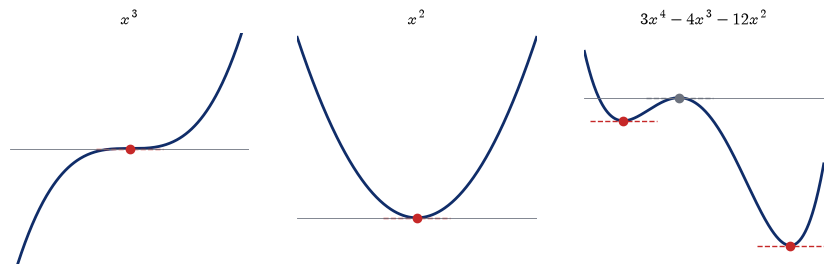

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.0))
wells_kinds = ["min" if c > 0 else "max" for c in get("ex.wells.second")]
wells_title = "$" + get("ex.wells.tex.f").replace(" ", "") + "$"
panels = [
    (lambda x: x**3, (-1.25, 1.25), (-1.6, 1.6), [0.0], ["flat"], r"$x^3$"),
    (lambda x: x**2, (-1.25, 1.25), (-0.4, 1.6), [0.0], ["min"], r"$x^2$"),
    (wells, WELLS_RANGE, (-36, 14), get("ex.wells.stationary"), wells_kinds, wells_title),
]
for ax, (fn, (lo, hi), (bottom, top), marked, kinds, title) in zip(axes, panels):
    xs = np.linspace(lo, hi, 400)
    ax.plot(xs, fn(xs), color=HSE["blue"], lw=2)
    half = 0.35 * (hi - lo) / 2.5
    for x0, kind in zip(marked, kinds):
        color = HSE["gray"] if kind == "max" else HSE["accent"]
        dot(ax, (x0, fn(x0)), color)
        ax.plot([x0 - half, x0 + half], [fn(x0), fn(x0)], color=color, lw=1.0, ls="--")
    ax.axhline(0, color=HSE["gray"], lw=0.6)
    ax.set_title(title, fontsize=12)
    clean_axes(ax, (lo, hi, bottom, top), equal=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
save(fig, "fig_stationary")
plt.show()

### Level sets of three quadratics

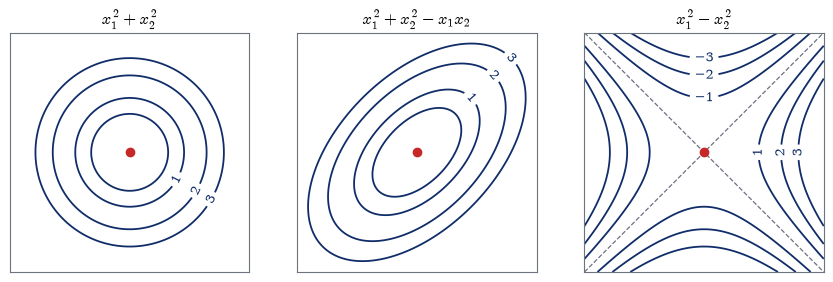

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6))
X, Y = np.meshgrid(np.linspace(*LEVEL_EXT[:2], 401), np.linspace(*LEVEL_EXT[2:], 401))
titles = [r"$x_1^2+x_2^2$", "$" + get("ex.cross.tex.f").replace(" ", "") + "$", r"$x_1^2-x_2^2$"]
for k, ax in enumerate(axes):
    levels = LEVEL_LEVELS[k]
    cs = ax.contour(X, Y, LEVEL_FUNCS[k](X, Y), levels=levels, colors=[HSE["blue"]], linewidths=1.3,
                    negative_linestyles="solid")
    integer_levels = [c for c in levels if float(c).is_integer()]
    ax.clabel(cs, levels=integer_levels, fmt=INT, fontsize=9, inline=True, manual=LEVEL_LABELS[k])
    if k == 2:
        # the level 0 of x_1^2 - x_2^2 is the pair of diagonals
        x_lo, x_hi, y_lo, y_hi = LEVEL_EXT
        ax.plot([x_lo, x_hi], [y_lo, y_hi], ls="--", color=HSE["gray"], lw=0.9)
        ax.plot([x_lo, x_hi], [y_hi, y_lo], ls="--", color=HSE["gray"], lw=0.9)
    dot(ax, (0, 0), HSE["accent"])
    ax.set_title(titles[k], fontsize=12)
    clean_axes(ax, LEVEL_EXT)
save(fig, "fig_level_sets")
plt.show()

### Gradient, tangent and a descent direction

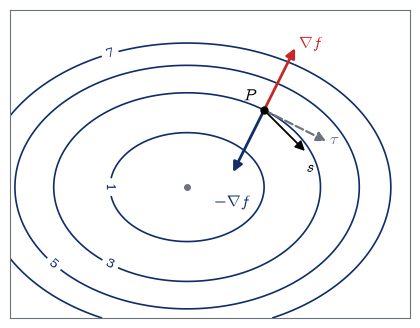

In [43]:
fig, ax = plt.subplots(figsize=(5.4, 4.0))
X, Y = np.meshgrid(np.linspace(*GRAD_EXT[:2], GRAD_GRID[0]), np.linspace(*GRAD_EXT[2:], GRAD_GRID[1]))
cs = ax.contour(X, Y, GRAD_FUNC(X, Y), levels=GRAD_LEVELS, colors=[HSE["blue"]], linewidths=1.2,
                negative_linestyles="solid")
ax.clabel(cs, fmt=INT, fontsize=9, inline=True, manual=GRAD_LABELS)
P = np.array(get("ex.dir.point"), float)
unit = lambda key: np.array(get(key), float) / np.linalg.norm(get(key))
u, tau, s_dir = unit("ex.dir.grad"), unit("ex.dir.tangent"), unit("ex.dir.s")
arrow(ax, P, 0.9 * u, HSE["accent"])
arrow(ax, P, -0.9 * u, HSE["blue"])
arrow(ax, P, 0.9 * tau, HSE["gray"], lw=1.6, ls="--")
arrow(ax, P, 0.75 * s_dir, "black", lw=1.3)
dot(ax, P, "black", ms=5, z=6)
dot(ax, (0, 0), HSE["gray"], ms=4)
ax.text(*(P + 0.9 * u + np.array([0.05, 0.0])), r"$\nabla f$", color=HSE["accent"], fontsize=12)
ax.text(*(P - 0.9 * u + np.array([-0.25, -0.45])), r"$-\nabla f$", color=HSE["blue"], fontsize=12)
ax.text(*(P + 0.9 * tau + np.array([0.05, -0.05])), r"$\tau$", color=HSE["gray"], fontsize=12)
ax.text(*(P + 0.75 * s_dir + np.array([0.02, -0.28])), r"$s$", color="black", fontsize=12)
ax.text(P[0] - 0.12, P[1] + 0.12, r"$P$", fontsize=12, ha="right")
clean_axes(ax, GRAD_EXT)
save(fig, "fig_gradient")
plt.show()

### Level sets of four quadratic forms

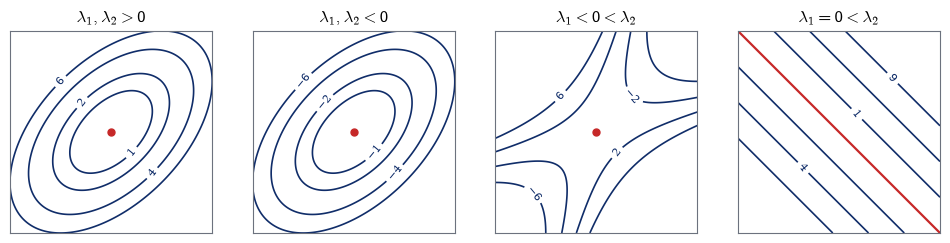

In [44]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
X, Y = np.meshgrid(np.linspace(*DEF_EXT[:2], 401), np.linspace(*DEF_EXT[2:], 401))
for ax, key, title, levels, labels in zip(axes, DEF_MATRICES, DEF_TITLES, DEF_LEVELS, DEF_LABELS):
    form = np.array(get(key), float)
    Z = form[0, 0] * X**2 + 2 * form[0, 1] * X * Y + form[1, 1] * Y**2
    cs = ax.contour(X, Y, Z, levels=levels, colors=[HSE["blue"]], linewidths=1.2, negative_linestyles="solid")
    ax.clabel(cs, fmt=INT, fontsize=8, inline=True, manual=[labels[c] for c in levels])
    if abs(np.linalg.eigvalsh(form)).min() < 1e-12:
        # a zero eigenvalue: the flat bottom x_1 + x_2 = 0 along its eigenvector
        ax.plot([-2, 2], [2, -2], color=HSE["accent"], lw=1.6)
    else:
        dot(ax, (0, 0), HSE["accent"], ms=5)
    ax.set_title(title, fontsize=12)
    clean_axes(ax, DEF_EXT)
save(fig, "fig_definiteness")
plt.show()

### Feasible directions in the quadrant

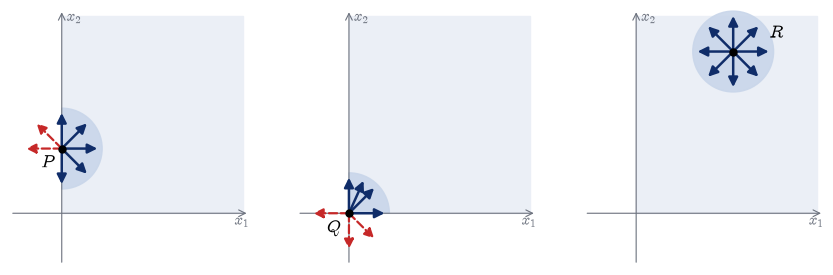

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6))
points = ["boundary", "corner", "interior"]
directions = [FEAS_BOUNDARY, FEAS_CORNER, FEAS_INTERIOR]
letters = ["$P$", "$Q$", "$R$"]
panels = zip(axes, points, FEAS_WEDGES, directions, letters, FEAS_LABEL_SHIFTS)
for ax, point, (theta1, theta2), (good, bad), letter, shift in panels:
    pt = get(f"ex.quadrant.{point}")
    ax.add_patch(plt.Rectangle((0, 0), *FEAS_QUADRANT, color=HSE["light"], zorder=0))
    axes_lines(ax, FEAS_EXT)
    ax.add_patch(Wedge(pt, 1.25, theta1, theta2, color=HSE["fill"], alpha=0.9, zorder=1))
    for direction in good:
        direction = np.array(direction, float)
        arrow(ax, pt, 1.1 * direction / np.linalg.norm(direction), HSE["blue"], lw=1.8)
    for direction in bad:
        direction = np.array(direction, float)
        arrow(ax, pt, 1.1 * direction / np.linalg.norm(direction), HSE["accent"], lw=1.6, ls="--")
    dot(ax, pt, "black", ms=5, z=6)
    ax.text(pt[0] + shift[0], pt[1] + shift[1], letter, fontsize=13, ha="center", va="center")
    clean_axes(ax, FEAS_EXT)
save(fig, "fig_feasible")
plt.show()

### Two functions with a zero Hessian at the origin

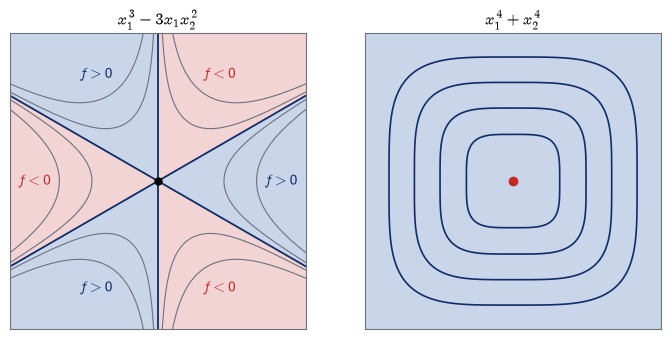

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 4.0))
X, Y = np.meshgrid(np.linspace(*MONKEY_EXT[:2], 601), np.linspace(*MONKEY_EXT[2:], 601))

ax = axes[0]
F2 = X**3 - 3 * X * Y**2
ax.contourf(X, Y, F2, levels=[-100, 0, 100], colors=[HSE["fill2"], HSE["fill"]])
ax.contour(X, Y, F2, levels=MONKEY_LEVELS[0], colors=[HSE["gray"]], linewidths=0.8, negative_linestyles="solid")
for deg in get("ex.monkey.zeroDeg"):
    cos_d, sin_d = math.cos(math.radians(deg)), math.sin(math.radians(deg))
    ax.plot([-2 * cos_d, 2 * cos_d], [-2 * sin_d, 2 * sin_d], color=HSE["blue"], lw=1.3)
for key, label, color in (("ex.monkey.plusDeg", r"$f>0$", HSE["blue"]), ("ex.monkey.minusDeg", r"$f<0$", HSE["accent"])):
    for deg in get(key):
        label_x, label_y = MONKEY_LABEL_R * math.cos(math.radians(deg)), MONKEY_LABEL_R * math.sin(math.radians(deg))
        ax.text(label_x, label_y, label, ha="center", va="center", color=color, fontsize=11)
dot(ax, (0, 0), "black", ms=5)
ax.set_title("$" + get("ex.gap.tex.f2").replace(" ", "") + "$", fontsize=12)
clean_axes(ax, MONKEY_EXT)

ax = axes[1]
F1 = X**4 + Y**4
ax.contourf(X, Y, F1, levels=[0, 100], colors=[HSE["fill"]])
ax.contour(X, Y, F1, levels=MONKEY_LEVELS[1], colors=[HSE["blue"]], linewidths=1.2, negative_linestyles="solid")
dot(ax, (0, 0), HSE["accent"], ms=6)
ax.set_title("$" + get("ex.gap.tex.f1").replace(" ", "") + "$", fontsize=12)
clean_axes(ax, MONKEY_EXT)
save(fig, "fig_monkey")
plt.show()

### Convex and nonconvex sets and functions

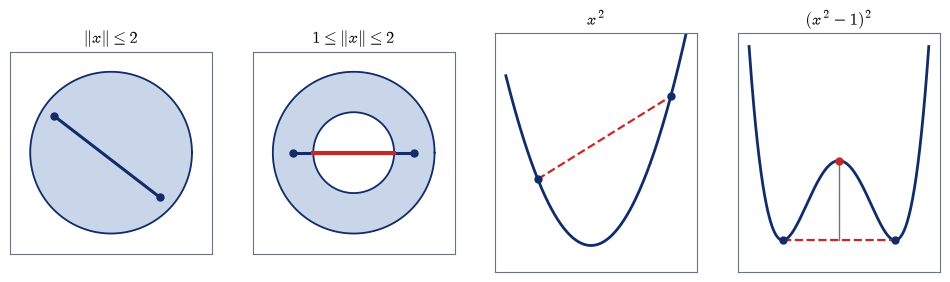

In [47]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.1))
th = np.linspace(0, 2 * np.pi, 400)

ax = axes[0]
ax.fill(disk_r * np.cos(th), disk_r * np.sin(th), color=HSE["fill"])
ax.plot(disk_r * np.cos(th), disk_r * np.sin(th), color=HSE["blue"], lw=1.3)
ax.plot(*zip(*DISK_SEG), color=HSE["blue"], lw=2.2)
for end in DISK_SEG:
    dot(ax, end, HSE["blue"], ms=5)
ax.set_title(CONVEX_TITLES[0], fontsize=12)
clean_axes(ax, CONVEX_EXT)

ax = axes[1]
ring_x = np.r_[ring_r2 * np.cos(th), ring_r1 * np.cos(th[::-1])]
ring_y = np.r_[ring_r2 * np.sin(th), ring_r1 * np.sin(th[::-1])]
ax.fill(ring_x, ring_y, color=HSE["fill"])
ax.plot(ring_r2 * np.cos(th), ring_r2 * np.sin(th), color=HSE["blue"], lw=1.3)
ax.plot(ring_r1 * np.cos(th), ring_r1 * np.sin(th), color=HSE["blue"], lw=1.3)
(x_start, _), (x_end, _) = RING_SEG
ax.plot([x_start, -ring_r1], [0, 0], color=HSE["blue"], lw=2.2)
ax.plot([ring_r1, x_end], [0, 0], color=HSE["blue"], lw=2.2)
# the part of the segment that crosses the hole
ax.plot([-ring_r1, ring_r1], [0, 0], color=HSE["accent"], lw=3.0)
for end in RING_SEG:
    dot(ax, end, HSE["blue"], ms=5)
ax.set_title(CONVEX_TITLES[1], fontsize=12)
clean_axes(ax, CONVEX_EXT)

ax = axes[2]
xs = np.linspace(-1.6, 1.8, 300)
ax.plot(xs, xs**2, color=HSE["blue"], lw=2)
ax.plot(*zip(*CHORD_SQUARE), color=HSE["accent"], lw=1.6, ls="--")
for end in CHORD_SQUARE:
    dot(ax, end, HSE["blue"], ms=5)
ax.set_title(r"$x^2$", fontsize=12)
clean_axes(ax, (-1.8, 2.0, -0.4, 3.2), equal=False)

ax = axes[3]
xs = np.linspace(-1.6, 1.6, 300)
ax.plot(xs, (xs**2 - 1) ** 2, color=HSE["blue"], lw=2)
ax.plot(*zip(*CHORD_WELL), color=HSE["accent"], lw=1.6, ls="--")
for end in CHORD_WELL:
    dot(ax, end, HSE["blue"], ms=5)
ax.plot([0, 0], [0, 1], color=HSE["gray"], lw=1)
dot(ax, (0, 1), HSE["accent"], ms=5)
ax.set_title(r"$(x^2-1)^2$", fontsize=12)
clean_axes(ax, (-1.8, 1.8, -0.4, 2.6), equal=False)
save(fig, "fig_convexity")
plt.show()

In [48]:
put("figures", sorted(FIGURES))
assert DATA["figures"] == ["fig_convexity", "fig_definiteness", "fig_feasible", "fig_gradient",
                          "fig_level_sets", "fig_monkey", "fig_stationary"]
print(f"{len(FIGURES)} figures written: {', '.join(DATA['figures'])}")

7 figures written: fig_convexity, fig_definiteness, fig_feasible, fig_gradient, fig_level_sets, fig_monkey, fig_stationary


## 11. Export

### Data file and values.tex

In `values.tex` a key expands through `\val{A2.params.x}`; numbers are rounded to four decimals, and the Russian variant writes a decimal comma and separates coordinates with a semicolon.

In [49]:
put("meta.seed", SEED)
versions_md = VENDOR / "VERSIONS.md"
libraries = {}
if versions_md.exists():
    for line in versions_md.read_text(encoding="utf-8").splitlines():
        cells = [c.strip() for c in line.strip().strip("|").split("|")]
        if len(cells) >= 4 and re.fullmatch(r"\d+\.\d+(\.\d+)?", cells[1]):
            libraries[re.sub(r"[^A-Za-z0-9]", "", cells[0]).lower()] = cells[1]
put("meta.libraries", libraries)

CODE = {
    "centralDiff": [central_diff],
    "classify": [classify],
    "minors": [leading_minors, principal_minors],
    "convexity": [segment_leaves, jensen_violations],
    "feasible": [feasible_direction],
    "dirDeriv": [directional_derivative],
}
DATA["code"] = {k: "\n\n".join(inspect.getsource(fn).rstrip() for fn in fns) + "\n" for k, fns in CODE.items()}

GENERATED = f"Generated by checks/{NOTEBOOK}. Do not edit by hand."
LICENCE = ["SPDX-License-Identifier: MIT", "Copyright (c) 2026 Evgeny Baulin"]
payload = json.dumps(DATA, sort_keys=True, indent=1, ensure_ascii=True)
data_js = ("".join(f"// {line}\n" for line in [GENERATED, *LICENCE])
           + "window.SEM = window.SEM || {};\nwindow.SEM.data = /*JSON-BEGIN*/" + payload + "/*JSON-END*/;\n")
write_if_changed(WEB / "data" / f"seminar{SEMINAR}_data.js", data_js)


def tex_num(value, lang="en", digits=4):
    v = float(value)
    s = f"{v:.{digits}f}".rstrip("0").rstrip(".")
    if s in ("-0", ""):
        s = "0"
    return s.replace(".", "{,}") if lang == "ru" else s


def ru_tex(s):
    s = re.sub(r"(\d)\.(\d)", r"\1{,}\2", s)
    return s.replace(r",\ ", r";\ ")


def tex_mat(M):
    rows = r" \\ ".join(" & ".join(tex_num(v) for v in row) for row in M)
    return f"\\begin{{pmatrix}} {rows} \\end{{pmatrix}}"


def tex_leaf(key, value, lang):
    """TeX for one exported value, or None when the value has no TeX form."""
    if isinstance(value, bool):
        return None
    if isinstance(value, (int, float)):
        return tex_num(value, lang)
    if isinstance(value, str):
        if ".tex." in key or key.endswith(".tex"):
            return ru_tex(value) if lang == "ru" else value
        return None
    if not (isinstance(value, list) and value):
        return None
    if all(isinstance(v, (int, float)) and not isinstance(v, bool) for v in value) and len(value) <= 10:
        sep = r";\ " if lang == "ru" else ", "
        return "(" + sep.join(tex_num(v, lang) for v in value) + ")"
    matrix = all(isinstance(row, list) and row and all(isinstance(v, (int, float)) for v in row) for row in value)
    if matrix and len(value) <= 4:
        return tex_mat(value) if lang == "en" else ru_tex(tex_mat(value))
    return None


def flatten(node, prefix=""):
    if isinstance(node, dict):
        for k in sorted(node):
            yield from flatten(node[k], f"{prefix}.{k}" if prefix else k)
    else:
        yield prefix, node
        if isinstance(node, list) and len(node) <= 10:
            for i, item in enumerate(node, start=1):
                yield from flatten(item, f"{prefix}.{i}")


TEX_VALUES = {}
for key, value in flatten({k: v for k, v in DATA.items() if k not in ("code", "meta")}):
    for lang in ("en", "ru"):
        tex = tex_leaf(key, value, lang)
        if tex is not None:
            assert "%" not in tex and "#" not in tex, key
            TEX_VALUES[(lang, key)] = tex
tex_keys_en = {key for (lang, key) in TEX_VALUES if lang == "en"}

lines = [
    f"% {GENERATED}",
    *(f"% {line}" for line in LICENCE),
    "%",
    "% Usage: \\def\\valuelang{en} or \\def\\valuelang{ru} before \\input{values}, then \\val{A2.params.x}.",
    "% Vector and list entries are indexed from 1: \\val{A2.steps.grad.1}. An undefined key stops the compilation.",
    "\\providecommand{\\valuelang}{en}",
    "\\newcommand{\\val}[1]{%",
    f"  \\ifcsname s{SEMINAR}val@\\valuelang @#1\\endcsname",
    f"    \\csname s{SEMINAR}val@\\valuelang @#1\\endcsname",
    "  \\else",
    "    \\errmessage{values.tex: undefined key #1}%",
    "  \\fi}",
]
for (lang, key), tex in sorted(TEX_VALUES.items()):
    lines.append(f"\\expandafter\\def\\csname s{SEMINAR}val@{lang}@{key}\\endcsname{{{tex}}}")
values_tex = "\n".join(lines) + "\n"
write_if_changed(THEORY / "values.tex", values_tex)
print(f"data: {len(payload):,} characters; values.tex: {len(TEX_VALUES) // 2} keys per language")

data: 31,967 characters; values.tex: 1321 keys per language


### LaTeX handout and cheat sheet

`Theory_en.tex`, `Theory_ru.tex`, `Cheatsheet_en.tex` and `Cheatsheet_ru.tex` are converted from the content files `content-handout.js` and `content-cheatsheet.js`. Numbers enter the LaTeX as `\val{key}` from `values.tex`.

In [50]:
# LaTeX generator: Theory_{en,ru}.tex and Cheatsheet_{en,ru}.tex
TOKEN = re.compile(r"\{\{\s*([A-Za-z0-9.]+)\s*\}\}")


def marked_json(path):
    """(strict JSON between /*JSON-BEGIN*/ and /*JSON-END*/, text around it); None without the markers."""
    text = Path(path).read_text(encoding="utf-8")
    m = re.search(r"/\*JSON-BEGIN\*/(.*)/\*JSON-END\*/", text, re.S)
    if m is None:
        return None, text
    return json.loads(m.group(1)), text[: m.start()] + text[m.end() :]


def segments(s):
    """The segmenter of render.js: $$display$$, $inline$, \\$ a literal dollar, text; an unclosed $ stays text."""
    out, buf, i = [], "", 0
    while i < len(s):
        ch = s[i]
        if ch == "\\" and s[i + 1 : i + 2] == "$":
            buf += "\x03"
            i += 2
            continue
        if ch == "$":
            display = s[i + 1 : i + 2] == "$"
            n = 2 if display else 1
            close = s.find("$$" if display else "$", i + n)
            if close < 0:
                buf += s[i:]
                break
            if buf:
                out.append(("text", buf))
            buf = ""
            out.append(("display" if display else "math", s[i + n : close]))
            i = close + n
            continue
        buf += ch
        i += 1
    if buf:
        out.append(("text", buf))
    return out


ESC = [("{", r"\{"), ("}", r"\}"), ("%", r"\%"), ("&", r"\&"), ("#", r"\#"), ("_", r"\_"),
       ("~", r"\textasciitilde{}"), ("^", r"\textasciicircum{}")]


def esc(text):
    text = text.replace("\\", "\x00")
    for a, b in ESC:
        text = text.replace(a, b)
    return text.replace("\x00", r"\textbackslash{}")


def R(s):
    """One content string as LaTeX: tokens become \\val{key} and the markup \\textbf, \\emph, \\texttt."""
    parts = []
    for kind, seg in segments(s):
        if kind in ("math", "display"):
            body = TOKEN.sub(lambda m: r"\val{" + m.group(1) + "}", seg)
            assert "%" not in body and "#" not in body and "{{" not in body, seg
            parts.append("$" + body + "$" if kind == "math" else "\n\\[\n" + body.strip() + "\n\\]\n")
            continue
        # tokens and code spans are set aside before escaping and restored after the markup
        toks, codes = [], []
        t = TOKEN.sub(lambda m: toks.append(m.group(1)) or f"\x01{len(toks) - 1}\x01", seg)
        t = re.sub(r"`([^`]+)`", lambda m: codes.append(esc(m.group(1))) or f"\x02{len(codes) - 1}\x02", t)
        t = esc(t).replace("\x03", r"\$")
        t = re.sub(r"\*\*([^*]+)\*\*", r"\\textbf{\1}", t)
        t = re.sub(r"\*([^*\s][^*]*)\*", r"\\emph{\1}", t)
        t = re.sub("\x02(\\d+)\x02", lambda m: r"\texttt{" + codes[int(m.group(1))] + "}", t)
        t = re.sub("\x01(\\d+)\x01", lambda m: r"\val{" + toks[int(m.group(1))] + "}", t)
        parts.append(t)
    out = "".join(parts)
    assert not re.search("[\x00-\x03\u00a0]", out), s
    return out


def cell_kind(cell):
    segs = segments(cell)
    if len(segs) == 1 and segs[0][0] == "math":
        body = TOKEN.sub("v", segs[0][1]).strip()
        if re.fullmatch(r"v|-?\d+(\.\d+)?", body):
            return "num"
    if all(k != "text" or re.fullmatch(r"[\s,]*", v) for k, v in segs):
        return "math"
    return "text"


def cell_width(cell):
    """Printed width of a table cell in characters; a token or a TeX command counts as one."""
    w = 0
    for kind, seg in segments(cell):
        if kind == "text":
            w += len(TOKEN.sub("0", seg).replace("**", "").replace("*", "").replace("`", ""))
        else:
            body = TOKEN.sub("v", seg)
            body = re.sub(r"\\[A-Za-z]+", "c", body)
            w += 2 + len(body)
    return w


# room the paragraph columns must leave: a character of a column that keeps its natural width takes at
# most this fraction of the 466.6pt text width at \small, and 2\tabcolsep between two columns takes 12pt
CHAR_SHARE = {"text": 0.012, "math": 0.010, "num": 0.010}
GAP_SHARE = 0.026


def table_spec(head, rows):
    ncol = len(head)
    kinds, widths = [], []
    for j in range(ncol):
        body = [r[j] for r in rows]
        ks = {cell_kind(c) for c in body}
        kinds.append("num" if ks == {"num"} else "math" if ks <= {"num", "math"} else "text")
        widths.append(max(cell_width(c) for c in [head[j]] + body))
    total = sum(widths)
    spec = ["r" if k == "num" else "l" for k in kinds]
    # a wide table gets paragraph columns for its long text columns, or for its widest column
    if total > 70:
        wide = [j for j in range(ncol) if kinds[j] == "text" and widths[j] >= 18]
        if wide:
            shares = {j: 0.9 * widths[j] / total for j in wide}
        else:
            wide = [max(range(ncol), key=lambda k: widths[k])]
            shares = {wide[0]: 0.4}
        natural = sum(CHAR_SHARE[kinds[j]] * widths[j] for j in range(ncol) if j not in wide)
        budget = 0.98 - GAP_SHARE * (ncol - 1) - natural
        # the fractions are scaled into the budget and rounded down, so their sum plus the natural
        # columns stays inside \linewidth however the estimate of the natural ones errs
        scale = min(1.0, budget / sum(shares.values()))
        for j in wide:
            share = f"{max(0.15, int(100 * shares[j] * scale) / 100):g}"
            spec[j] = r">{\raggedright\arraybackslash}p{" + share + r"\linewidth}"
    return "@{}" + "".join(spec) + "@{}"


def table_tex(block, lang):
    head = [c[lang] for c in block["head"]]
    rows = [[c[lang] for c in row] for row in block["rows"]]
    spec = table_spec(head, rows)
    line = lambda cells: " & ".join(R(c) for c in cells) + r" \\"
    body = [line(r) for r in rows]
    if len(rows) > 10:
        return "\n".join([r"\begingroup\small", r"\begin{longtable}{" + spec + "}", r"\toprule", line(head),
                          r"\midrule", r"\endhead", *body, r"\bottomrule", r"\end{longtable}", r"\endgroup"])
    return "\n".join([r"\begin{center}\small", r"\begin{tabular}{" + spec + "}", r"\toprule", line(head),
                      r"\midrule", *body, r"\bottomrule", r"\end{tabular}", r"\end{center}"])


FIG_WIDTH = {"fig_stationary": 0.95, "fig_level_sets": 0.95, "fig_gradient": 0.5, "fig_definiteness": 1.0,
             "fig_feasible": 0.95, "fig_monkey": 0.8, "fig_convexity": 1.0}
LABELS = {
    "en": {"statement": "Statement", "figure": "Figure", "term": "Term", "kicker": "Seminar 01 cheat sheet"},
    "ru": {"statement": "Условие", "figure": "Рисунок", "kicker": "Шпаргалка к семинару 1"},
}


def period(s):
    return s if s.endswith((".", "?", "!")) else s + "."


def block_tex(b, lang, ui, content, code):
    t = b["type"]
    L = lambda pair: pair[lang]
    if t == "p":
        return R(L(b["text"]))
    if t in ("example", "intuition"):
        env = "examplebox" if t == "example" else "whybox"
        return f"\\begin{{{env}}}\n{R(L(b['text']))}\n\\end{{{env}}}"
    if t == "list":
        return "\\begin{itemize}\n" + "\n".join("  \\item " + R(L(i)) for i in b["items"]) + "\n\\end{itemize}"
    if t == "figure":
        name = re.fullmatch(r"figures/(fig_[a-z_]+)\.svg", b["src"]).group(1)
        cap = R(L(b["caption"])) if b.get("caption") else ""
        return f"\\handoutfigure{{{FIG_WIDTH[name]:g}}}{{{name}}}{{{cap}}}"
    if t == "table":
        return table_tex(b, lang)
    if t == "definition":
        label = ui("pages.definition", lang) + (": " + R(L(b["title"])) if b.get("title") else "")
        return f"\\begin{{definitionbox}}{{{period(label)}}}\n{R(L(b['text']))}\n\\end{{definitionbox}}"
    if t == "theorem":
        label = ui("pages." + b["kind"], lang) + (": " + R(L(b["title"])) if b.get("title") else "")
        return f"\\begin{{theorembox}}{{{period(label)}}}\n{R(L(b['text']))}\n\\end{{theorembox}}"
    if t in ("proof", "trap"):
        env = t + "box"
        return f"\\begin{{{env}}}\n{R(L(b['text']))}\n\\end{{{env}}}"
    if t == "note":
        return f"\\begin{{notebox}}{{{R(L(b['title']))}}}\n{R(L(b['text']))}\n\\end{{notebox}}"
    if t == "selfcheck":
        return (f"\\begin{{selfcheckbox}}\n{R(L(b['question']))}\n"
                f"\\selfcheckanswer {R(L(b['answer']))}\n\\end{{selfcheckbox}}")
    if t == "code":
        src = code[b["key"]].expandtabs(4).rstrip("\n")
        assert src.isascii() and "\\end{lstlisting}" not in src
        return ("\\begin{codebox}\n\\begin{lstlisting}[style=handoutcode]\n" + src
                + "\n\\end{lstlisting}\n\\end{codebox}")
    if t == "faq":
        return f"\\faqquestion{{{R(L(b['question']))}}}\n{R(L(b['answer']))}"
    if t == "problem":
        return problem_tex(b["id"], lang, ui, content)
    if t == "mistakes":
        items = content["main"]["mistakes"][b["block"]]
        return ("\\begin{itemize}[label=\\textcolor{hseaccent}{\\textbullet}]\n"
                + "\n".join("  \\item " + R(L(m)) for m in items) + "\n\\end{itemize}")
    if t == "glossary":
        return glossary_tex(b["items"], lang, ui)
    if t == "references":
        items = []
        for it in b["items"]:
            s = R(L(it))
            if lang == "ru":
                # the Latin head of a reference is typeset with English hyphenation
                m = re.match(r"([A-Za-z][^\u0400-\u04FF]*?)(\s*)(?=[\u0400-\u04FF])", s)
                if m:
                    s = "\\textenglish{" + m.group(1) + "}" + m.group(2) + s[m.end():]
            items.append("  \\item " + s)
        return "\\begin{enumerate}[label={[\\arabic*]}, leftmargin=*]\n" + "\n".join(items) + "\n\\end{enumerate}"
    raise ValueError(f"unknown block type {t}")


def find_problem(pid, content):
    if pid in content["problems"]:
        return content["problems"][pid]
    for blk in content["main"]["blocks"].values():
        for it in (blk.get("home") or {}).get("items", []):
            if it["id"] == pid:
                return it
    raise KeyError(pid)


def problem_tex(pid, lang, ui, content):
    P = find_problem(pid, content)
    if "skill" in P:
        third = R(P["skill"][lang])
    else:
        third = ui("problem.byHand" if P.get("kind") == "hand" else "problem.inCode", lang)
    steps = []
    for st in P["steps"]:
        assert "table" not in st, pid
        steps.append("  \\item " + R(st["text"][lang]))
    return "\n".join([
        f"\\problemhead{{{pid}}}{{{R(P['title'][lang])}}}{{{third}}}",
        f"\\textbf{{{LABELS[lang]['statement']}.}} {R(P['statement'][lang])}",
        "",
        f"\\textbf{{{period(ui('problem.solution', lang))}}}",
        # a step quotes code and numbers that cannot be hyphenated: let the spaces stretch instead
        "\\begingroup\\sloppy",
        "\\begin{enumerate}[label=\\textbf{\\arabic*.}, leftmargin=*]",
        *steps,
        "\\end{enumerate}",
        "\\endgroup",
        "\\begin{answerbox}",
        R(P["answerText"][lang]),
        "\\end{answerbox}",
    ])


def glossary_tex(items, lang, ui):
    col = r">{\raggedright\arraybackslash}p{%s\linewidth}"
    if lang == "en":
        head = [r"\begin{longtable}{@{}" + col % "0.3" + col % "0.66" + "@{}}", r"\toprule",
                f"\\textbf{{{LABELS['en']['term']}}} & \\textbf{{{esc(ui('pages.glossaryNote', 'en'))}}} \\\\"]
        rows = [f"{esc(i['en'])} & {esc(i['note']['en'])} \\\\" for i in items]
    else:
        names = [esc(ui(f"pages.{k}", "ru")) for k in ("glossaryEn", "glossaryRu", "glossaryNote")]
        head = [r"\begin{longtable}{@{}" + col % "0.26" + col % "0.26" + col % "0.42" + "@{}}", r"\toprule",
                " & ".join(f"\\textbf{{{n}}}" for n in names) + " \\\\"]
        rows = [f"\\textenglish{{{esc(i['en'])}}} & {esc(i['ru'])} & {esc(i['note']['ru'])} \\\\" for i in items]
    middle = [r"\midrule", r"\endhead", r"\bottomrule", r"\endlastfoot"]
    return "\n".join(head + middle + rows + [r"\end{longtable}"])


def fill(template, values):
    for name, value in values.items():
        placeholder = f"<<{name}>>"
        assert template.count(placeholder) == 1, name
        template = template.replace(placeholder, value)
    assert "<<" not in template
    return template


def theory_doc(lang, ui, content, code, template):
    h = content["handout"]
    course, seminar, author = ui("meta.course", lang), ui("meta.seminarLabel", lang), ui("meta.author", lang)
    values = {
        "pdftitle": esc(f"{course}. {seminar}. {ui('meta.pageName.theory', lang)}"),
        "pdfauthor": esc(author),
        "labelExample": period(esc(ui("pages.example", lang))),
        "labelWhy": period(esc(ui("pages.intuition", lang))),
        "labelAnswer": period(esc(ui("problem.answer", lang).rstrip().rstrip(":"))),
        "labelConvention": period(esc(ui("pages.convention", lang))),
        "labelFigure": period(LABELS[lang]["figure"]),
        "labelProof": period(esc(ui("pages.proof", lang))),
        "labelTrap": period(esc(ui("pages.trap", lang))),
        "labelSelfcheck": period(esc(ui("pages.selfcheck", lang))),
        "labelSelfcheckAnswer": period(esc(ui("pages.answer", lang))),
        "headerCourse": esc(course),
        "headerSeminar": esc(seminar),
        "footerAuthor": esc(author),
        "titleCourse": esc(course),
        "titleSeminar": esc(seminar),
        "titleTopic": R(h["title"][lang]),
        "titlePage": esc(ui("meta.pageName.theory", lang)),
        "titleInstitution": esc(ui("meta.institution", lang)),
        "titleYear": esc(ui("meta.year", lang)),
        "titleLecturer": esc(ui("meta.lecturerCredit", lang)),
        "titleAuthor": esc(author),
    }
    out = [fill(template, values), "", R(h["intro"][lang]), "",
           "\\begin{conventionbox}", R(h["convention"][lang]), "\\end{conventionbox}", ""]
    for sec in h["sections"]:
        out += ["% " + "=" * 69, f"\\section{{{R(sec['title'][lang])}}}\\label{{sec:{sec['id']}}}", ""]
        for b in sec.get("blocks", []):
            out += [block_tex(b, lang, ui, content, code), ""]
        for sub in sec.get("subsections", []):
            out += [f"\\subsection{{{R(sub['title'][lang])}}}\\label{{sub:{sub['id']}}}", ""]
            for b in sub.get("blocks", []):
                out += [block_tex(b, lang, ui, content, code), ""]
    out.append("\\end{document}")
    return "\n".join(out) + "\n"


def split_title(title):
    """Break the title into two lines at the space nearest to its middle."""
    spaces = [i for i, ch in enumerate(title) if ch == " "]
    cut = min(spaces, key=lambda i: abs(i - len(title) / 2))
    return title[:cut] + "\\\\ " + title[cut + 1 :]


def cheat_doc(lang, ui, content, template):
    cs = content["cheatsheet"]
    values = {"pdftitle": esc(LABELS[lang]["kicker"] + ": " + cs["title"][lang]), "kicker": LABELS[lang]["kicker"],
              "title": split_title(R(cs["title"][lang]))}
    out = [fill(template, values), ""]
    for sec in cs["sections"]:
        out += [f"% ---- {sec['id']}", f"\\cssec{{{R(sec['title'][lang])}}}", "\\begin{itemize}"]
        out += ["  \\item " + R(it[lang]) for it in sec["items"]]
        out += ["\\end{itemize}", ""]
    out += ["\\end{multicols}", "\\end{document}"]
    return "\n".join(out) + "\n"


THEORY_PREAMBLE_EN = r"""% SPDX-License-Identifier: MIT
% Copyright (c) 2026 Evgeny Baulin
% Optimization Methods, Seminar 01: theory handout (English).
% Generated by checks/01. Optimization as the Foundation of Machine Learning.ipynb from web/01/js/content-*.js. Do not edit by hand.
% Compile with: latexmk -xelatex -interaction=nonstopmode -halt-on-error Theory_en.tex
\documentclass[11pt,a4paper]{article}

\usepackage{fontspec}
\setmainfont{cmunrm.otf}[BoldFont=cmunbx.otf, ItalicFont=cmunti.otf, BoldItalicFont=cmunbi.otf]
\setsansfont{cmunss.otf}[BoldFont=cmunsx.otf, ItalicFont=cmunsi.otf, BoldItalicFont=cmunso.otf]
\setmonofont{cmuntt.otf}[BoldFont=cmuntb.otf, ItalicFont=cmunit.otf, BoldItalicFont=cmuntx.otf]
\usepackage{polyglossia}
\setdefaultlanguage{english}

\usepackage[a4paper,left=2.3cm,right=2.3cm,top=2.4cm,bottom=2.4cm,headheight=14pt]{geometry}
\usepackage{amsmath,amssymb}
\usepackage{graphicx}
\usepackage{array,booktabs,longtable}
\usepackage{enumitem}
\usepackage{xcolor}
\usepackage{listings}
\usepackage[most]{tcolorbox}
\usepackage{titlesec}
\usepackage{fancyhdr}
\usepackage[expansion=false]{microtype}
\usepackage[colorlinks=true,linkcolor=hseblue,urlcolor=hseblue,citecolor=hseblue]{hyperref}

\definecolor{hseblue}{RGB}{16,45,105}
\definecolor{hseaccent}{RGB}{198,40,40}
\definecolor{hsegray}{RGB}{108,114,126}
\definecolor{hselight}{RGB}{240,243,248}
\definecolor{hsewarm}{RGB}{253,244,232}

\def\valuelang{en}
\input{values}

\hypersetup{pdftitle={<<pdftitle>>}, pdfauthor={<<pdfauthor>>}}

\titleformat{\section}{\color{hseblue}\Large\bfseries}{\thesection}{0.6em}{}
\titleformat{\subsection}{\color{hseblue}\large\bfseries}{\thesubsection}{0.6em}{}
\titlespacing*{\section}{0pt}{16pt plus 4pt minus 2pt}{8pt plus 2pt}
\titlespacing*{\subsection}{0pt}{12pt plus 3pt minus 2pt}{6pt plus 2pt}

\tcbset{handoutbox/.style={enhanced, breakable, sharp corners, boxrule=0pt, left=7pt, right=7pt, top=5pt, bottom=5pt, before skip=8pt plus 2pt, after skip=8pt plus 2pt}}
\newtcolorbox{examplebox}{handoutbox, colback=hselight, colframe=hselight, before upper={\textcolor{hseblue}{\bfseries <<labelExample>>}\ }}
\newtcolorbox{whybox}{handoutbox, colback=white, colframe=hseblue, leftrule=2.5pt, top=3pt, bottom=3pt, before upper={\textcolor{hseaccent}{\bfseries <<labelWhy>>}\ }}
\newtcolorbox{answerbox}{handoutbox, colback=hsewarm, colframe=hsewarm, before upper={\textcolor{hseaccent}{\bfseries <<labelAnswer>>}\ }}
\newtcolorbox{conventionbox}{handoutbox, colback=hselight, colframe=hseblue, leftrule=2.5pt, before upper={\textcolor{hseblue}{\bfseries <<labelConvention>>}\par\smallskip}}

\newcommand{\handoutfigure}[3]{\par\medskip\noindent\begin{minipage}{\linewidth}\centering
  \includegraphics[width=#1\linewidth]{figures/#2.pdf}\par\smallskip
  \begin{minipage}{0.94\linewidth}\small\textcolor{hseblue}{\bfseries <<labelFigure>>}\ #3\end{minipage}\end{minipage}\par\medskip}
\newcommand{\problemhead}[3]{\par\bigskip\noindent{\color{hseblue}\large\bfseries #1.\ #2}\par\nopagebreak
  \noindent{\small\itshape\color{hsegray}#3}\par\nopagebreak\smallskip}
\lstdefinestyle{handoutcode}{language=Python, basicstyle=\ttfamily\small, keywordstyle=\color{hseblue}\bfseries,
  commentstyle=\color{hsegray}\itshape, stringstyle=\color{hseaccent}, showstringspaces=false,
  columns=fullflexible, keepspaces=true, breaklines=true}
\newtcolorbox{definitionbox}[1]{handoutbox, colback=white, colframe=hseblue, leftrule=2.5pt, before upper={\textcolor{hseblue}{\bfseries #1}\ }}
\newtcolorbox{theorembox}[1]{handoutbox, colback=hselight, colframe=hseblue, leftrule=2.5pt, before upper={\textcolor{hseblue}{\bfseries #1}\ }}
\newtcolorbox{proofbox}{handoutbox, colback=white, colframe=hsegray, leftrule=1.2pt, top=3pt, bottom=3pt, before upper={\textcolor{hsegray}{\bfseries\itshape <<labelProof>>}\ }}
\newtcolorbox{notebox}[1]{handoutbox, colback=hselight, colframe=hselight, before upper={\textcolor{hseblue}{\bfseries #1}\par\smallskip}}
\newtcolorbox{trapbox}{handoutbox, colback=hsewarm, colframe=hseaccent, leftrule=2.5pt, before upper={\textcolor{hseaccent}{\bfseries <<labelTrap>>}\ }}
\newtcolorbox{selfcheckbox}{handoutbox, colback=white, colframe=hseaccent, leftrule=2.5pt, top=3pt, bottom=3pt, before upper={\textcolor{hseaccent}{\bfseries <<labelSelfcheck>>}\ }}
\newcommand{\selfcheckanswer}{\par\smallskip\textcolor{hsegray}{\bfseries <<labelSelfcheckAnswer>>}\ }
\newtcolorbox{codebox}{handoutbox, colback=hselight, colframe=hselight}
\newcommand{\faqquestion}[1]{\par\medskip\noindent{\color{hseblue}\bfseries #1}\par\nopagebreak\smallskip}

\setlist[itemize]{itemsep=3pt,topsep=4pt}
\setlist[enumerate]{itemsep=3pt,topsep=4pt}
\setlength{\parindent}{0pt}
\setlength{\parskip}{5pt plus 1pt}
\setcounter{tocdepth}{2}

\pagestyle{fancy}
\fancyhf{}
\fancyhead[L]{\small\color{hsegray}<<headerCourse>>}
\fancyhead[R]{\small\color{hsegray}<<headerSeminar>>}
\fancyfoot[L]{\small\color{hsegray}<<footerAuthor>>}
\fancyfoot[C]{\small\thepage}
\fancyfoot[R]{\small\color{hsegray}MIT License}
\renewcommand{\headrulewidth}{0pt}
\renewcommand{\footrulewidth}{0pt}
\fancypagestyle{plain}{\pagestyle{fancy}}

\begin{document}

\begin{center}
  {\large\color{hsegray}<<titleCourse>>\par}
  \vspace{4pt}
  {\large\bfseries\color{hseaccent}<<titleSeminar>>\par}
  \vspace{8pt}
  {\LARGE\bfseries\color{hseblue}<<titleTopic>>\par}
  \vspace{8pt}
  {\Large <<titlePage>>\par}
  \vspace{12pt}
  <<titleInstitution>>\par
  <<titleYear>>\par
  \vspace{8pt}
  <<titleLecturer>>\par
  <<titleAuthor>>\par
  Telegram: \href{https://t.me/tarakan_tuc}{@tarakan\_tuc}\par
\end{center}

\noindent{\color{hseblue}\rule{\linewidth}{0.6pt}}

\tableofcontents

\clearpage
"""

THEORY_PREAMBLE_RU = r"""% SPDX-License-Identifier: MIT
% Copyright (c) 2026 Evgeny Baulin
% Optimization Methods, Seminar 01: theory handout (Russian).
% Generated by checks/01. Optimization as the Foundation of Machine Learning.ipynb from web/01/js/content-*.js. Do not edit by hand.
% Compile with: latexmk -xelatex -interaction=nonstopmode -halt-on-error Theory_ru.tex
\documentclass[11pt,a4paper]{article}

\usepackage{fontspec}
\setmainfont{cmunrm.otf}[BoldFont=cmunbx.otf, ItalicFont=cmunti.otf, BoldItalicFont=cmunbi.otf]
\setsansfont{cmunss.otf}[BoldFont=cmunsx.otf, ItalicFont=cmunsi.otf, BoldItalicFont=cmunso.otf]
\setmonofont{cmuntt.otf}[BoldFont=cmuntb.otf, ItalicFont=cmunit.otf, BoldItalicFont=cmuntx.otf]
\usepackage{polyglossia}
\setdefaultlanguage{russian}
\setotherlanguage{english}
\newfontfamily\cyrillicfont{cmunrm.otf}[Ligatures=TeX, BoldFont=cmunbx.otf, ItalicFont=cmunti.otf, BoldItalicFont=cmunbi.otf]
\newfontfamily\cyrillicfontsf{cmunss.otf}[Ligatures=TeX, BoldFont=cmunsx.otf, ItalicFont=cmunsi.otf, BoldItalicFont=cmunso.otf]
\newfontfamily\cyrillicfonttt{cmuntt.otf}[BoldFont=cmuntb.otf, ItalicFont=cmunit.otf, BoldItalicFont=cmuntx.otf]

\usepackage[a4paper,left=2.3cm,right=2.3cm,top=2.4cm,bottom=2.4cm,headheight=14pt]{geometry}
\usepackage{amsmath,amssymb}
\usepackage{graphicx}
\usepackage{array,booktabs,longtable}
\usepackage{enumitem}
\usepackage{xcolor}
\usepackage{listings}
\usepackage[most]{tcolorbox}
\usepackage{titlesec}
\usepackage{fancyhdr}
\usepackage[expansion=false]{microtype}
\usepackage[colorlinks=true,linkcolor=hseblue,urlcolor=hseblue,citecolor=hseblue]{hyperref}

\definecolor{hseblue}{RGB}{16,45,105}
\definecolor{hseaccent}{RGB}{198,40,40}
\definecolor{hsegray}{RGB}{108,114,126}
\definecolor{hselight}{RGB}{240,243,248}
\definecolor{hsewarm}{RGB}{253,244,232}

\def\valuelang{ru}
\input{values}

\hypersetup{pdftitle={<<pdftitle>>}, pdfauthor={<<pdfauthor>>}}

\titleformat{\section}{\color{hseblue}\Large\bfseries}{\thesection}{0.6em}{}
\titleformat{\subsection}{\color{hseblue}\large\bfseries}{\thesubsection}{0.6em}{}
\titlespacing*{\section}{0pt}{16pt plus 4pt minus 2pt}{8pt plus 2pt}
\titlespacing*{\subsection}{0pt}{12pt plus 3pt minus 2pt}{6pt plus 2pt}

\tcbset{handoutbox/.style={enhanced, breakable, sharp corners, boxrule=0pt, left=7pt, right=7pt, top=5pt, bottom=5pt, before skip=8pt plus 2pt, after skip=8pt plus 2pt}}
\newtcolorbox{examplebox}{handoutbox, colback=hselight, colframe=hselight, before upper={\textcolor{hseblue}{\bfseries <<labelExample>>}\ }}
\newtcolorbox{whybox}{handoutbox, colback=white, colframe=hseblue, leftrule=2.5pt, top=3pt, bottom=3pt, before upper={\textcolor{hseaccent}{\bfseries <<labelWhy>>}\ }}
\newtcolorbox{answerbox}{handoutbox, colback=hsewarm, colframe=hsewarm, before upper={\textcolor{hseaccent}{\bfseries <<labelAnswer>>}\ }}
\newtcolorbox{conventionbox}{handoutbox, colback=hselight, colframe=hseblue, leftrule=2.5pt, before upper={\textcolor{hseblue}{\bfseries <<labelConvention>>}\par\smallskip}}

\newcommand{\handoutfigure}[3]{\par\medskip\noindent\begin{minipage}{\linewidth}\centering
  \includegraphics[width=#1\linewidth]{figures/#2.pdf}\par\smallskip
  \begin{minipage}{0.94\linewidth}\small\textcolor{hseblue}{\bfseries <<labelFigure>>}\ #3\end{minipage}\end{minipage}\par\medskip}
\newcommand{\problemhead}[3]{\par\bigskip\noindent{\color{hseblue}\large\bfseries #1.\ #2}\par\nopagebreak
  \noindent{\small\itshape\color{hsegray}#3}\par\nopagebreak\smallskip}
\lstdefinestyle{handoutcode}{language=Python, basicstyle=\ttfamily\small, keywordstyle=\color{hseblue}\bfseries,
  commentstyle=\color{hsegray}\itshape, stringstyle=\color{hseaccent}, showstringspaces=false,
  columns=fullflexible, keepspaces=true, breaklines=true}
\newtcolorbox{definitionbox}[1]{handoutbox, colback=white, colframe=hseblue, leftrule=2.5pt, before upper={\textcolor{hseblue}{\bfseries #1}\ }}
\newtcolorbox{theorembox}[1]{handoutbox, colback=hselight, colframe=hseblue, leftrule=2.5pt, before upper={\textcolor{hseblue}{\bfseries #1}\ }}
\newtcolorbox{proofbox}{handoutbox, colback=white, colframe=hsegray, leftrule=1.2pt, top=3pt, bottom=3pt, before upper={\textcolor{hsegray}{\bfseries\itshape <<labelProof>>}\ }}
\newtcolorbox{notebox}[1]{handoutbox, colback=hselight, colframe=hselight, before upper={\textcolor{hseblue}{\bfseries #1}\par\smallskip}}
\newtcolorbox{trapbox}{handoutbox, colback=hsewarm, colframe=hseaccent, leftrule=2.5pt, before upper={\textcolor{hseaccent}{\bfseries <<labelTrap>>}\ }}
\newtcolorbox{selfcheckbox}{handoutbox, colback=white, colframe=hseaccent, leftrule=2.5pt, top=3pt, bottom=3pt, before upper={\textcolor{hseaccent}{\bfseries <<labelSelfcheck>>}\ }}
\newcommand{\selfcheckanswer}{\par\smallskip\textcolor{hsegray}{\bfseries <<labelSelfcheckAnswer>>}\ }
\newtcolorbox{codebox}{handoutbox, colback=hselight, colframe=hselight}
\newcommand{\faqquestion}[1]{\par\medskip\noindent{\color{hseblue}\bfseries #1}\par\nopagebreak\smallskip}

\setlist[itemize]{itemsep=3pt,topsep=4pt}
\setlist[enumerate]{itemsep=3pt,topsep=4pt}
\setlength{\parindent}{0pt}
\setlength{\parskip}{5pt plus 1pt}
\setcounter{tocdepth}{2}

\pagestyle{fancy}
\fancyhf{}
\fancyhead[L]{\small\color{hsegray}<<headerCourse>>}
\fancyhead[R]{\small\color{hsegray}<<headerSeminar>>}
\fancyfoot[L]{\small\color{hsegray}<<footerAuthor>>}
\fancyfoot[C]{\small\thepage}
\fancyfoot[R]{\small\color{hsegray}MIT License}
\renewcommand{\headrulewidth}{0pt}
\renewcommand{\footrulewidth}{0pt}
\fancypagestyle{plain}{\pagestyle{fancy}}

\begin{document}

\begin{center}
  {\large\color{hsegray}<<titleCourse>>\par}
  \vspace{4pt}
  {\large\bfseries\color{hseaccent}<<titleSeminar>>\par}
  \vspace{8pt}
  {\LARGE\bfseries\color{hseblue}<<titleTopic>>\par}
  \vspace{8pt}
  {\Large <<titlePage>>\par}
  \vspace{12pt}
  <<titleInstitution>>\par
  <<titleYear>>\par
  \vspace{8pt}
  <<titleLecturer>>\par
  <<titleAuthor>>\par
  Telegram: \href{https://t.me/tarakan_tuc}{@tarakan\_tuc}\par
\end{center}

\noindent{\color{hseblue}\rule{\linewidth}{0.6pt}}

\tableofcontents

\clearpage
"""

CHEAT_PREAMBLE_EN = r"""% SPDX-License-Identifier: MIT
% Copyright (c) 2026 Evgeny Baulin
% Optimization Methods, Seminar 01: one-page cheat sheet (English).
% Generated by checks/01. Optimization as the Foundation of Machine Learning.ipynb from web/01/js/content-*.js. Do not edit by hand.
% Compile with: latexmk -xelatex -interaction=nonstopmode -halt-on-error Cheatsheet_en.tex
\RequirePackage{fix-cm}
\documentclass[10pt,a4paper]{article}

\usepackage{amsmath,amssymb}
\usepackage{fontspec}
\setmainfont{cmunrm.otf}[
  BoldFont = cmunbx.otf, ItalicFont = cmunti.otf, BoldItalicFont = cmunbi.otf]
\setsansfont{cmunss.otf}[
  BoldFont = cmunsx.otf, ItalicFont = cmunsi.otf, BoldItalicFont = cmunso.otf]
\setmonofont{cmuntt.otf}[
  BoldFont = cmuntb.otf, ItalicFont = cmunit.otf, BoldItalicFont = cmuntx.otf]
\usepackage{polyglossia}
\setdefaultlanguage{english}

\usepackage[a4paper,left=8mm,right=8mm,top=7mm,bottom=11mm,footskip=5.5mm]{geometry}
\usepackage{xcolor}
\usepackage{multicol}
\usepackage{enumitem}
\usepackage{ragged2e}
\usepackage{fancyhdr}
\usepackage[colorlinks=true,linkcolor=hseblue,urlcolor=hseblue]{hyperref}

\definecolor{hseblue}{RGB}{16,45,105}
\definecolor{hseaccent}{RGB}{198,40,40}
\definecolor{hsegray}{RGB}{108,114,126}
\definecolor{hselight}{RGB}{240,243,248}

\hypersetup{pdftitle={<<pdftitle>>}, pdfauthor={Evgeny Baulin}}

\def\valuelang{en}
\input{values}

% Page style: the author and the license in the footer.
\pagestyle{fancy}
\fancyhf{}
\renewcommand{\headrulewidth}{0pt}
\fancyfoot[L]{\scriptsize\color{hsegray}\textcopyright\ 2026 Evgeny Baulin, \href{https://t.me/tarakan_tuc}{t.me/tarakan\_tuc}}
\fancyfoot[R]{\scriptsize\color{hsegray}MIT License}

% Compact layout.
\setlength{\parindent}{0pt}
\setlength{\parskip}{0pt}
\setlength{\columnsep}{4.5mm}
\setlength{\columnseprule}{0.3pt}
\renewcommand{\columnseprulecolor}{\color{hselight}}
\setlength{\emergencystretch}{2em}
\setlength{\RaggedRightRightskip}{0pt plus 4em}
\binoppenalty=2000
\relpenalty=500
\setlength{\abovedisplayskip}{2pt}
\setlength{\belowdisplayskip}{2pt}
\setlist[itemize]{leftmargin=7pt, labelsep=3pt, itemsep=1.2pt, topsep=1pt, parsep=0pt, partopsep=0pt,
  label={\color{hseaccent}\scriptsize\textbullet}}

\makeatletter
\newcommand{\cssec}[1]{\par\addvspace{3.5pt}\noindent
  \colorbox{hselight}{\parbox{\dimexpr\linewidth-2\fboxsep}{\RaggedRight\hyphenpenalty=10000\color{hseblue}\bfseries\strut #1}}%
  \par\nobreak\vspace{1pt}\@afterheading}
\makeatother
\clubpenalty=10000
\widowpenalty=10000

\begin{document}
\thispagestyle{fancy}

\noindent
\begin{minipage}[b]{0.6\textwidth}
  \RaggedRight\hyphenpenalty=10000
  {\color{hseaccent}\bfseries\small <<kicker>>}\\[1pt]
  {\color{hseblue}\bfseries\Large <<title>>}
\end{minipage}\hfill
\begin{minipage}[b]{0.39\textwidth}
  \raggedleft\footnotesize
  {\bfseries Optimization Methods}\\
  HSE University, Faculty of Computer Science, 2026--2027\\
  Course lecturer: Andrey Ignatov\\
  Author: Evgeny Baulin, Telegram \href{https://t.me/tarakan_tuc}{@tarakan\_tuc}
\end{minipage}

\vspace{2pt}
{\color{hseblue}\rule{\textwidth}{0.8pt}}
\vspace{-4pt}

\fontsize{9}{11.4}\selectfont
\begin{multicols}{3}
\RaggedRight
"""

CHEAT_PREAMBLE_RU = r"""% SPDX-License-Identifier: MIT
% Copyright (c) 2026 Evgeny Baulin
% Optimization Methods, Seminar 01: one-page cheat sheet (Russian).
% Generated by checks/01. Optimization as the Foundation of Machine Learning.ipynb from web/01/js/content-*.js. Do not edit by hand.
% Compile with: latexmk -xelatex -interaction=nonstopmode -halt-on-error Cheatsheet_ru.tex
\RequirePackage{fix-cm}
\documentclass[10pt,a4paper]{article}

\usepackage{amsmath,amssymb}
\usepackage{fontspec}
\setmainfont{cmunrm.otf}[
  BoldFont = cmunbx.otf, ItalicFont = cmunti.otf, BoldItalicFont = cmunbi.otf]
\setsansfont{cmunss.otf}[
  BoldFont = cmunsx.otf, ItalicFont = cmunsi.otf, BoldItalicFont = cmunso.otf]
\setmonofont{cmuntt.otf}[
  BoldFont = cmuntb.otf, ItalicFont = cmunit.otf, BoldItalicFont = cmuntx.otf]
\newfontfamily\cyrillicfont{cmunrm.otf}[
  BoldFont = cmunbx.otf, ItalicFont = cmunti.otf, BoldItalicFont = cmunbi.otf]
\newfontfamily\cyrillicfontsf{cmunss.otf}[
  BoldFont = cmunsx.otf, ItalicFont = cmunsi.otf, BoldItalicFont = cmunso.otf]
\newfontfamily\cyrillicfonttt{cmuntt.otf}[
  BoldFont = cmuntb.otf, ItalicFont = cmunit.otf, BoldItalicFont = cmuntx.otf]
\usepackage{polyglossia}
\setdefaultlanguage{russian}
\setotherlanguage{english}
\PolyglossiaSetup{russian}{hyphenmins={2,3}}

\usepackage[a4paper,left=8mm,right=8mm,top=7mm,bottom=11mm,footskip=5.5mm]{geometry}
\usepackage{xcolor}
\usepackage{multicol}
\usepackage{enumitem}
\usepackage{ragged2e}
\usepackage{fancyhdr}
\usepackage[colorlinks=true,linkcolor=hseblue,urlcolor=hseblue]{hyperref}

\definecolor{hseblue}{RGB}{16,45,105}
\definecolor{hseaccent}{RGB}{198,40,40}
\definecolor{hsegray}{RGB}{108,114,126}
\definecolor{hselight}{RGB}{240,243,248}

\hypersetup{pdftitle={<<pdftitle>>}, pdfauthor={Евгений Баулин}}

\def\valuelang{ru}
\input{values}

% Page style: the author and the license in the footer.
\pagestyle{fancy}
\fancyhf{}
\renewcommand{\headrulewidth}{0pt}
\fancyfoot[L]{\scriptsize\color{hsegray}\textcopyright\ 2026 Евгений Баулин, \href{https://t.me/tarakan_tuc}{t.me/tarakan\_tuc}}
\fancyfoot[R]{\scriptsize\color{hsegray}Лицензия MIT}

% Compact layout.
\setlength{\parindent}{0pt}
\setlength{\parskip}{0pt}
\setlength{\columnsep}{4.5mm}
\setlength{\columnseprule}{0.3pt}
\renewcommand{\columnseprulecolor}{\color{hselight}}
\setlength{\emergencystretch}{2em}
\setlength{\RaggedRightRightskip}{0pt plus 4em}
\binoppenalty=2000
\relpenalty=500
\setlength{\abovedisplayskip}{2pt}
\setlength{\belowdisplayskip}{2pt}
\setlist[itemize]{leftmargin=7pt, labelsep=3pt, itemsep=1.2pt, topsep=1pt, parsep=0pt, partopsep=0pt,
  label={\color{hseaccent}\scriptsize\textbullet}}

\makeatletter
\newcommand{\cssec}[1]{\par\addvspace{3.5pt}\noindent
  \colorbox{hselight}{\parbox{\dimexpr\linewidth-2\fboxsep}{\RaggedRight\hyphenpenalty=10000\color{hseblue}\bfseries\strut #1}}%
  \par\nobreak\vspace{1pt}\@afterheading}
\makeatother
\clubpenalty=10000
\widowpenalty=10000

\begin{document}
\thispagestyle{fancy}

\noindent
\begin{minipage}[b]{0.6\textwidth}
  \RaggedRight\hyphenpenalty=10000
  {\color{hseaccent}\bfseries\small <<kicker>>}\\[1pt]
  {\color{hseblue}\bfseries\Large <<title>>}
\end{minipage}\hfill
\begin{minipage}[b]{0.39\textwidth}
  \raggedleft\footnotesize
  {\bfseries Методы оптимизации}\\
  НИУ ВШЭ, факультет компьютерных наук, 2026--2027\\
  Лектор курса: Андрей Игнатов\\
  Автор: Евгений Баулин, Telegram \href{https://t.me/tarakan_tuc}{@tarakan\_tuc}
\end{minipage}

\vspace{2pt}
{\color{hseblue}\rule{\textwidth}{0.8pt}}
\vspace{-4pt}

\fontsize{9}{10.6}\selectfont
\begin{multicols}{3}
\RaggedRight
"""
assert sorted(FIG_WIDTH) == DATA["figures"], DATA["figures"]
content = {}
for name in ("content-handout.js", "content-problems.js", "content-main.js", "content-cheatsheet.js",
             "content-ui.js"):
    content.update(marked_json(WEB / "js" / name)[0])
content.update(marked_json(SHARED / "js" / "content-common.js")[0])


def ui(path, lang):
    """A UI label as SEM.ui reads it: the seminar's own strings first, then the shared ones."""
    for root in ("seminar", "ui"):
        node = content[root]
        for part in path.split("."):
            node = node.get(part) if isinstance(node, dict) else None
        if isinstance(node, dict) and isinstance(node.get(lang), str):
            return node[lang]
    raise KeyError(f"missing UI label {path}")


def tidy(doc):
    """No trailing spaces at the end of a line: a text segment before a display keeps the space it ended with."""
    return "\n".join(line.rstrip() for line in doc.split("\n"))


LATEX = {
    "Theory_en": tidy(theory_doc("en", ui, content, DATA["code"], THEORY_PREAMBLE_EN)),
    "Theory_ru": tidy(theory_doc("ru", ui, content, DATA["code"], THEORY_PREAMBLE_RU)),
    "Cheatsheet_en": tidy(cheat_doc("en", ui, content, CHEAT_PREAMBLE_EN)),
    "Cheatsheet_ru": tidy(cheat_doc("ru", ui, content, CHEAT_PREAMBLE_RU)),
}
for name, text in LATEX.items():
    written = write_if_changed(THEORY / f"{name}.tex", text)
    print(f"{name}.tex: {text.count(chr(10))} lines, {'written' if written else 'unchanged'}")

Theory_en.tex: 1321 lines, unchanged
Theory_ru.tex: 1325 lines, unchanged
Cheatsheet_en.tex: 166 lines, unchanged
Cheatsheet_ru.tex: 174 lines, unchanged


## 12. Consistency of the web files

The content files of `web/01` and `web/shared`, the pages, the data file, the figures, `values.tex`, the LaTeX sources and their PDFs are read back from disk and compared with each other and with the export.

In [51]:
CYR = re.compile("[\u0400-\u04FF]")
LETTER = re.compile("[A-Za-z\u0400-\u04FF]")
SPEECH = re.compile("\\b(speech|slides?|talk script)\\b|\\b\u0441\u043b\u0430\u0439\u0434\\w*|\\b\u0440\u0435\u0447\u044c\\b", re.I)
TELEGRAM = "https://t.me/tarakan_tuc"
PAGES = [WEB / name for name in ("main.html", "theory.html", "cheatsheet.html")]
TEXT_SUFFIXES = {".html", ".css", ".js", ".tex", ".md", ".svg", ".ipynb", ".json", ".py", ".txt"}
ALLOWED_NUMBERS = {"0", "1", "2", "01", "2026", "2027"}
LATEX_CELL = "# LaTeX generator: Theory_{en,ru}.tex and Cheatsheet_{en,ru}.tex"
PROBLEM_IDS = ["A1", "A2", "A3", "B1", "B2", "B3", "B4", "C1", "C2", "D1", "D2"]
WEB_ROOT_RESOLVED = WEB_ROOT.resolve()


def files_under(roots, suffixes):
    """Files with these suffixes under the roots, without the vendored libraries and notebook checkpoints."""
    found = set()
    for root in roots:
        for path in [root] if root.is_file() else root.rglob("*"):
            if (path.is_file() and path.suffix in suffixes and not path.is_relative_to(VENDOR)
                    and ".ipynb_checkpoints" not in path.parts):
                found.add(path)
    return sorted(found)


JS_FILES = files_under([WEB, SHARED], {".js"})
CONTENT_NAMES = ["content-cheatsheet.js", "content-handout.js", "content-main.js",
                 "content-problems.js", "content-ui.js"]
CONTENT_FILES = [WEB / "js" / name for name in CONTENT_NAMES] + [SHARED / "js" / "content-common.js"]
SEMINAR_CONTENT = CONTENT_FILES[:5]


def local_target(base, link):
    """The existing file inside web/ that a relative link points to, or None."""
    target = (base / link.split("#")[0].split("?")[0]).resolve()
    return target if target.is_relative_to(WEB_ROOT_RESOLVED) and target.exists() else None


def data_lookup(path):
    """A dotted key of the exported data; list entries are numbered from 1. None when it is missing."""
    node = DATA
    for part in path.split("."):
        if isinstance(node, dict) and part in node:
            node = node[part]
        elif isinstance(node, list) and part.isdigit() and 1 <= int(part) <= len(node):
            node = node[int(part) - 1]
        else:
            return None
    return node


def is_pair(node):
    return isinstance(node, dict) and isinstance(node.get("en"), str) and isinstance(node.get("ru"), str)


def walk_pairs(node, path=""):
    """Every {en, ru} pair, also one with further keys such as a glossary item, then those further keys."""
    if isinstance(node, dict):
        if is_pair(node):
            yield path, node
        for k, v in node.items():
            if not (is_pair(node) and k in ("en", "ru")):
                yield from walk_pairs(v, f"{path}.{k}")
    elif isinstance(node, list):
        for i, v in enumerate(node):
            yield from walk_pairs(v, f"{path}[{i}]")


def walk_strings(node, path="", lang=None):
    """(path, lang, string) for every string; lang is en or ru inside a pair and None elsewhere."""
    if isinstance(node, dict):
        for k, v in node.items():
            if is_pair(node) and k in ("en", "ru"):
                yield f"{path}.{k}", k, v
            else:
                yield from walk_strings(v, f"{path}.{k}")
    elif isinstance(node, list):
        for i, v in enumerate(node):
            yield from walk_strings(v, f"{path}[{i}]")
    elif isinstance(node, str):
        yield path, lang, node


def walk_dicts(node, path=""):
    if isinstance(node, dict):
        yield path, node
        for k, v in node.items():
            yield from walk_dicts(v, f"{path}.{k}")
    elif isinstance(node, list):
        for i, v in enumerate(node):
            yield from walk_dicts(v, f"{path}[{i}]")


def walk_keys(node, key):
    """Every string value stored under this key, at any depth."""
    if isinstance(node, dict):
        for k, v in node.items():
            if k == key and isinstance(v, str):
                yield v
            yield from walk_keys(v, key)
    elif isinstance(node, list):
        for v in node:
            yield from walk_keys(v, key)


def strip_math(s):
    s = TOKEN.sub(" ", s)
    return re.sub(r"\$\$.*?\$\$|\$.*?\$", " ", s, flags=re.S)


def prose_only(s):
    """Prose left after the parts that read the same in both languages: tokens, math and `code spans`."""
    return re.sub(r"`[^`]+`", " ", strip_math(s))


def stray_numbers(s):
    s = TOKEN.sub(" ", s)
    s = re.sub(r"[_^]\{[^{}]*\}", " ", s)
    s = re.sub(r"[_^]\d", " ", s)
    found = re.findall("(?<![A-Za-z\u0400-\u04FF\\\\\\d.,])\\d+(?:[.,]\\d+)?", s)
    return [n for n in found if n not in ALLOWED_NUMBERS]


def text_segments(s):
    return [seg for kind, seg in segments(s) if kind == "text"]


def is_numeric_list(v):
    return isinstance(v, list) and len(v) > 0 and all(isinstance(x, (int, float)) for x in v) and not any(
        isinstance(x, bool) for x in v)


def handout_blocks(handout):
    """(section id, subsection id or None, block) for every block of the handout."""
    for sec in handout.get("sections", []):
        for b in sec.get("blocks", []):
            yield sec.get("id"), None, b
        for sub in sec.get("subsections", []):
            for b in sub.get("blocks", []):
                yield sec.get("id"), sub.get("id"), b


def pdf_pages(path):
    """Page count from the /Type /Pages dictionaries, also inside compressed object streams."""
    raw = Path(path).read_bytes()
    blobs = [raw]
    for m in re.finditer(rb"stream\r?\n(.*?)\r?\nendstream", raw, re.S):
        try:
            blobs.append(zlib.decompressobj().decompress(m.group(1)))
        except zlib.error:
            pass
    counts = []
    for b in blobs:
        for d in re.findall(rb"<<(?:[^<>]|<<[^<>]*>>)*?/Type\s*/Pages\b(?:[^<>]|<<[^<>]*>>)*?>>", b):
            counts += [int(c) for c in re.findall(rb"/Count\s+(\d+)", d)]
    return max(counts) if counts else None


# each content file on its own
CONTENT = {}
for path in CONTENT_FILES:
    name = path.name
    try:
        obj, outside = marked_json(path)
    except (OSError, ValueError):
        obj, outside = None, ""
    check(f"consistency: {name} has strict JSON between the markers", obj is not None, True)
    if obj is None:
        continue
    CONTENT[name] = obj
    strings = list(walk_strings(obj))
    pairs = list(walk_pairs(obj))
    check(f"consistency: {name} has no Cyrillic outside the JSON", CYR.search(outside) is None, True)
    unresolved = sorted({t for _, _, s in strings for t in TOKEN.findall(s)
                         if data_lookup(t) is None or isinstance(data_lookup(t), dict)})
    check(f"consistency: {name}: every token resolves in the data", unresolved, [])
    half = [p for p, d in walk_dicts(obj) if isinstance(d.get("en"), str) != isinstance(d.get("ru"), str)]
    empty = [p for p, d in pairs if not d["en"].strip() or not d["ru"].strip()]
    check(f"consistency: {name}: every string has non-empty en and ru", half + empty, [])
    same = [p for p, d in pairs if len(LETTER.findall(prose_only(d["en"]))) >= 3 and d["en"] == d["ru"]]
    check(f"consistency: {name}: prose strings differ between the languages", same, [])
    cyrillic_en = [p for p, lang, s in strings if lang != "ru" and CYR.search(s)]
    check(f"consistency: {name}: Cyrillic only in RU strings", cyrillic_en, [])
    numbers = {f"{p}: {n}" for p, lang, s in strings if lang in ("en", "ru") for n in stray_numbers(s)}
    check(f"consistency: {name}: no hard-coded non-structural numbers", sorted(numbers), [])
    links = [v for key in ("href", "src") for v in walk_keys(obj, key) if not v.startswith(TELEGRAM)]
    check(f"consistency: {name}: asset paths exist", sorted({v for v in links if local_target(WEB, v) is None}), [])

# the strings of the five seminar content files
lang_strings = [(f"{name}{p}", s) for name in CONTENT_NAMES if name in CONTENT
                for p, lang, s in walk_strings(CONTENT[name]) if lang in ("en", "ru")]
all_strings = [(f"{name}{p}", s) for name in CONTENT_NAMES if name in CONTENT
               for p, _, s in walk_strings(CONTENT[name])]


def markup_closed(s):
    """Do **bold**, *italic* and `code` open and close inside one text segment?"""
    for seg in text_segments(s):
        seg = re.sub(r"`[^`]+`", "", seg)
        if seg.count("**") % 2 or seg.replace("**", "").count("*") % 2 or "`" in seg:
            return False
    return True


check("consistency: markup never spans math", [p for p, s in lang_strings if not markup_closed(s)], [])
text_tokens = [(p, key) for p, s in lang_strings for seg in text_segments(s) for key in TOKEN.findall(seg)]
not_integer = [f"{p}: {key}" for p, key in text_tokens
               if not isinstance(data_lookup(key), int) or isinstance(data_lookup(key), bool)]
check("consistency: every token outside math resolves to an integer", not_integer, [])
in_parentheses = [f"{p}: {m.group(1)}" for p, s in lang_strings for m in TOKEN.finditer(s)
                  if is_numeric_list(data_lookup(m.group(1)))
                  and (s[: m.start()].endswith("(") or s[m.end():].startswith(")"))]
check("consistency: no parentheses around vector-valued tokens", in_parentheses, [])
check("consistency: no non-breaking spaces in the content", [p for p, s in all_strings if "\u00a0" in s], [])

# the page: problems, answers, the groups of seminar.js, widgets, the timeline and its cuts
check(
    "consistency: the content files exist",
    [p.relative_to(WEB_ROOT).as_posix() for p in CONTENT_FILES if p.is_file()],
    [p.relative_to(WEB_ROOT).as_posix() for p in CONTENT_FILES],
)
problems = CONTENT.get("content-problems.js", {}).get("problems", {})
main = CONTENT.get("content-main.js", {}).get("main", {})
seminar = CONTENT.get("content-ui.js", {}).get("seminar", {})
handout = CONTENT.get("content-handout.js", {}).get("handout", {})
cheatsheet = CONTENT.get("content-cheatsheet.js", {}).get("cheatsheet", {})
page_blocks = main.get("blocks", {})
home_items = page_blocks.get("E", {}).get("home", {}).get("items", [])
exit_items = page_blocks.get("E", {}).get("exit", {}).get("items", [])
check("consistency: eleven problems", list(problems), PROBLEM_IDS)

PROBLEM_KEYS = ("title", "skill", "statement", "steps", "answerText", "answers", "hints", "mistakes", "check")
malformed = []
for pid, P in problems.items():
    who = "board" if pid.endswith("1") else "students"
    steps = P.get("steps", [])
    if not (P.get("who") == who and P.get("check") == pid and all(k in P for k in PROBLEM_KEYS)
            and len(P.get("hints", [])) == 2 and 1 <= len(P.get("mistakes", [])) <= 2 and 3 <= len(steps) <= 6
            and ("review" in P) == (who == "students")
            and all("text" in step and set(step) <= {"text", "predict"} for step in steps)):
        malformed.append(pid)
check("consistency: every problem has statement, steps, answers, two hints, mistakes, a check and a review "
      "when solved alone", malformed, [])

ANSWER_TYPES = {"number", "vector", "interval", "formula", "single", "multiple", "matrix", "points"}
answer_parts = [(pid, a) for pid, P in problems.items() for a in P.get("answers", [])]
answer_parts += [(item.get("id"), a) for item in home_items for a in item.get("answers", [])]


def answer_ok(part):
    """Does one answer part of a problem or a home item match its spec in the data?"""
    spec = data_lookup(part.get("ref", ""))
    if not isinstance(spec, dict) or spec.get("type") not in ANSWER_TYPES:
        return False
    if not part["ref"].endswith("." + str(part.get("id"))):
        return False
    kind, value = spec["type"], spec.get("value")
    if kind in ("single", "multiple"):
        ids = [option.get("id") for option in part.get("options", [])]
        wanted = [value] if kind == "single" else value
        return len(ids) == len(set(ids)) > 0 and all(v in ids for v in wanted)
    if kind == "vector":
        return len(value) <= 4 and len(part.get("components", value)) == len(value)
    if kind == "matrix":
        return len(value) > 0 and all(isinstance(row, list) and len(row) == len(value[0]) > 0 for row in value)
    if kind == "points":
        return len(value) > 0 and all(is_numeric_list(p) and len(p) == len(value[0]) for p in value)
    if kind == "formula":
        return "vars" in spec
    return True


wrong = [f"{owner}.{part.get('id')}" for owner, part in answer_parts if not answer_ok(part)]
check("consistency: every answer references a spec of a known type", wrong, [])


def answer_specs(node, path):
    if isinstance(node, dict) and "type" in node:
        yield path
    elif isinstance(node, dict):
        for k, v in node.items():
            yield from answer_specs(v, f"{path}.{k}")


owners = PROBLEM_IDS + [f"home.{h}" for h in DATA.get("home", {})]
spec_paths = [p for owner in owners
              for p in answer_specs(data_lookup(f"{owner}.answer") or {}, f"{owner}.answer")]
refs = [part.get("ref") for _, part in answer_parts]
check("consistency: every answer spec in the data is used", [p for p in spec_paths if refs.count(p) != 1], [])

mistakes = main.get("mistakes", {})
mistake_counts = [] if sorted(mistakes) == ["A", "B", "C", "D"] else [f"blocks {sorted(mistakes)}"]
mistake_counts += [f"{k}: {len(v)}" for k, v in mistakes.items() if not 2 <= len(v) <= 4]
check("consistency: two to four common mistakes per block", mistake_counts, [])
check(
    "consistency: exit ticket has three questions, home practice four problems",
    [" ".join(item.get("id", "?") for item in exit_items),
     " ".join(item.get("id", "?") for item in home_items),
     " ".join(sorted(item.get("kind", "?") for item in home_items))],
    ["E1 E2 E3", "H1 H2 H3 H4", "code hand hand hand"],
)

seminar_path = WEB / "js" / "seminar.js"
seminar_js = seminar_path.read_text(encoding="utf-8") if seminar_path.is_file() else ""


def group_entry(block):
    """The text of one GROUPS entry of seminar.js, from 'X: {' to the next block entry."""
    m = re.search(r"\b" + block + r":\s*\{", seminar_js)
    if m is None:
        return ""
    end = re.search(r"\n\s*[A-Z]:\s*\{|\n\s*\};", seminar_js[m.end():])
    return seminar_js[m.start(): m.end() + (end.start() if end else len(seminar_js))]


def quoted(entry, key):
    """The quoted strings of `key: [...]` or `key: '...'` in a GROUPS entry."""
    m = re.search(r"\b" + key + r":\s*(\[[^\]]*\]|'[^']*'|\"[^\"]*\")", entry)
    return re.findall(r"['\"]([^'\"]*)['\"]", m.group(1)) if m else []


listed_groups, content_groups = [], []
for X in "ABCD":
    m = re.search(X + r":\s*\{\s*board:\s*\[([^\]]*)\],\s*students:\s*\[([^\]]*)\]", seminar_js)
    board_ids, student_ids = [re.findall(r"['\"]([^'\"]*)['\"]", g) for g in m.groups()] if m else ([], [])
    listed_groups.append(f"{X} board: {' '.join(board_ids)}; students: {' '.join(student_ids)}")
    ids = [pid for pid in problems if pid[0] == X]
    content_groups.append(f"{X} board: {' '.join(p for p in ids if p.endswith('1'))}; "
                          f"students: {' '.join(p for p in ids if not p.endswith('1'))}")
check("consistency: seminar.js lists the problems of each block as the content does", listed_groups, content_groups)

timeline = DATA.get("timeline", {})


def leaves_of(block):
    return [leaf.split(".", 1)[1] for leaf in timeline.get("leaves", []) if leaf.startswith(block + ".")]


own_work = []
for X in "ABCD":
    own = "P" + "".join(pid[1:] for pid, P in problems.items() if pid[0] == X and P.get("who") == "students")
    if leaves_of(X) != ["recap", "P1", own, "review"]:
        own_work.append(f"timeline.{X} leaves")
    if set(timeline.get(X, {})) != {"recap", "P1", own, "review", "total"}:
        own_work.append(f"timeline.{X} keys")
    if own not in quoted(group_entry(X), "ownTime"):
        own_work.append(f"seminar.js {X} ownTime")
if leaves_of("O") != ["goals", "hook", "overview"]:
    own_work.append("timeline.O leaves")
if leaves_of("E") != ["summary", "cheatsheet", "exit", "home", "bridge"]:
    own_work.append("timeline.E leaves")
if data_lookup("timeline.sec.A.P23") is None:
    own_work.append("timeline.sec.A.P23")
if not re.search(r"timerDefault:\s*['\"]timeline\.sec\.A\.P23['\"]", seminar_js):
    own_work.append("seminar.js timerDefault")
check("consistency: own-work timeline leaves match the problem groups", own_work, [])

widget_js = "\n".join(p.read_text(encoding="utf-8") for p in sorted((WEB / "js").glob("widgets-*.js")))
widget_problems = []
for X, ids in [("O", ["hook"])] + [(X, quoted(group_entry(X), "widgets")) for X in "ABCD"]:
    for wid in ids:
        if wid == "hook":
            texts, needed = page_blocks.get("O", {}).get("hook", {}), ("caption", "predict", "answer")
        else:
            texts = page_blocks.get(X, {}).get("widgets", {}).get(wid, {})
            needed = ("title", "caption", "predict", "answer")
        if not re.search(r"SEM\.widgets\." + re.escape(wid) + r"\s*=\s*function", widget_js):
            widget_problems.append(f"{wid}: not defined in widgets-*.js")
        if not all(k in texts for k in needed):
            widget_problems.append(f"{wid}: texts of main.blocks.{X}")
        if not isinstance(seminar.get("widgets", {}).get(wid), dict):
            widget_problems.append(f"{wid}: seminar.widgets")
check("consistency: every widget exists and has its texts", widget_problems, [])
code_keys = sorted({k for X in "ABCD" for k in quoted(group_entry(X), "code")})
check("consistency: every code key of seminar.js is exported", code_keys, sorted(DATA["code"]))

cut_problems = [f"timeline.cut.{k}" for k in ("Areview", "BP1", "CP1", "DP2", "Dreview")
                if data_lookup(f"timeline.cut.{k}") is None]
ui_blocks = seminar.get("blocks", {})
for X, key, leaf, with_time in (("B", "cutB", "BP1", True), ("C", "cutC", "CP1", True), ("D", "cutD", "DP2", False)):
    note = ui_blocks.get(key, {})
    if not is_pair(note) or any(("{time}" in note[lang]) != with_time for lang in ("en", "ru")):
        cut_problems.append(f"seminar.blocks.{key}")
    pattern = (r"cut:\s*\{\s*note:\s*['\"]blocks\." + key + r"['\"],\s*time:\s*['\"]timeline\.cut\." + leaf + "['\"]")
    if not re.search(pattern, group_entry(X)):
        cut_problems.append(f"seminar.js {X} cut")
review_cuts = sorted(k for k, v in timeline.get("cut", {}).items() if k.endswith("review") and v != "0:00")
if review_cuts != ["Areview"]:
    cut_problems.append(f"review cuts {review_cuts}")
if not is_pair(ui_blocks.get("reviewB")) or "blocks.reviewB" not in quoted(group_entry("B"), "reviewNote"):
    cut_problems.append("reviewNote blocks.reviewB")
check("consistency: cut notes point at exported cuts", cut_problems, [])

classify_source = DATA["code"]["classify"]
check(
    "consistency: the fixed classify is exported",
    ["w.min() < -tol and w.max() > tol" in classify_source, "rel_tol" in classify_source,
     "< -tol <" in classify_source],
    [True, True, False],
)
check("consistency: no speech or slide references", [p for p, s in all_strings if SPEECH.search(s)], [])


def data_leaves(node, prefix=""):
    """Dotted keys of the exported data; an answer spec counts as one leaf."""
    for k, v in node.items():
        key = f"{prefix}.{k}" if prefix else k
        if isinstance(v, dict) and not ("type" in v and "value" in v):
            yield from data_leaves(v, key)
        else:
            yield key


tex_keys = [k for k in data_leaves({k: v for k, v in DATA.items() if k not in ("code", "meta")}) if ".tex." in k]
check("consistency: every .tex. key has a route-2 check", sorted(k for k in tex_keys if k not in TEXCHECK), [])

# the handout and the cheat sheet
subsections = {sub.get("id"): sub for sec in handout.get("sections", []) for sub in sec.get("subsections", [])}
blocks_found = list(handout_blocks(handout))
placed = []
for sec_id, sub_id, b in blocks_found:
    if b.get("type") == "problem":
        known = b.get("id") in problems or any(item.get("id") == b.get("id") for item in home_items)
        placed.append(f"{sub_id or sec_id}: {b.get('id')}" + ("" if known else " (not found)"))
check(
    "consistency: every problem appears once in the handout: A1\u2013D2 in the problems section, "
    "H1\u2013H4 in the home section",
    placed,
    [f"problems-{pid[0].lower()}: {pid}" for pid in PROBLEM_IDS] + [f"home: H{i}" for i in range(1, 5)],
)
mistake_lists = []
for X in "ABCD":
    sub_blocks = subsections.get(f"mistakes-{X.lower()}", {}).get("blocks", [])
    generated = [{lang: f"**{pid}.** " + m[lang] for lang in ("en", "ru")}
                 for pid, P in problems.items() if pid[0] == X for m in P.get("mistakes", [])]
    if ([b.get("type") for b in sub_blocks] != ["mistakes", "p", "list"]
            or sub_blocks[0].get("block") != X or sub_blocks[2].get("items") != generated):
        mistake_lists.append(f"mistakes-{X.lower()}")
check("consistency: each mistakes list of the handout repeats the problem mistakes", mistake_lists, [])
wrong_titles = [f"problems-{X.lower()}" for X in "ABCD"
                if not is_pair(page_blocks.get(X, {}).get("title"))
                or subsections.get(f"problems-{X.lower()}", {}).get("title") != page_blocks[X]["title"]]
check("consistency: the problem subsections are titled with the block titles", wrong_titles, [])

FIG_SUBSECTION = {"fig_stationary": "one-variable-stationary", "fig_level_sets": "multivariate-level-sets",
                  "fig_gradient": "multivariate-gradient", "fig_definiteness": "definiteness-cases",
                  "fig_feasible": "optimality-directions", "fig_monkey": "optimality-gap",
                  "fig_convexity": "convexity-sets"}
figure_problems, figures_used = [], []
for sec_id, sub_id, b in blocks_found:
    if b.get("type") == "figure":
        m = re.fullmatch(r"figures/(\w+)\.svg", str(b.get("src")))
        figures_used.append(m.group(1) if m else None)
        if m is None or m.group(1) not in DATA["figures"] or FIG_SUBSECTION.get(m.group(1)) != sub_id:
            figure_problems.append(f"{sub_id or sec_id}: {b.get('src')}")
figure_problems += [f"{n} used {figures_used.count(n)} times" for n in DATA["figures"] if figures_used.count(n) != 1]
check("consistency: every figure block names an exported figure, each exactly once", figure_problems, [])
code_blocks = [f"{sub_id or sec_id}: {b.get('key')}" + ("" if b.get("key") in DATA["code"] else " (not exported)")
               for sec_id, sub_id, b in blocks_found if b.get("type") == "code"]
check("consistency: every handout code block names an exported code key", code_blocks,
      ["numerics-gradient: centralDiff", "numerics-classify: classify"])

glossaries = [b for _, _, b in blocks_found if b.get("type") == "glossary"]
terms = glossaries[0].get("items", []) if len(glossaries) == 1 else []
glossary_problems = [] if len(glossaries) == 1 and len(terms) == 41 else [
    f"{len(glossaries)} glossary blocks, {len(terms)} items"]
for i, item in enumerate(terms, start=1):
    four = [item.get("en"), item.get("ru"), (item.get("note") or {}).get("en"), (item.get("note") or {}).get("ru")]
    if (not all(isinstance(s, str) and s.strip() for s in four)
            or any(re.search(r"\$|\{\{|\*\*|`", s) for s in four if isinstance(s, str))):
        glossary_problems.append(f"item {i}")
english = [item.get("en") for item in terms]
glossary_problems += [f"term {t} repeated" for t in sorted({t for t in english if english.count(t) > 1})]
check("consistency: the glossary has 41 plain-text items with notes", glossary_problems, [])

cheat_sections = cheatsheet.get("sections", [])
cheat_shape = [f"{s.get('id')} {len(s.get('items', []))}" for s in cheat_sections]
for lang, total_budget, item_budget in (("en", 7000, 420), ("ru", 7400, 460)):
    sizes = [len(json.dumps(item.get(lang, ""), ensure_ascii=False)) - 2
             for s in cheat_sections for item in s.get("items", [])]
    if sum(sizes) > total_budget:
        cheat_shape.append(f"{lang}: {sum(sizes)} characters in total")
    if max(sizes, default=0) > item_budget:
        cheat_shape.append(f"{lang}: an item of {max(sizes)} characters")
check("consistency: the cheat sheet has eight sections within the length budget", cheat_shape,
      ["derivatives 4", "taylor 4", "definiteness 4", "minima 3", "conditions 4", "gap 3", "convexity 4", "traps 5"])

REQUIRED = {"p": ["text"], "example": ["text"], "intuition": ["text"], "proof": ["text"], "trap": ["text"],
            "list": ["items"], "figure": ["src", "alt"], "table": ["head", "rows"], "problem": ["id"],
            "mistakes": ["block"], "glossary": ["items"], "references": ["items"], "definition": ["text"],
            "theorem": ["kind", "text"], "note": ["title", "text"], "selfcheck": ["question", "answer"],
            "faq": ["question", "answer"], "code": ["key"]}
block_problems = []
for sec in handout.get("sections", []):
    sec_id = str(sec.get("id"))
    if not re.fullmatch(r"[a-z0-9-]+", sec_id) or "$" in json.dumps(sec.get("title")):
        block_problems.append(sec_id)
    for sub in sec.get("subsections", []):
        sub_id = str(sub.get("id"))
        if (not re.fullmatch(r"[a-z0-9-]+", sub_id) or not sub_id.startswith(sec_id)
                or "$" in json.dumps(sub.get("title"))):
            block_problems.append(sub_id)
for sec_id, sub_id, b in blocks_found:
    kind = b.get("type")
    ok = kind in REQUIRED and all(k in b for k in REQUIRED[kind])
    if ok and kind == "table":
        ok = all(len(row) == len(b["head"]) for row in b["rows"])
    if ok and kind == "theorem":
        ok = b["kind"] in ("theorem", "lemma", "corollary", "proposition")
    if not ok:
        block_problems.append(f"{sub_id or sec_id}: {kind}")
check("consistency: every handout block has a known type and its required fields, and no title contains math",
      block_problems, [])

tables = [b for _, sub_id, b in blocks_found if sub_id == "numerics-classify" and b.get("type") == "table"]
classify_rows = [] if len(tables) == 1 else [f"{len(tables)} tables in numerics-classify"]
for i, row in enumerate(tables[0].get("rows", []) if len(tables) == 1 else [], start=1):
    keys = TOKEN.findall(row[0].get("en", ""))
    matrix = data_lookup(keys[0]) if len(keys) == 1 else None
    words = [re.search(r'`"([a-z]+)"`', row[-1].get(lang, "")) for lang in ("en", "ru")]
    if matrix is None or [w.group(1) if w else None for w in words] != [classify(np.array(matrix))] * 2:
        classify_rows.append(f"row {i}")
check("consistency: the classify table outputs are classify of their matrices", classify_rows, [])

# the files of the repository
cyrillic = [p.relative_to(AUTHOR).as_posix() for p in files_under([WEB, SHARED, THEORY], TEXT_SUFFIXES)
            if p not in CONTENT_FILES and not p.name.endswith("_ru.tex")
            and CYR.search(p.read_text(encoding="utf-8", errors="ignore"))]
for i, cell in enumerate(json.loads(NB_PATH.read_text(encoding="utf-8"))["cells"]):
    source = "".join(cell.get("source", ""))
    if source.split("\n", 1)[0] != LATEX_CELL and CYR.search(source):
        cyrillic.append(f"notebook cell {i}: source")
    if CYR.search(json.dumps(cell.get("outputs", []), ensure_ascii=False)):
        cyrillic.append(f"notebook cell {i}: output")
check("consistency: Cyrillic appears only in RU content strings, *_ru.tex files and the LaTeX generator cell",
      cyrillic, [])

urls = [f"{p.relative_to(WEB_ROOT).as_posix()}: {url}"
        for p in files_under([WEB_ROOT], {".html", ".css", ".js"})
        for url in re.findall(r"https?://[^\s\"'<>)\\]+", p.read_text(encoding="utf-8")) if url != TELEGRAM]
check("consistency: no URL except the Telegram link outside web/shared/vendor", urls, [])
FORBIDDEN = [("type=module", r"type\s*=\s*['\"]module['\"]"), ("import", r"(?<![.\w$'\"])import\b"),
             ("fetch", r"\bfetch\s*\("), ("XMLHttpRequest", r"XMLHttpRequest")]
loaders = [f"{p.relative_to(WEB_ROOT).as_posix()}: {label}" for p in JS_FILES + PAGES if p.is_file()
           for label, pattern in FORBIDDEN if re.search(pattern, p.read_text(encoding="utf-8"))]
check("consistency: web/01 and web/shared have no modules, import, fetch or XMLHttpRequest", loaders, [])

missing_links = []
for page in PAGES:
    if not page.is_file():
        missing_links.append(f"{page.relative_to(WEB_ROOT).as_posix()} (page)")
        continue
    for link in re.findall(r"(?:href|src)\s*=\s*\"([^\"]*)\"", page.read_text(encoding="utf-8")):
        if not link or link.startswith(("#", TELEGRAM, "mailto:")):
            continue
        if link.startswith(("/", "http")) or local_target(page.parent, link) is None:
            missing_links.append(f"{page.relative_to(WEB_ROOT).as_posix()}: {link}")
for css in files_under([WEB, SHARED], {".css"}):
    for link in re.findall(r"url\(([^)]+)\)", css.read_text(encoding="utf-8")):
        link = link.strip("'\" ")
        if not link.startswith("data:") and local_target(css.parent, link) is None:
            missing_links.append(f"{css.relative_to(WEB_ROOT).as_posix()}: {link}")
check("consistency: every relative link and asset of the pages exists", missing_links, [])

# the LaTeX documents and their PDFs
STRUCT = re.compile(r"\\(section|subsection)\*?\{.*\}\\label\{(sec|sub):([a-z0-9-]+)\}")
VAL = re.compile(r"\\val\{([^{}]+)\}")
FIGREF = re.compile(r"\\handoutfigure\{[^{}]*\}\{([^{}]+)\}")
tex_on_disk = {}
for name in LATEX:
    path = THEORY / f"{name}.tex"
    tex_on_disk[name] = path.read_text(encoding="utf-8") if path.is_file() else None
html_structure = []
for sec in handout.get("sections", []):
    html_structure += [f"sec:{sec['id']}"] + [f"sub:{sub['id']}" for sub in sec.get("subsections", [])]
for lang in ("en", "ru"):
    found = STRUCT.findall(tex_on_disk[f"Theory_{lang}"] or "")
    check(f"consistency: Theory_{lang}.tex has the section structure of theory.html",
          [f"{kind}:{ident}" for _, kind, ident in found], html_structure or ["missing theory.html structure"])
for lang in ("en", "ru"):
    keys = set(VAL.findall(tex_on_disk[f"Theory_{lang}"] or ""))
    check(f"consistency: Theory_{lang}.tex: every \\val key exists", sorted(keys - tex_keys_en), [])
for lang in ("en", "ru"):
    text = tex_on_disk[f"Cheatsheet_{lang}"]
    missing = sorted(set(VAL.findall(text)) - tex_keys_en) if text is not None else ["missing"]
    check(f"consistency: Cheatsheet_{lang}.tex exists and its \\val keys exist", missing, [])
for lang in ("en", "ru"):
    text = tex_on_disk[f"Theory_{lang}"] or ""
    no_pdf = ([n for n in FIGREF.findall(text) if not (FIG_PDF / f"{n}.pdf").is_file()]
              if "{figures/#2.pdf}" in text else ["macro path"])
    check(f"consistency: Theory_{lang}.tex: figures/ next to the tex has every figure", no_pdf, [])
stale = [name for name, text in LATEX.items()
         if not (THEORY / f"{name}.tex").is_file()
         or (THEORY / f"{name}.tex").read_bytes() != text.encode("utf-8")]
check("consistency: the four LaTeX files on disk equal a fresh generation", stale, [])

INPUTREF = re.compile(r"\\input\{([^{}]+)\}")
GRAPHICREF = re.compile(r"\\includegraphics(?:\[[^\]]*\])?\{([^{}]+)\}")


def pdf_sources(name):
    """Everything a document is built from: its .tex, the files it inputs and the figures it includes."""
    text = tex_on_disk[name] or ""
    inputs = [THEORY / (s if s.endswith(".tex") else f"{s}.tex") for s in INPUTREF.findall(text)]
    graphics = [THEORY / t for t in GRAPHICREF.findall(text) if "#" not in t]
    figures = [FIG_PDF / f"{n}.pdf" for n in FIGREF.findall(text)]
    return list(dict.fromkeys([THEORY / f"{name}.tex"] + inputs + graphics + figures))


pdf_problems = []
for name in LATEX:
    pdf, log = THEORY / f"{name}.pdf", THEORY / f"{name}.log"
    if not pdf.is_file():
        pdf_problems.append(f"{name}.pdf missing")
        continue
    for source in pdf_sources(name):
        rel = source.relative_to(THEORY).as_posix()
        if not source.is_file():
            pdf_problems.append(f"{name}.pdf: {rel} missing")
        elif pdf.stat().st_mtime < source.stat().st_mtime - 2:
            pdf_problems.append(f"{name}.pdf older than {rel}")
    if name.startswith("Cheatsheet") and pdf_pages(pdf) != 1:
        pdf_problems.append(f"{name}.pdf has {pdf_pages(pdf)} pages")
    if log.is_file() and "Overfull \\hbox" in log.read_text(encoding="utf-8", errors="ignore"):
        pdf_problems.append(f"{name}.log: Overfull \\hbox")
check("consistency: every PDF is newer than its sources, the cheat sheets have one page and no log "
      "reports an overfull box", pdf_problems, [])

# the exported files
on_disk = marked_json(WEB / "data" / "seminar01_data.js")[0]
check("consistency: the data file parses back to the exported data", on_disk == json.loads(payload), True)
check("consistency: values.tex on disk is the export",
      (THEORY / "values.tex").read_text(encoding="utf-8") == values_tex, True)
check("consistency: every figure exists as .svg (web) and .pdf (theory)",
      [n for n in FIGURES if not ((FIG_SVG / f"{n}.svg").is_file() and (FIG_PDF / f"{n}.pdf").is_file())], [])
check("consistency: vendored library versions are recorded", sorted(libraries), ["katex", "mathjs", "ptserif"])

inventory = [b.get("type") for _, _, b in blocks_found]
print("handout blocks:", ", ".join(f"{kind} {inventory.count(kind)}" for kind in dict.fromkeys(inventory)))
section("consistency")

handout blocks: p 57, table 6, note 11, example 15, intuition 8, definition 14, selfcheck 8, figure 7, list 8, theorem 9, trap 5, proof 6, code 2, faq 4, problem 15, mistakes 4, glossary 1, references 1


,check,computed,expected,passed
0,consistency: content-cheatsheet.js has strict JSON between the markers,True,True,True
1,consistency: content-cheatsheet.js has no Cyrillic outside the JSON,True,True,True
2,consistency: content-cheatsheet.js: every token resolves in the data,[],[],True
3,consistency: content-cheatsheet.js: every string has non-empty en and ru,[],[],True
4,consistency: content-cheatsheet.js: prose strings differ between the languages,[],[],True
5,consistency: content-cheatsheet.js: Cyrillic only in RU strings,[],[],True
6,consistency: content-cheatsheet.js: no hard-coded non-structural numbers,[],[],True
7,consistency: content-cheatsheet.js: asset paths exist,[],[],True
8,consistency: content-handout.js has strict JSON between the markers,True,True,True
9,consistency: content-handout.js has no Cyrillic outside the JSON,True,True,True


## 13. Summary

In [52]:
summary = pd.DataFrame(CHECKS)
print(f"{int(summary['passed'].sum())} of {len(summary)} checks passed")
failed = summary.loc[~summary["passed"], ["check", "computed", "expected"]]
if len(failed):
    display(failed)
assert failed.empty, failed["check"].tolist()

560 of 560 checks passed
